Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

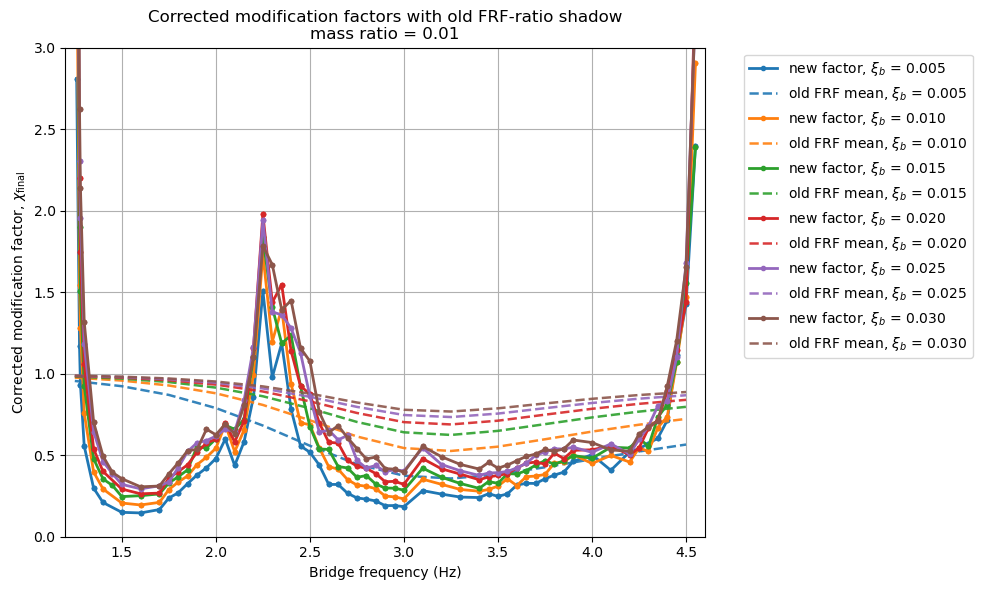

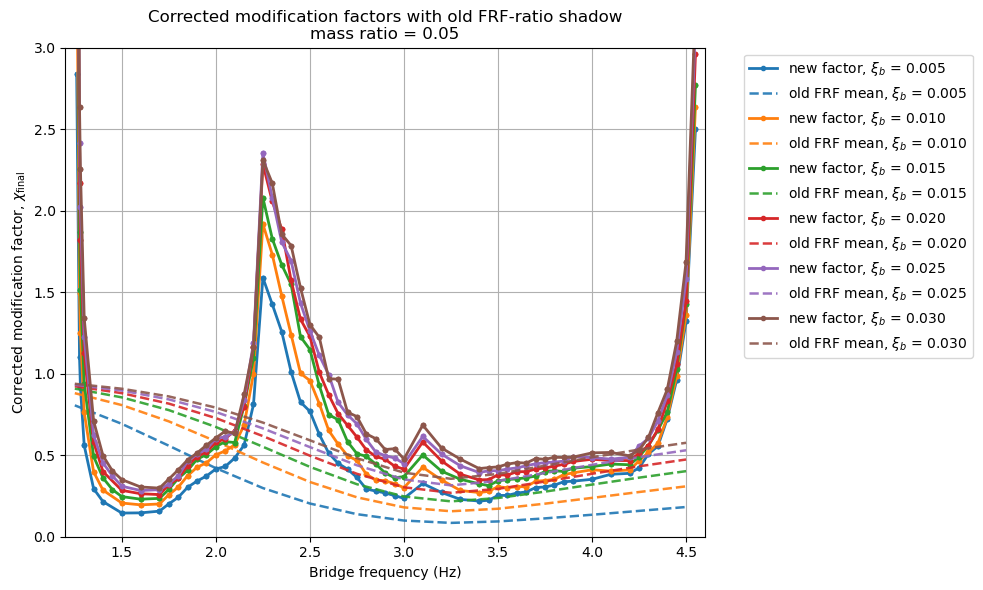

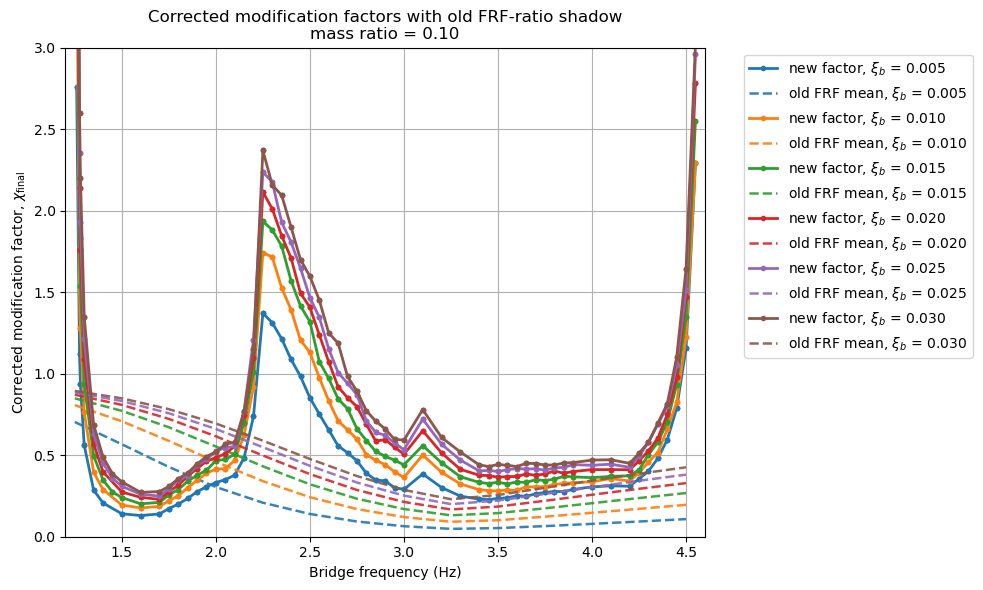

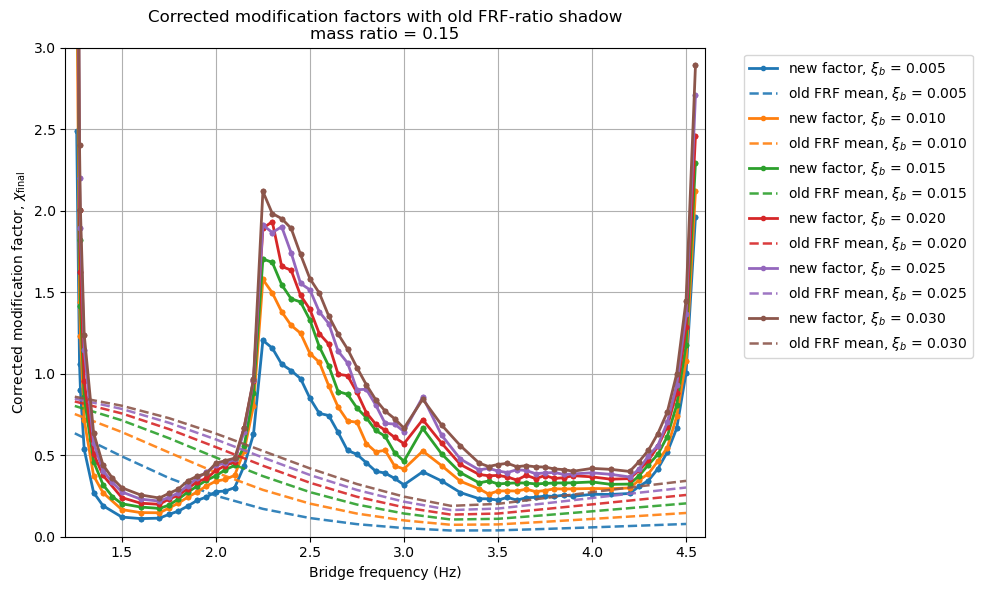

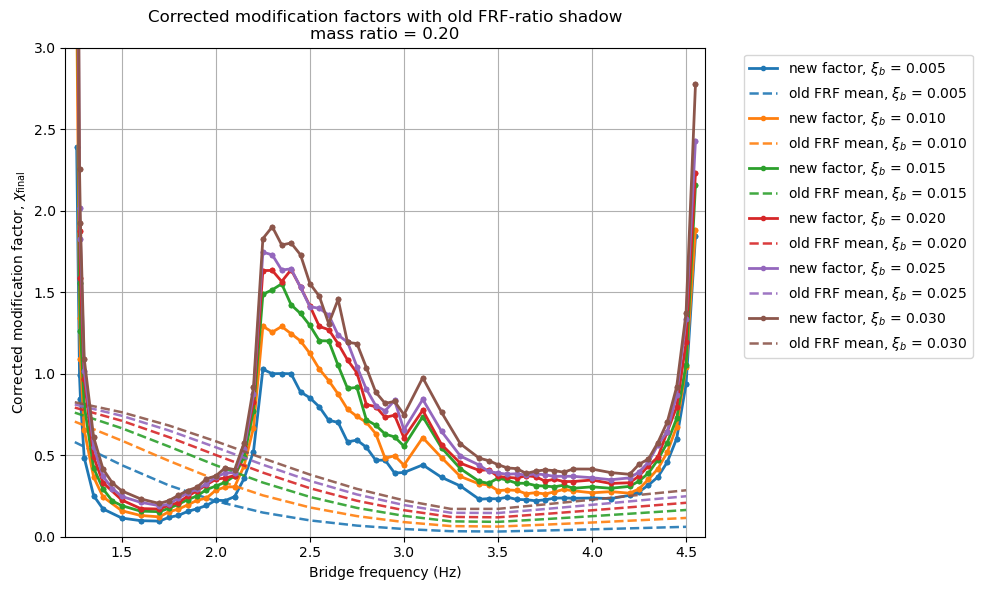

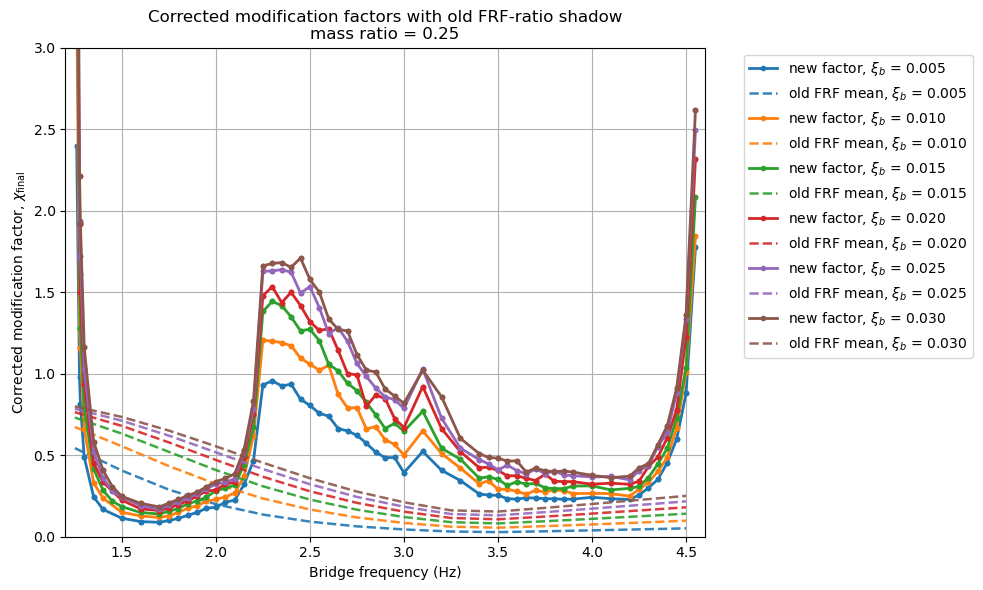

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loading: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading: density0.0333_damping0.005_0S_bias_summary.pkl
Loading: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading: density0.0333_damping0.010_0S_bias_summary.pkl
Loading: density0.0333_damping0.015_0S_bias_summary.pkl
Loading: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading: density0.0333_damping0.020_0S_bias_summary.pkl
Loading: density0.0333_damping0.025_0S_bias_summary.pkl
Loading: density0.0333_damping0.030_0S_bias_summary.pkl
Loading: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading: density0.1667_damping0.005_0S456_bias_summary.pkl
Loading: density0.1667_damping0.005_0S_bias_summary.pkl
Loading: density0.1667_damping0.010_0S125_bias_summary.pkl
Loading: density0.1667_damping0.010_0S456_bias_summary.pkl
Loading: density0.

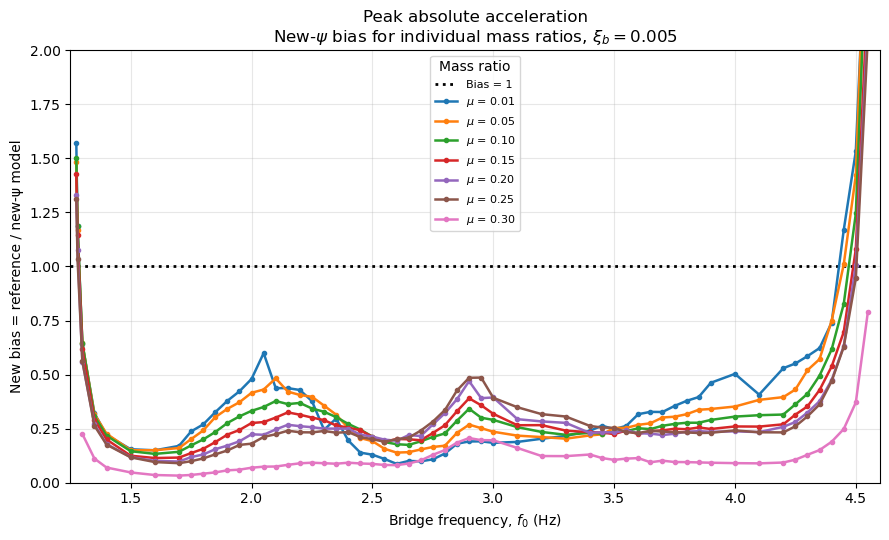

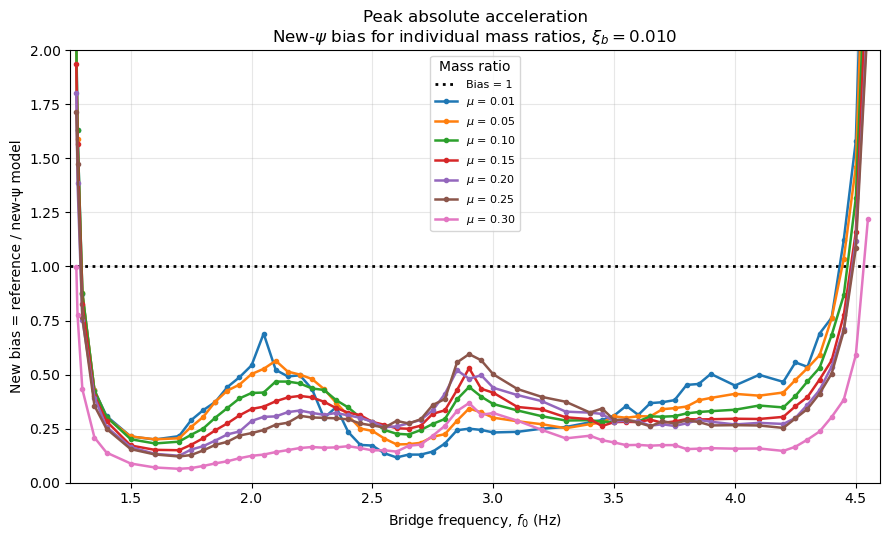

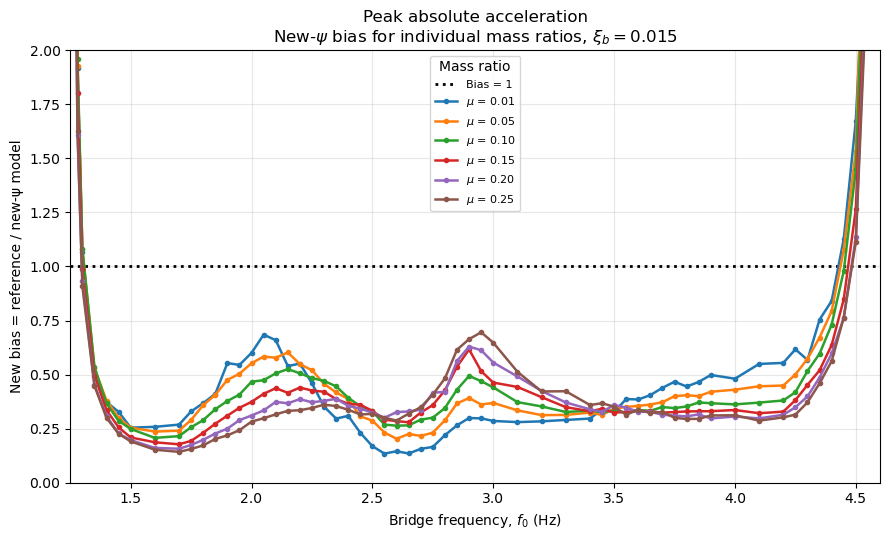

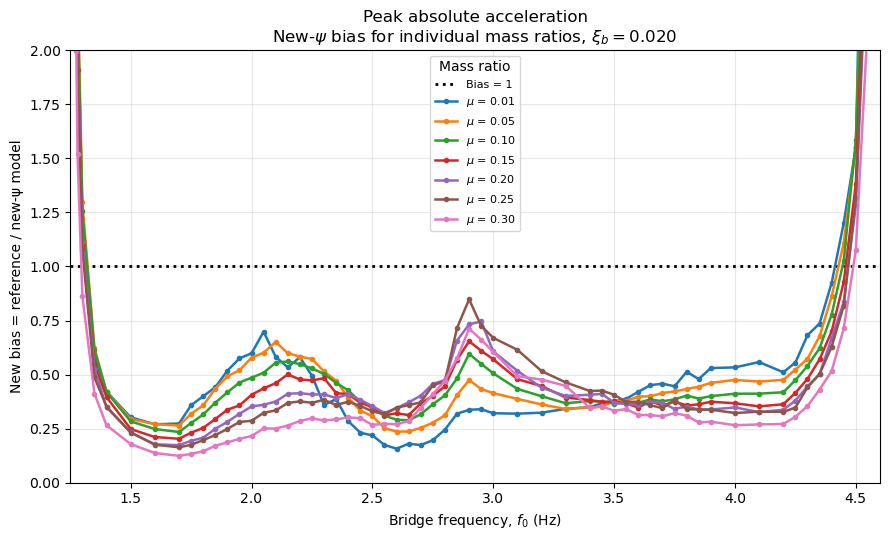

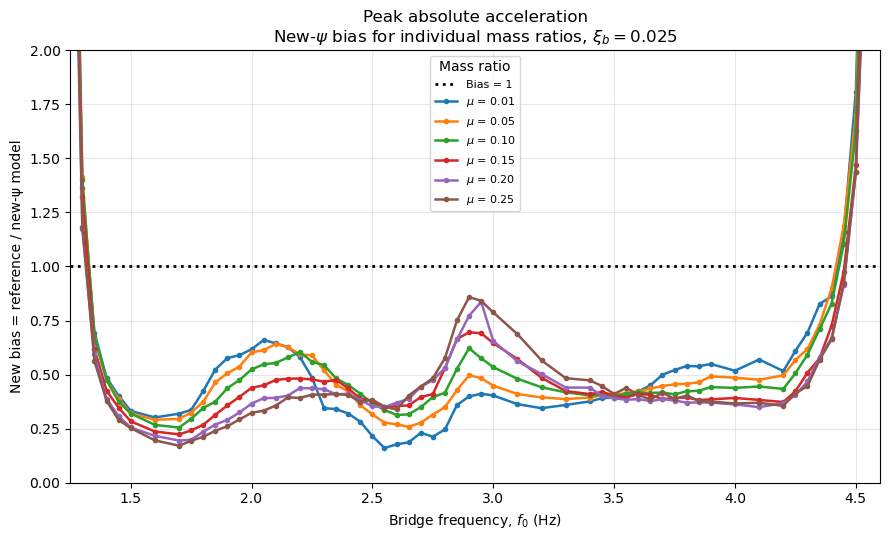

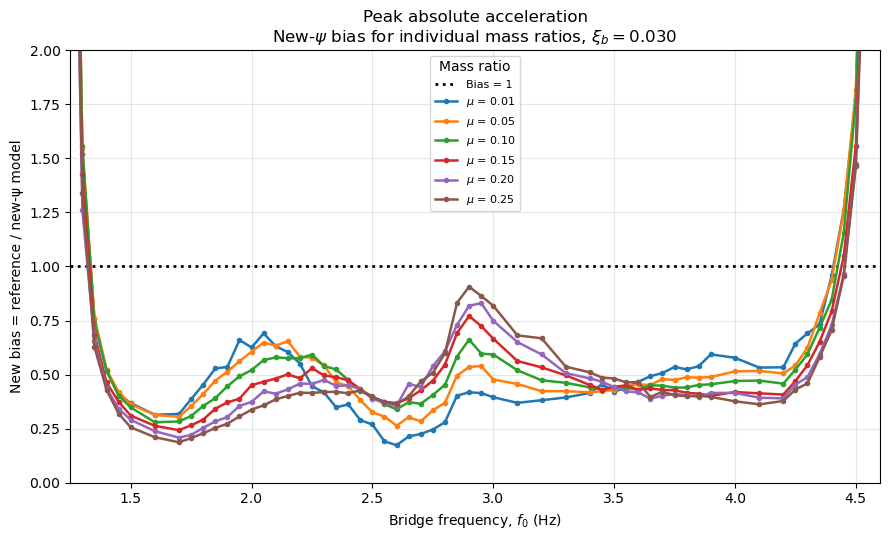

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

PLOT_FMIN = 1.25
PLOT_FMAX = 4.6

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SHOW_ORIGINAL_CODE_CURVES = True
SHOW_NEWPSI_CURVES = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    """
    Upper envelope of shifted psi.
    Piecewise equation from the shifted coupled-psi envelope.
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.258 <= f0 <= 1.709
    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    # 1.709 <= f0 <= 1.711
    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    # 1.711 <= f0 <= 2.566
    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    # 2.566 <= f0 <= 2.568
    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    # 2.568 <= f0 <= 2.872
    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    # 2.872 <= f0 <= 2.874
    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    # 2.874 <= f0 <= 4.191
    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    # 4.191 <= f0 <= 4.193
    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    # 4.193 <= f0 <= 4.593
    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    psi = np.clip(psi, 0.0, 1.0)

    return psi

# ==================================================
# LOAD ALL 0S, 0S125, 0S456 SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]

missing_columns = [c for c in required_columns if c not in corrected_df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.dropna(subset=required_columns).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

# ==================================================
# KEEP FREQUENCY REGIONS BASED ON FILE CONTENT
# ==================================================

# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# Older damping cases may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# Newer damping cases, e.g. 0.015, 0.025, 0.030,
# may have full frequency range stored as 0S.
#
# So:
#   - if only 0S exists for a density/damping pair, keep all 0S rows
#   - if regional files exist, stitch 0S125, 0S, and 0S456

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists, keep full frequency range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: regional files exist, stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    if g_keep.empty:
        print(
            f"Warning: no stitched rows for damping={damp_key}, "
            f"density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)

# Remove duplicate rows if same frequency appears multiple times
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "measure", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "measure", "bridge_frequency"],
    keep="first"
).copy()

# ==================================================
# FILTER TARGET DAMPINGS AND FREQUENCY RANGE
# ==================================================

df = corrected_df.copy()

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS and frequency range."
    )

# ==================================================
# CALCULATE OLD psi, NEW psi, AND NEW-psi BIAS
# ==================================================
# code_bias = reference / old_code_model
#
# old_code_model uses psi_old
# new_code_model uses psi_env
#
# new_code_model = old_code_model * psi_env / psi_old
#
# therefore:
#
# newpsi_bias = code_bias * psi_old / psi_env
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan
plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

for stat in ["mean", "p5", "p95"]:

    old_col = f"code_bias_{stat}"
    new_col = f"newpsi_bias_{stat}"
    hsi_col = f"hsi_factor_{stat}"

    plot_all_df[new_col] = (
        plot_all_df[old_col]
        * plot_all_df["psi_ratio_old_to_env"]
    )

    plot_all_df[new_col] = (
        plot_all_df[new_col]
        .replace([np.inf, -np.inf], np.nan)
    )

    # HSI factor needed after using the new psi model
    plot_all_df[hsi_col] = plot_all_df[new_col]

# ==================================================
# ADD MASS RATIO COLUMN
# ==================================================

plot_all_df["mass_ratio"] = plot_all_df["density_key"].map(
    lambda d: density_to_mass_ratio.get(round(float(d), 4), np.nan)
)

# ==================================================
# PRINT CHECK
# ==================================================

print("\nAvailable data after filtering:")
print(
    plot_all_df
    .groupby(["damping_key", "density_key", "measure"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

# ==================================================
# PLOT FUNCTION: ONE FIGURE PER DAMPING RATIO
# ONLY NEW-psi BIAS
# ==================================================

def plot_newpsi_bias_one_damping(measure_name, damp):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    sub_damp = measure_df[
        np.isclose(measure_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        print(f"No data for measure={measure_name}, damping={damp:.3f}")
        return

    plt.figure(figsize=(9, 5.5))

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label="Bias = 1",
    )

    # --------------------------------------------------
    # Plot only new-psi bias for each mass ratio
    # --------------------------------------------------

    for density in sorted(sub_damp["density_key"].dropna().unique()):

        sub = sub_damp[
            np.isclose(sub_damp["density_key"], density)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = rf"$\mu$ = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        plt.plot(
            sub["bridge_frequency"],
            sub["newpsi_bias_mean"],
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=label,
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel("New bias = reference / new-ψ model")

    plt.title(
        f"{measure_name}\n"
        rf"New-$\psi$ bias for individual mass ratios, $\xi_b = {damp:.3f}$"
    )

    plt.xlim(1.25, 4.6)
    plt.yscale("linear")
    plt.ylim(0, 2)

    plt.grid(True, which="both", alpha=0.30)

    plt.legend(
        loc="best",
        fontsize=8,
        title="Mass ratio",
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"newpsi_bias_{safe_measure}_"
            f"damping{damp:.3f}.png"
        )

        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()
# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    for damp in TARGET_DAMPINGS:
        plot_newpsi_bias_one_damping(measure_name, damp)


ORIGINAL vs ROUNDED CORRECTION

C_original range: 0.4157 to 0.8537
C_rounded range: 0.4250 to 0.8700

Maximum absolute difference in C: 0.019450
Maximum relative difference in C: 3.274%
Maximum absolute difference in resulting bias: 0.167258


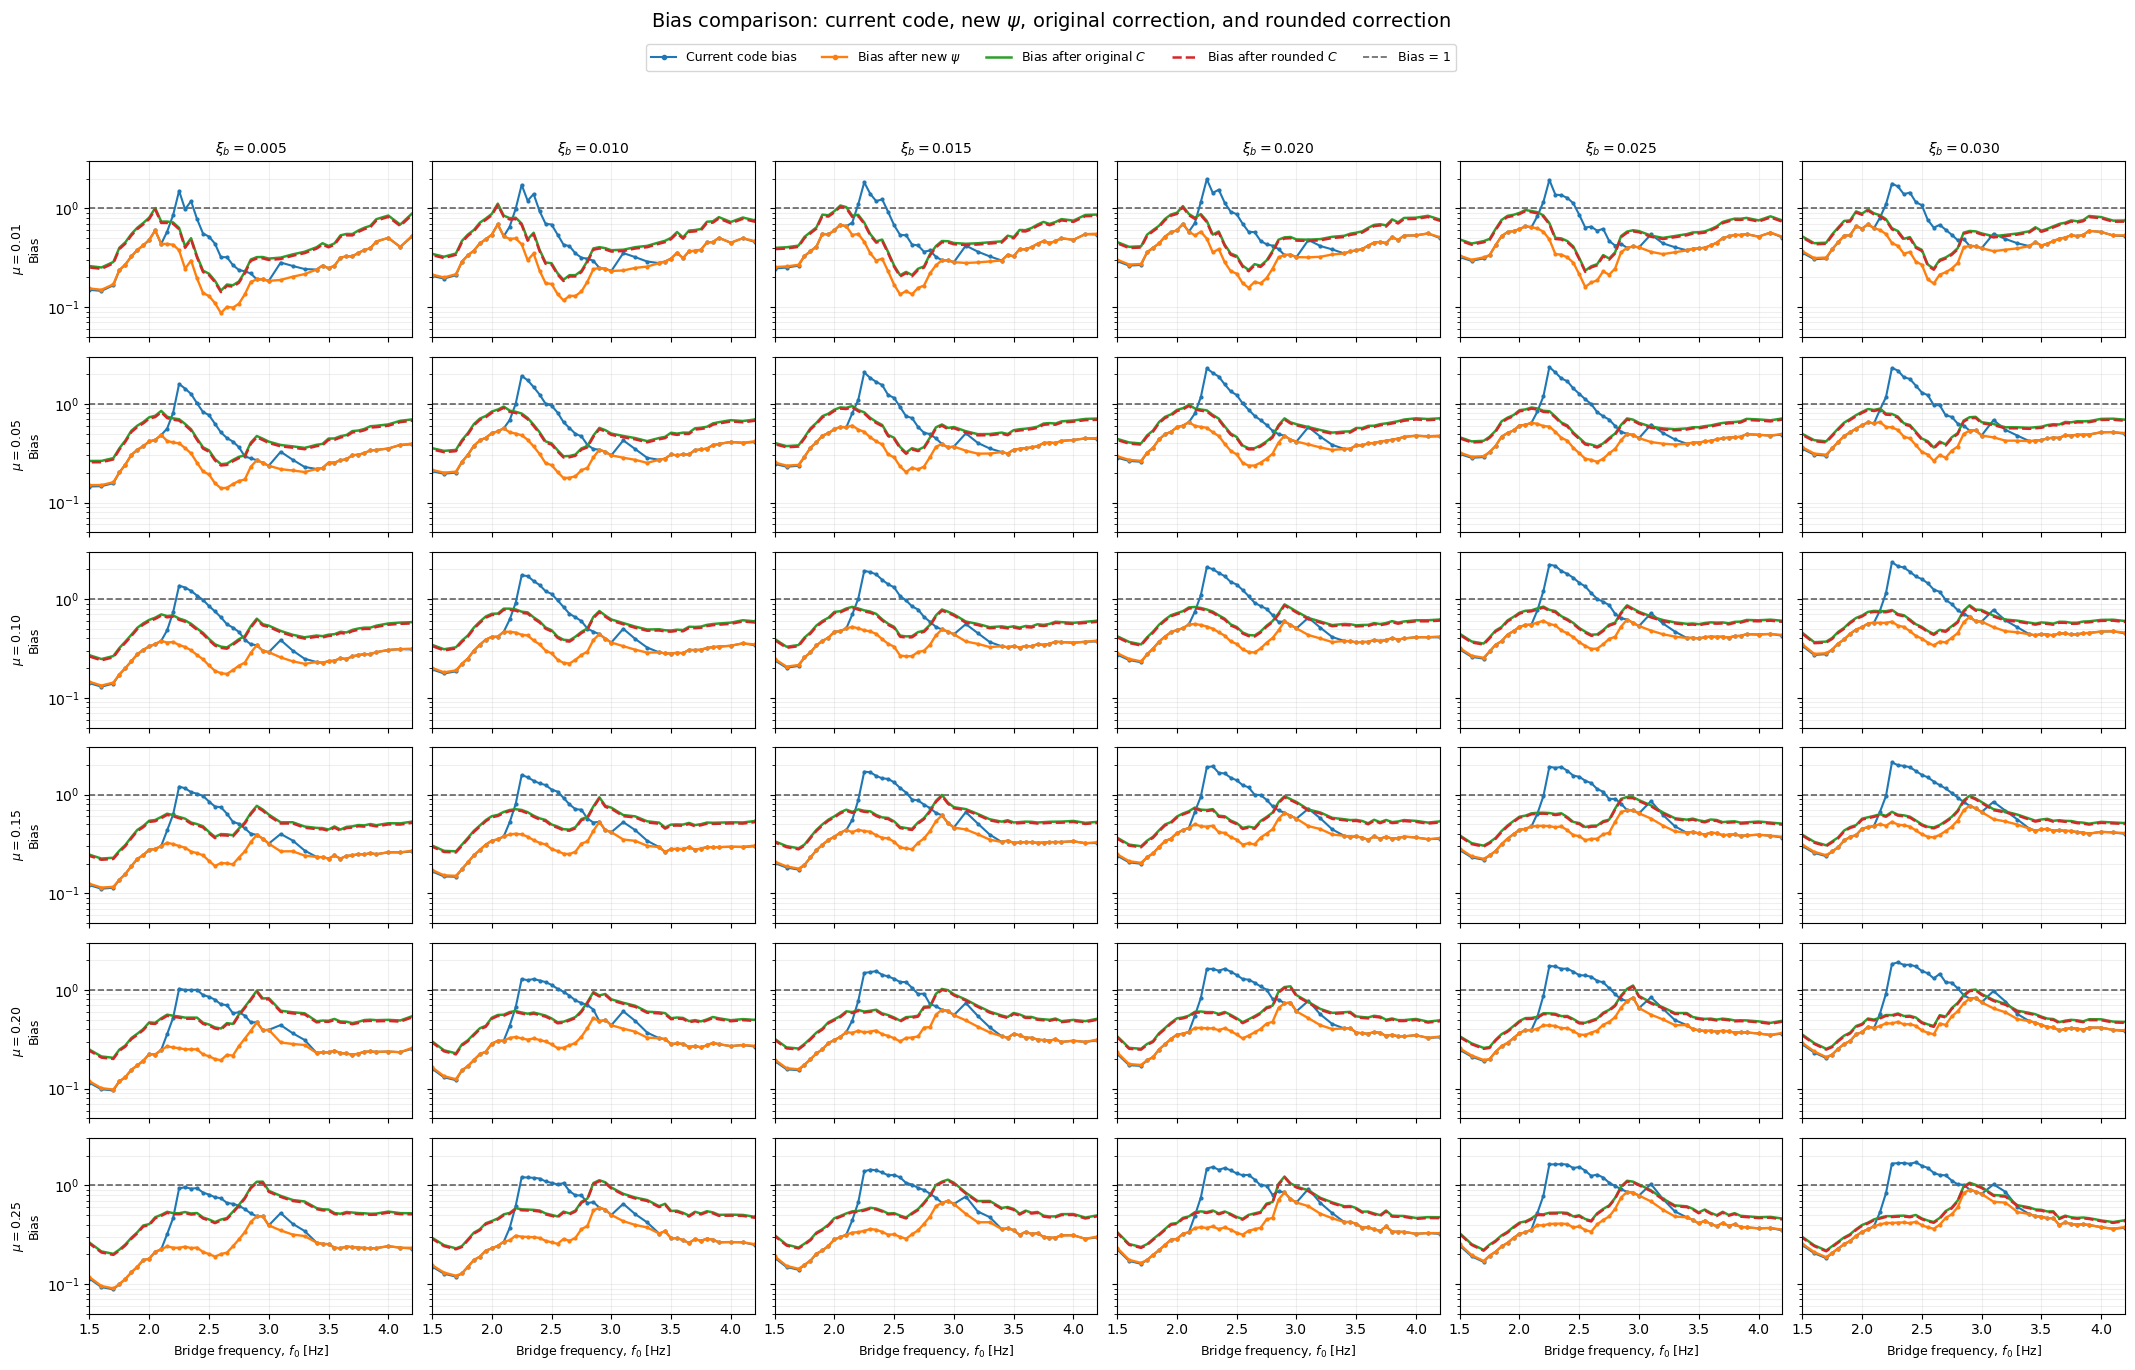

In [3]:
# ============================================================
# COMPARE:
#
# 1. ORIGINAL CODE BIAS
# 2. BIAS AFTER NEW psi
# 3. BIAS AFTER ORIGINAL C EQUATION
# 4. BIAS AFTER ROUNDED C EQUATION
#
# C_original =
#     0.58 + 4.04 xi_b - 0.86 mu + 49 mu xi_b
#
# C_rounded =
#     0.60 + 4.00 xi_b - 0.90 mu + 50 mu xi_b
#
# Since C multiplies the load-model prediction:
#
#     B_final = B_psi / C
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# 1. COPY CURRENT DATA
# ============================================================

comparison_df = plot_all_df.copy()


# ============================================================
# 2. CALCULATE ORIGINAL AND ROUNDED C
# ============================================================

mu = comparison_df["mass_ratio"].to_numpy(dtype=float)

xi = comparison_df["target_beamdamp"].to_numpy(dtype=float)


comparison_df["C_original"] = (
    0.58
    + 4.04 * xi
    - 0.86 * mu
    + 49.0 * mu * xi
)


comparison_df["C_rounded"] = (
    0.60
    + 4.00 * xi
    - 0.90 * mu
    + 50.0 * mu * xi
)


# ============================================================
# 3. APPLY C TO THE BIAS
#
# IMPORTANT:
#
# B_final = B_after_psi / C
# ============================================================

comparison_df["bias_original_C"] = np.where(
    comparison_df["C_original"] > 0,
    comparison_df["newpsi_bias_mean"]
    / comparison_df["C_original"],
    np.nan
)


comparison_df["bias_rounded_C"] = np.where(
    comparison_df["C_rounded"] > 0,
    comparison_df["newpsi_bias_mean"]
    / comparison_df["C_rounded"],
    np.nan
)


# ============================================================
# 4. SMALL NUMERICAL CHECK:
# DIFFERENCE BETWEEN ORIGINAL AND ROUNDED C
# ============================================================

comparison_df["C_difference"] = (
    comparison_df["C_rounded"]
    - comparison_df["C_original"]
)


comparison_df["C_relative_difference_pct"] = (
    100.0
    * comparison_df["C_difference"]
    / comparison_df["C_original"]
)


comparison_df["bias_difference"] = (
    comparison_df["bias_rounded_C"]
    - comparison_df["bias_original_C"]
)


print(
    "\n============================================================"
)

print(
    "ORIGINAL vs ROUNDED CORRECTION"
)

print(
    "============================================================"
)


print(
    "\nC_original range:"
    f" {comparison_df['C_original'].min():.4f}"
    f" to {comparison_df['C_original'].max():.4f}"
)


print(
    "C_rounded range:"
    f" {comparison_df['C_rounded'].min():.4f}"
    f" to {comparison_df['C_rounded'].max():.4f}"
)


print(
    "\nMaximum absolute difference in C:"
    f" {comparison_df['C_difference'].abs().max():.6f}"
)


print(
    "Maximum relative difference in C:"
    f" {comparison_df['C_relative_difference_pct'].abs().max():.3f}%"
)


print(
    "Maximum absolute difference in resulting bias:"
    f" {comparison_df['bias_difference'].abs().max():.6f}"
)


# ============================================================
# 5. SELECT PEAK ABSOLUTE ACCELERATION
# ============================================================

plot_df = comparison_df[
    comparison_df["measure"].astype(str).str.strip()
    ==
    "Peak absolute acceleration"
].copy()


# ============================================================
# 6. MASS RATIOS + DAMPING RATIOS TO PLOT
#
# This reproduces the style of your screenshot.
#
# If you want mu = 0.30 too, simply add 0.30.
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
]

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

# ============================================================
# PLOT COLOURS
# ============================================================

COLOR_CODE = "C0"
COLOR_NEW_PSI = "C1"
COLOR_ORIGINAL_C = "C2"
COLOR_ROUNDED_C = "C3"

# ============================================================
# 7. COMMON FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)


fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 8. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                damping
            )
        ].copy()

        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ----------------------------------------------------
        # Bias = 1
        # ----------------------------------------------------

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        if not sub.empty:

            # ------------------------------------------------
            # ORIGINAL CODE
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                linewidth=1.5,
                marker="o",
                markersize=2.0,
                color=COLOR_CODE,
                label="Current code"
            )


            # ------------------------------------------------
            # NEW psi ONLY
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_bias_mean"],
                linewidth=1.7,
                marker="o",
                markersize=2.0,
                color=COLOR_NEW_PSI,
                label=r"New $\psi$"
            )


            # ------------------------------------------------
            # NEW psi + ORIGINAL C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_original_C"],
                linewidth=1.8,
                color=COLOR_ORIGINAL_C,
                label=r"New $\psi$ + original $C$"
            )


            # ------------------------------------------------
            # NEW psi + ROUNDED C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_rounded_C"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ROUNDED_C,
                label=r"New $\psi$ + rounded $C$"
            )

        # ----------------------------------------------------
        # COLUMN TITLE = DAMPING
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
            rf"$\xi_b={damping:.3f}$",
                            fontsize=10
            )


        # ----------------------------------------------------
        # ROW LABEL = MASS RATIO
        # ----------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$"
                "\nBias",
                fontsize=9
            )


        # ----------------------------------------------------
        # X LABEL
        # ----------------------------------------------------

        if row == nrows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ [Hz]",
                fontsize=9
            )


        # ----------------------------------------------------
        # FORMAT
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_yscale(
            "log"
        )

        ax.set_ylim(
            0.05,
            3.0
        )

        ax.grid(
            True,
            which="both",
            alpha=0.20
        )


# ============================================================
# 9. COMMON TITLE
# ============================================================

fig.suptitle(
    "Bias comparison: current code, new $\\psi$, "
    "original correction, and rounded correction",
    fontsize=14,
    y=0.995
)


# ============================================================
# 10. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.5,
        marker="o",
        markersize=3,
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.7,
        marker="o",
        markersize=3,
        label=r"Bias after new $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ORIGINAL_C,
        linewidth=1.8,
        label=r"Bias after original $C$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ROUNDED_C,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after rounded $C$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=5,
    fontsize=9,
    frameon=True
)
plt.tight_layout(
    rect=[
        0.02,
        0.02,
        0.995,
        0.94
    ]
)

plt.show()

MASS-RATIO BAYESIAN OUTPUT
material  mu_center  mu_lower  mu_upper  N_population_material  n_known_mass_ratio  observed_count_in_bin  p_material_mean  p_mu_bin_mean  p_mu_domain_mean
   Steel       0.01     0.000     0.030                    152                   7                      0         0.597656       0.111111          0.777778
   Steel       0.05     0.030     0.075                    152                   7                      1         0.597656       0.111111          0.777778
   Steel       0.10     0.075     0.125                    152                   7                      1         0.597656       0.111111          0.777778
   Steel       0.15     0.125     0.175                    152                   7                      1         0.597656       0.111111          0.777778
   Steel       0.20     0.175     0.225                    152                   7                      2         0.597656       0.222222          0.777778
   Steel       0.25     0.225     0.2

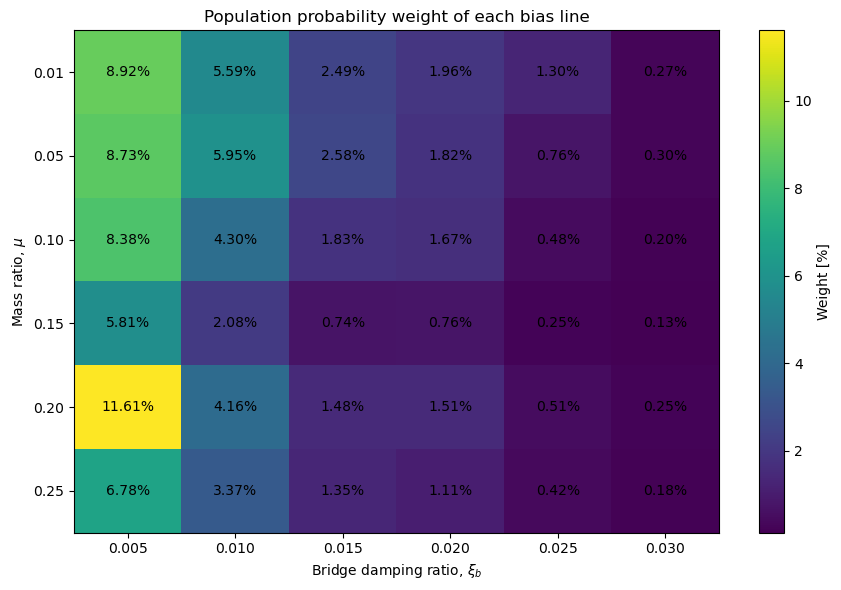

In [4]:
# ============================================================
# POPULATION WEIGHTS FOR EACH (mu, xi_b) BIAS LINE
# ============================================================
#
# INPUT FILES:
#
#   1. mass_ratio_weight_inputs.csv
#   2. damping_weight_inputs.csv
#
# These files come from the two Bayesian models.
#
# MASS-RATIO CSV provides:
#
#   P(material = m)
#   P(mu in basket j | material = m)
#
# DAMPING CSV provides:
#
#   P(xi_b in basket k | material = m)
#
#
# ASSUMPTION:
#
#   mu independent of xi_b conditional on material
#
#   P(mu_j, xi_k | m)
#   =
#   P(mu_j | m) P(xi_k | m)
#
#
# RAW WEIGHT:
#
#   w*_jk
#   =
#   sum_m [
#       P(m)
#       P(mu_j | m)
#       P(xi_k | m)
#   ]
#
#
# FINAL NORMALISED WEIGHT:
#
#   w_jk
#   =
#   w*_jk / sum_jk(w*_jk)
#
#
# Therefore:
#
#   sum_jk w_jk = 1
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. FILE PATHS
# ============================================================

MASS_RATIO_FILE = "mass_ratio_weight_inputs.csv"
DAMPING_FILE = "damping_weight_inputs.csv"


# ============================================================
# 2. LOAD THE TWO BAYESIAN OUTPUT FILES
# ============================================================

mu_df = pd.read_csv(
    MASS_RATIO_FILE,
    encoding="utf-8-sig"
)

xi_df = pd.read_csv(
    DAMPING_FILE,
    encoding="utf-8-sig"
)


print("==========================================")
print("MASS-RATIO BAYESIAN OUTPUT")
print("==========================================")

print(mu_df.head(12).to_string(index=False))


print("\n==========================================")
print("DAMPING BAYESIAN OUTPUT")
print("==========================================")

print(xi_df.head(12).to_string(index=False))


# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

required_mu_columns = [
    "material",
    "mu_center",
    "mu_lower",
    "mu_upper",
    "p_material_mean",
    "p_mu_bin_mean",
]

required_xi_columns = [
    "material",
    "xi_center",
    "xi_lower",
    "xi_upper",
    "p_xi_mean",
]


missing_mu = [
    c for c in required_mu_columns
    if c not in mu_df.columns
]

missing_xi = [
    c for c in required_xi_columns
    if c not in xi_df.columns
]


if missing_mu:

    raise KeyError(
        "Missing columns in mass-ratio CSV: "
        f"{missing_mu}"
    )


if missing_xi:

    raise KeyError(
        "Missing columns in damping CSV: "
        f"{missing_xi}"
    )


# ============================================================
# 4. MATERIAL GROUPS
# ============================================================

MATERIALS = [
    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]


print("\n==========================================")
print("MATERIAL CHECK")
print("==========================================")

print(
    "Mass-ratio materials:",
    sorted(mu_df["material"].unique())
)

print(
    "Damping materials:",
    sorted(xi_df["material"].unique())
)


# Make sure every required material exists in both files

missing_mu_materials = [
    m for m in MATERIALS
    if m not in mu_df["material"].unique()
]

missing_xi_materials = [
    m for m in MATERIALS
    if m not in xi_df["material"].unique()
]


if missing_mu_materials:

    raise ValueError(
        "Materials missing from mass-ratio CSV: "
        f"{missing_mu_materials}"
    )


if missing_xi_materials:

    raise ValueError(
        "Materials missing from damping CSV: "
        f"{missing_xi_materials}"
    )


print("\nAll six material groups found in both files.")


# ============================================================
# 5. GET THE ACTUAL mu AND xi INPUT POINTS
# ============================================================

MU_VALUES = np.sort(
    mu_df["mu_center"].unique()
)

XI_VALUES = np.sort(
    xi_df["xi_center"].unique()
)


print("\n==========================================")
print("BIAS GRID")
print("==========================================")

print("mu values:")
print(MU_VALUES)

print("\nxi_b values:")
print(XI_VALUES)

print(
    f"\nNumber of bias lines = "
    f"{len(MU_VALUES)} x {len(XI_VALUES)} "
    f"= {len(MU_VALUES) * len(XI_VALUES)}"
)


# ============================================================
# 6. CHECK P(material)
#
# p_material_mean is repeated for each mu basket.
# Extract one value per material.
# ============================================================

material_probability = (
    mu_df[
        [
            "material",
            "p_material_mean"
        ]
    ]
    .drop_duplicates()
    .set_index("material")
    ["p_material_mean"]
)


print("\n==========================================")
print("POSTERIOR MEAN MATERIAL PROBABILITIES")
print("==========================================")

print(material_probability)


print(
    "\nSum P(material) =",
    material_probability.sum()
)


# ============================================================
# 7. CHECK MASS-RATIO BASKET PROBABILITIES
# ============================================================

print("\n==========================================")
print("MASS-RATIO BASKET PROBABILITIES")
print("P(mu basket | material)")
print("==========================================")

mu_probability_matrix = (
    mu_df.pivot(
        index="material",
        columns="mu_center",
        values="p_mu_bin_mean"
    )
    .reindex(MATERIALS)
    .reindex(columns=MU_VALUES)
)


print(
    mu_probability_matrix.round(5)
)


print("\nSum of represented mu probability by material:")

print(
    mu_probability_matrix
    .sum(axis=1)
    .round(5)
)


# ============================================================
# 8. CHECK DAMPING BASKET PROBABILITIES
# ============================================================

print("\n==========================================")
print("DAMPING BASKET PROBABILITIES")
print("P(xi basket | material)")
print("==========================================")

xi_probability_matrix = (
    xi_df.pivot(
        index="material",
        columns="xi_center",
        values="p_xi_mean"
    )
    .reindex(MATERIALS)
    .reindex(columns=XI_VALUES)
)


print(
    xi_probability_matrix.round(5)
)


print("\nSum of represented xi probability by material:")

print(
    xi_probability_matrix
    .sum(axis=1)
    .round(5)
)


# ============================================================
# 9. CALCULATE RAW WEIGHTS
# ============================================================
#
# For every (mu_j, xi_k):
#
# w*_jk
# =
# sum_m
# [
#     P(m)
#     *
#     P(mu_j | m)
#     *
#     P(xi_k | m)
# ]
#
# ============================================================

weight_rows = []


for mu in MU_VALUES:

    for xi in XI_VALUES:

        material_contributions = []

        row = {
            "mu": mu,
            "xi_b": xi,
        }


        for mat in MATERIALS:

            P_m = (
                material_probability.loc[mat]
            )

            P_mu_given_m = (
                mu_probability_matrix
                .loc[mat, mu]
            )

            P_xi_given_m = (
                xi_probability_matrix
                .loc[mat, xi]
            )


            contribution = (
                P_m
                *
                P_mu_given_m
                *
                P_xi_given_m
            )


            material_contributions.append(
                contribution
            )


            # Save contribution from each material
            row[
                f"contribution_{mat}"
            ] = contribution


        raw_weight = np.sum(
            material_contributions
        )


        row["raw_weight"] = raw_weight

        weight_rows.append(
            row
        )


weights_df = pd.DataFrame(
    weight_rows
)


# ============================================================
# 10. RAW WEIGHT SUM
# ============================================================

raw_weight_sum = (
    weights_df["raw_weight"].sum()
)


print("\n==========================================")
print("RAW WEIGHT SUM")
print("==========================================")

print(
    f"Sum raw weights = "
    f"{raw_weight_sum:.8f}"
)


print(
    "\nThis does NOT necessarily equal 1 because "
    "our bias grid only represents a restricted "
    "mu-xi domain."
)


# ============================================================
# 11. NORMALISE WEIGHTS
#
# Supervisor requirement:
#
# sum W = 1
# ============================================================

if raw_weight_sum <= 0:

    raise ValueError(
        "Raw weights sum to zero."
    )


weights_df["weight"] = (
    weights_df["raw_weight"]
    /
    raw_weight_sum
)


weights_df["weight_percent"] = (
    100
    *
    weights_df["weight"]
)


# ============================================================
# 12. FINAL CHECK
# ============================================================

print("\n==========================================")
print("NORMALISED WEIGHT CHECK")
print("==========================================")

print(
    f"Sum W = "
    f"{weights_df['weight'].sum():.12f}"
)


# ============================================================
# 13. DISPLAY THE 36 FINAL WEIGHTS
# ============================================================

print("\n==========================================")
print("FINAL 36 BIAS-LINE WEIGHTS")
print("==========================================")

print(
    weights_df[
        [
            "mu",
            "xi_b",
            "raw_weight",
            "weight",
            "weight_percent",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 14. MAKE 6 x 6 WEIGHT MATRIX
#
# rows    = mu
# columns = xi_b
# ============================================================

W_matrix = (
    weights_df.pivot(
        index="mu",
        columns="xi_b",
        values="weight"
    )
    .reindex(
        index=MU_VALUES,
        columns=XI_VALUES
    )
)


W_percent_matrix = (
    100
    *
    W_matrix
)


print("\n==========================================")
print("WEIGHT MATRIX")
print("rows = mu")
print("columns = xi_b")
print("==========================================")

print(
    W_matrix.round(6)
)


print("\n==========================================")
print("WEIGHT MATRIX [%]")
print("==========================================")

print(
    W_percent_matrix.round(2)
)


# ============================================================
# 15. MARGINAL WEIGHTS
#
# Useful diagnostic:
#
# sum across xi -> importance of each mu
#
# sum across mu -> importance of each xi
# ============================================================

mu_marginal = (
    W_matrix.sum(axis=1)
)

xi_marginal = (
    W_matrix.sum(axis=0)
)


print("\n==========================================")
print("MARGINAL WEIGHT BY MASS RATIO")
print("==========================================")

for mu, w in mu_marginal.items():

    print(
        f"mu = {mu:.3f} : "
        f"{w:.6f} "
        f"({100*w:.2f}%)"
    )


print("\n==========================================")
print("MARGINAL WEIGHT BY DAMPING")
print("==========================================")

for xi, w in xi_marginal.items():

    print(
        f"xi = {xi:.3f} : "
        f"{w:.6f} "
        f"({100*w:.2f}%)"
    )


# ============================================================
# 16. SHOW MATERIAL CONTRIBUTIONS TO EACH LINE
# ============================================================

contribution_columns = [
    f"contribution_{mat}"
    for mat in MATERIALS
]


# Convert raw material contributions into
# contribution to FINAL normalised population weight

for col in contribution_columns:

    weights_df[
        col + "_normalised"
    ] = (
        weights_df[col]
        /
        raw_weight_sum
    )


# ============================================================
# 17. SAVE FINAL OUTPUT
# ============================================================

weights_df.to_csv(
    "bias_line_weights.csv",
    index=False,
    encoding="utf-8-sig"
)


W_matrix.to_csv(
    "bias_line_weight_matrix.csv",
    encoding="utf-8-sig"
)


W_percent_matrix.to_csv(
    "bias_line_weight_matrix_percent.csv",
    encoding="utf-8-sig"
)


print("\n==========================================")
print("FILES SAVED")
print("==========================================")

print(
    "bias_line_weights.csv"
)

print(
    "bias_line_weight_matrix.csv"
)

print(
    "bias_line_weight_matrix_percent.csv"
)


# ============================================================
# 18. PLOT WEIGHT MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


im = ax.imshow(
    W_percent_matrix.to_numpy(),
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(XI_VALUES)
    )
)

ax.set_xticklabels(
    [
        f"{x:.3f}"
        for x in XI_VALUES
    ]
)


ax.set_yticks(
    np.arange(
        len(MU_VALUES)
    )
)

ax.set_yticklabels(
    [
        f"{x:.2f}"
        for x in MU_VALUES
    ]
)


ax.set_xlabel(
    r"Bridge damping ratio, $\xi_b$"
)

ax.set_ylabel(
    r"Mass ratio, $\mu$"
)

ax.set_title(
    "Population probability weight of each bias line"
)


# Put percentages inside cells

for i in range(
    len(MU_VALUES)
):

    for j in range(
        len(XI_VALUES)
    ):

        value = (
            W_percent_matrix
            .iloc[i, j]
        )

        ax.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center"
        )


fig.colorbar(
    im,
    ax=ax,
    label="Weight [%]"
)


plt.tight_layout()
plt.show()

LOADED WEIGHTS
  mu  xi_b   weight  weight_percent
0.01 0.005 0.089189        8.918878
0.01 0.010 0.055889        5.588902
0.01 0.015 0.024922        2.492220
0.01 0.020 0.019567        1.956700
0.01 0.025 0.012960        1.296016
0.01 0.030 0.002657        0.265692
0.05 0.005 0.087295        8.729546
0.05 0.010 0.059508        5.950803
0.05 0.015 0.025780        2.577997
0.05 0.020 0.018153        1.815272
0.05 0.025 0.007550        0.755050
0.05 0.030 0.003005        0.300515
0.10 0.005 0.083833        8.383311
0.10 0.010 0.042961        4.296078
0.10 0.015 0.018284        1.828384
0.10 0.020 0.016685        1.668454
0.10 0.025 0.004755        0.475521
0.10 0.030 0.002020        0.201998
0.15 0.005 0.058051        5.805110
0.15 0.010 0.020782        2.078152
0.15 0.015 0.007420        0.741965
0.15 0.020 0.007573        0.757310
0.15 0.025 0.002526        0.252634
0.15 0.030 0.001254        0.125448
0.20 0.005 0.116102       11.610219
0.20 0.010 0.041563        4.156304
0.20 0.015 0.

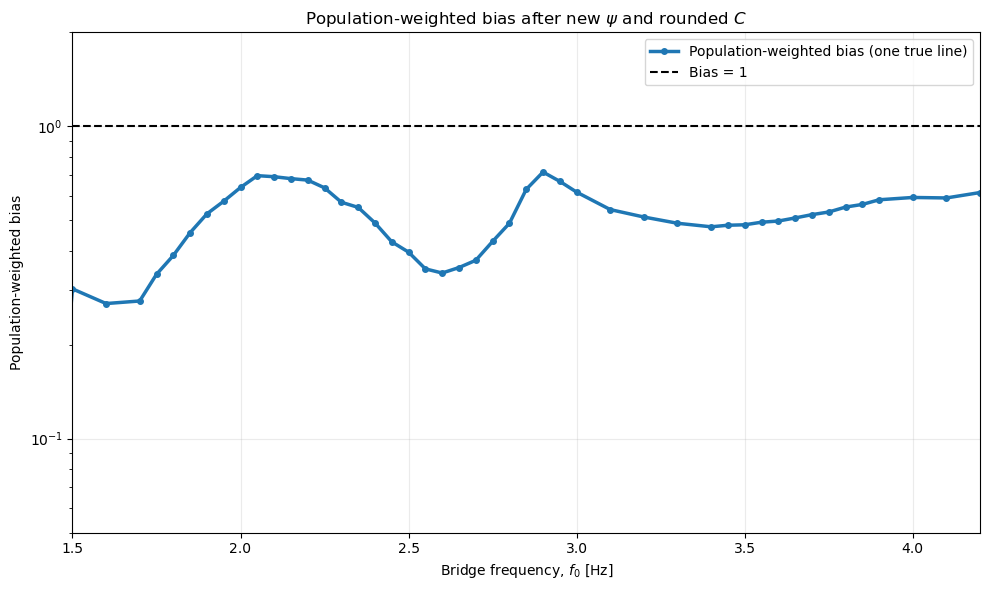


Saved: one_true_population_weighted_bias.csv


In [6]:
# ============================================================
# ONE TRUE POPULATION-WEIGHTED BIAS LINE
#
# Uses:
#   comparison_df / plot_df        <- from bias comparison code
#   bias_line_weights.csv          <- from population weighting
#
# Weighted quantity:
#   bias_rounded_C
#
# B_true(f) = sum_jk w_jk * B_jk(f)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD THE 36 POPULATION WEIGHTS
# ============================================================

WEIGHT_FILE = "bias_line_weights.csv"

weights = pd.read_csv(
    WEIGHT_FILE,
    encoding="utf-8-sig"
)


print("==========================================")
print("LOADED WEIGHTS")
print("==========================================")

print(
    weights[
        [
            "mu",
            "xi_b",
            "weight",
            "weight_percent"
        ]
    ].to_string(index=False)
)


# ============================================================
# 2. CHECK WEIGHT SUM
# ============================================================

weight_sum = weights["weight"].sum()

print("\n==========================================")
print("WEIGHT CHECK")
print("==========================================")

print(
    f"Number of weights = {len(weights)}"
)

print(
    f"Sum of weights = {weight_sum:.12f}"
)


if not np.isclose(
    weight_sum,
    1.0,
    atol=1e-8
):

    raise ValueError(
        "Weights do not sum to 1."
    )


# ============================================================
# 3. GET PEAK ABSOLUTE ACCELERATION DATA
# ============================================================

weighted_df = comparison_df[
    comparison_df["measure"]
    .astype(str)
    .str.strip()
    ==
    "Peak absolute acceleration"
].copy()


# Keep only the 6 x 6 population-weighted grid

MU_VALUES = np.sort(
    weights["mu"].unique()
)

XI_VALUES = np.sort(
    weights["xi_b"].unique()
)


weighted_df = weighted_df[
    weighted_df["mass_ratio"].isin(MU_VALUES)
    &
    weighted_df["target_beamdamp"].isin(XI_VALUES)
].copy()


# ============================================================
# 4. MERGE EACH BIAS LINE WITH ITS WEIGHT
# ============================================================

weighted_df = weighted_df.merge(

    weights[
        [
            "mu",
            "xi_b",
            "weight"
        ]
    ],

    left_on=[
        "mass_ratio",
        "target_beamdamp"
    ],

    right_on=[
        "mu",
        "xi_b"
    ],

    how="left",

    validate="many_to_one"
)


# ============================================================
# 5. CHECK EVERY LINE GOT A WEIGHT
# ============================================================

if weighted_df["weight"].isna().any():

    missing = (
        weighted_df.loc[
            weighted_df["weight"].isna(),
            [
                "mass_ratio",
                "target_beamdamp"
            ]
        ]
        .drop_duplicates()
    )

    raise ValueError(
        "Some bias lines did not receive a weight:\n"
        + missing.to_string(index=False)
    )


print("\nAll bias rows successfully matched to weights.")


# ============================================================
# 6. CHECK ALL 36 (mu, xi) COMBINATIONS ARE PRESENT
# ============================================================

line_combinations = (
    weighted_df[
        [
            "mass_ratio",
            "target_beamdamp"
        ]
    ]
    .drop_duplicates()
)


print(
    "Number of unique bias lines found =",
    len(line_combinations)
)


if len(line_combinations) != len(weights):

    print(
        "\nWARNING:"
        "\nNumber of bias lines does not equal "
        "number of weights."
    )


# ============================================================
# 7. CALCULATE WEIGHTED CONTRIBUTION OF EACH LINE
#
# At every frequency:
#
# contribution_jk(f)
# =
# w_jk * B_jk(f)
# ============================================================

weighted_df[
    "weighted_bias_contribution"
] = (

    weighted_df["weight"]

    *

    weighted_df["bias_rounded_C"]
)


# ============================================================
# 8. CREATE THE ONE TRUE LINE
#
# B_true(f)
# =
# sum_jk [
#     w_jk * B_jk(f)
# ]
# ============================================================

one_true_line = (

    weighted_df
    .groupby(
        "bridge_frequency",
        as_index=False
    )
    .agg(

        B_true=(
            "weighted_bias_contribution",
            "sum"
        ),

        weight_sum_at_frequency=(
            "weight",
            "sum"
        ),

        n_lines=(
            "weight",
            "size"
        )
    )
    .sort_values(
        "bridge_frequency"
    )
)


# ============================================================
# 9. CHECK WEIGHTS AT EACH FREQUENCY
#
# If all 36 curves exist at every frequency,
# this should be exactly 1.
# ============================================================

print("\n==========================================")
print("WEIGHT SUM AT EACH FREQUENCY")
print("==========================================")

print(
    one_true_line[
        [
            "bridge_frequency",
            "weight_sum_at_frequency",
            "n_lines"
        ]
    ].to_string(index=False)
)


# Strict check

bad_frequency = one_true_line[
    ~np.isclose(
        one_true_line[
            "weight_sum_at_frequency"
        ],
        1.0,
        atol=1e-8
    )
]


if not bad_frequency.empty:

    print(
        "\nWARNING:"
        "\nAt some frequencies the available "
        "bias-line weights do not sum to 1."
        "\nThis usually means one or more of the "
        "36 lines are missing at that frequency."
    )


# ============================================================
# 10. PRINT THE ONE TRUE LINE
# ============================================================

print("\n==========================================")
print("ONE TRUE POPULATION-WEIGHTED BIAS LINE")
print("==========================================")

print(
    one_true_line[
        [
            "bridge_frequency",
            "B_true"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 11. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.plot(

    one_true_line[
        "bridge_frequency"
    ],

    one_true_line[
        "B_true"
    ],

    linewidth=2.5,
    marker="o",
    markersize=4,

    label=(
        "Population-weighted bias "
        "(one true line)"
    )
)


# Bias = 1 reference

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Bias = 1"
)

# Logarithmic y-axis
ax.set_yscale("log")

# Log scale cannot start at zero
ax.set_ylim(0.05, 2.0)
ax.set_xlim(
    1.50,
    4.20
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(
    "Population-weighted bias after "
    r"new $\psi$ and rounded $C$"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend()


plt.tight_layout()
plt.show()


# ============================================================
# 12. SAVE THE ONE TRUE LINE
# ============================================================

one_true_line.to_csv(

    "one_true_population_weighted_bias.csv",

    index=False,

    encoding="utf-8-sig"
)


print(
    "\nSaved: "
    "one_true_population_weighted_bias.csv"
)


FREQUENCY RANGE AFTER FILTERING
1.5 to 4.2

LOADED POPULATION WEIGHTS
  mu  xi_b   weight  weight_percent
0.01 0.005 0.089189        8.918878
0.01 0.010 0.055889        5.588902
0.01 0.015 0.024922        2.492220
0.01 0.020 0.019567        1.956700
0.01 0.025 0.012960        1.296016
0.01 0.030 0.002657        0.265692
0.05 0.005 0.087295        8.729546
0.05 0.010 0.059508        5.950803
0.05 0.015 0.025780        2.577997
0.05 0.020 0.018153        1.815272
0.05 0.025 0.007550        0.755050
0.05 0.030 0.003005        0.300515
0.10 0.005 0.083833        8.383311
0.10 0.010 0.042961        4.296078
0.10 0.015 0.018284        1.828384
0.10 0.020 0.016685        1.668454
0.10 0.025 0.004755        0.475521
0.10 0.030 0.002020        0.201998
0.15 0.005 0.058051        5.805110
0.15 0.010 0.020782        2.078152
0.15 0.015 0.007420        0.741965
0.15 0.020 0.007573        0.757310
0.15 0.025 0.002526        0.252634
0.15 0.030 0.001254        0.125448
0.20 0.005 0.116102       11.

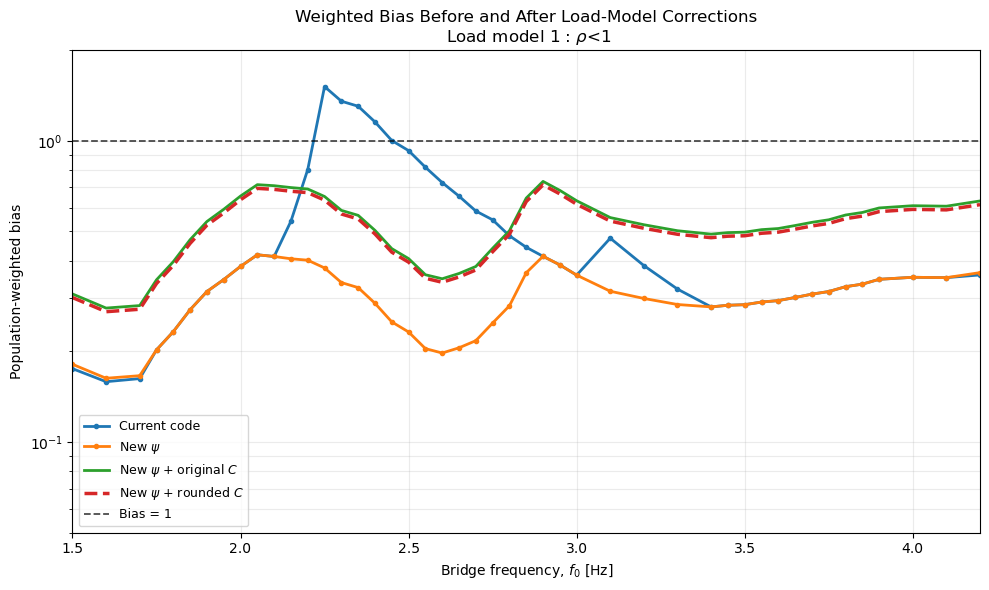


FILES SAVED
population_weighted_bias_comparison.csv
population_weighted_bias_detailed.csv


In [25]:
# ============================================================
# POPULATION-WEIGHTED COMPARISON
#
# Produces ONE weighted line for each formulation:
#
#   1. Current code
#   2. New psi
#   3. New psi + original C
#   4. New psi + rounded C
#
# INPUTS:
#
#   plot_all_df
#
#   bias_line_weights.csv
#
#
# WEIGHTING:
#
#   B_W(f) = sum_jk w_jk B_jk(f)
#
# where:
#
#   sum_jk w_jk = 1
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. FILE CONTAINING THE 36 POPULATION WEIGHTS
# ============================================================

WEIGHT_FILE = "bias_line_weights.csv"


# ============================================================
# 2. COPY ORIGINAL BIAS DATA
# ============================================================

comparison_df = plot_all_df.copy()


# ============================================================
# 3. CALCULATE ORIGINAL AND ROUNDED C
# ============================================================

mu = comparison_df[
    "mass_ratio"
].to_numpy(dtype=float)

xi = comparison_df[
    "target_beamdamp"
].to_numpy(dtype=float)


# ------------------------------------------------------------
# Original fitted correction
# ------------------------------------------------------------

comparison_df["C_original"] = (
    0.58
    + 4.04 * xi
    - 0.86 * mu
    + 49.0 * mu * xi
)


# ------------------------------------------------------------
# Rounded correction
# ------------------------------------------------------------

comparison_df["C_rounded"] = (
    0.60
    + 4.00 * xi
    - 0.90 * mu
    + 50.0 * mu * xi
)


# ============================================================
# 4. APPLY C TO BIAS AFTER NEW psi
#
# Since C multiplies the load-model prediction:
#
#       B_final = B_psi / C
# ============================================================

comparison_df["bias_original_C"] = np.where(

    comparison_df["C_original"] > 0,

    comparison_df["newpsi_bias_mean"]
    /
    comparison_df["C_original"],

    np.nan
)


comparison_df["bias_rounded_C"] = np.where(

    comparison_df["C_rounded"] > 0,

    comparison_df["newpsi_bias_mean"]
    /
    comparison_df["C_rounded"],

    np.nan
)


# ============================================================
# 5. KEEP PEAK ABSOLUTE ACCELERATION
# ============================================================

weighted_df = comparison_df[

    comparison_df["measure"]
    .astype(str)
    .str.strip()

    ==

    "Peak absolute acceleration"

].copy()

# ============================================================
# KEEP ONLY THE INTENDED FREQUENCY RANGE
#
# The bias study / figures use:
#     1.50 <= f <= 4.20 Hz
#
# f = 1.45 Hz contains only part of the 36-line grid,
# so it must not be used in the population-weighted curve.
# ============================================================

F_MIN = 1.50
F_MAX = 4.20

weighted_df = weighted_df[
    (weighted_df["bridge_frequency"] >= F_MIN)
    &
    (weighted_df["bridge_frequency"] <= F_MAX)
].copy()

print("\n==========================================")
print("FREQUENCY RANGE AFTER FILTERING")
print("==========================================")

print(
    weighted_df["bridge_frequency"].min(),
    "to",
    weighted_df["bridge_frequency"].max()
)
# ============================================================
# 6. LOAD THE 36 POPULATION WEIGHTS
# ============================================================

weights = pd.read_csv(
    WEIGHT_FILE,
    encoding="utf-8-sig"
)


print("\n==========================================")
print("LOADED POPULATION WEIGHTS")
print("==========================================")

print(
    weights[
        [
            "mu",
            "xi_b",
            "weight",
            "weight_percent"
        ]
    ].to_string(index=False)
)


# ============================================================
# 7. CHECK WEIGHTS
# ============================================================

weight_sum = weights[
    "weight"
].sum()


print("\n==========================================")
print("WEIGHT CHECK")
print("==========================================")

print(
    f"Number of weights = {len(weights)}"
)

print(
    f"Sum of weights = {weight_sum:.12f}"
)


if len(weights) != 36:

    raise ValueError(
        f"Expected 36 weights, but found {len(weights)}."
    )


if not np.isclose(
    weight_sum,
    1.0,
    atol=1e-8
):

    raise ValueError(
        "Population weights do not sum to 1."
    )


# ============================================================
# 8. GRID REPRESENTED BY THE WEIGHTS
# ============================================================

MU_VALUES = np.sort(
    weights["mu"].unique()
)

XI_VALUES = np.sort(
    weights["xi_b"].unique()
)


print("\n==========================================")
print("BIAS GRID")
print("==========================================")

print(
    "Mass ratios:",
    MU_VALUES
)

print(
    "Damping ratios:",
    XI_VALUES
)


# ============================================================
# 9. KEEP ONLY THE REQUIRED 6 x 6 GRID
#
# Use np.isclose rather than .isin because these are floats.
# ============================================================

mu_mask = np.zeros(
    len(weighted_df),
    dtype=bool
)

for mu_value in MU_VALUES:

    mu_mask |= np.isclose(
        weighted_df["mass_ratio"],
        mu_value
    )


xi_mask = np.zeros(
    len(weighted_df),
    dtype=bool
)

for xi_value in XI_VALUES:

    xi_mask |= np.isclose(
        weighted_df["target_beamdamp"],
        xi_value
    )


weighted_df = weighted_df[
    mu_mask & xi_mask
].copy()


# ============================================================
# 10. ROUND MERGE KEYS TO AVOID FLOAT-MATCHING PROBLEMS
# ============================================================

weighted_df["mu_key"] = (
    weighted_df["mass_ratio"]
    .astype(float)
    .round(6)
)

weighted_df["xi_key"] = (
    weighted_df["target_beamdamp"]
    .astype(float)
    .round(6)
)


weights["mu_key"] = (
    weights["mu"]
    .astype(float)
    .round(6)
)

weights["xi_key"] = (
    weights["xi_b"]
    .astype(float)
    .round(6)
)


# ============================================================
# 11. MERGE EACH BIAS LINE WITH ITS POPULATION WEIGHT
# ============================================================

weighted_df = weighted_df.merge(

    weights[
        [
            "mu_key",
            "xi_key",
            "weight",
            "weight_percent"
        ]
    ],

    on=[
        "mu_key",
        "xi_key"
    ],

    how="left",

    validate="many_to_one"
)


# ============================================================
# 12. CHECK THAT EVERY BIAS LINE RECEIVED A WEIGHT
# ============================================================

if weighted_df[
    "weight"
].isna().any():

    missing = (
        weighted_df.loc[
            weighted_df["weight"].isna(),
            [
                "mass_ratio",
                "target_beamdamp"
            ]
        ]
        .drop_duplicates()
    )

    raise ValueError(
        "Some bias lines could not be matched "
        "to population weights:\n"
        +
        missing.to_string(index=False)
    )


print(
    "\nAll bias data successfully matched "
    "to population weights."
)


# ============================================================
# 13. CHECK THE 36 UNIQUE (mu, xi) LINES
# ============================================================

unique_lines = (
    weighted_df[
        [
            "mass_ratio",
            "target_beamdamp"
        ]
    ]
    .drop_duplicates()
)


print("\n==========================================")
print("BIAS-LINE CHECK")
print("==========================================")

print(
    f"Unique (mu, xi) lines found = "
    f"{len(unique_lines)}"
)


if len(unique_lines) != 36:

    raise ValueError(
        "Expected 36 unique bias lines, "
        f"but found {len(unique_lines)}."
    )


# ============================================================
# 14. CALCULATE WEIGHTED CONTRIBUTION OF EACH FORMULATION
#
# SAME population weight is applied to all four cases.
# ============================================================


# ------------------------------------------------------------
# 1. CURRENT CODE
# ------------------------------------------------------------

weighted_df[
    "weighted_current_code"
] = (

    weighted_df["weight"]

    *

    weighted_df["code_bias_mean"]
)


# ------------------------------------------------------------
# 2. NEW psi
# ------------------------------------------------------------

weighted_df[
    "weighted_new_psi"
] = (

    weighted_df["weight"]

    *

    weighted_df["newpsi_bias_mean"]
)


# ------------------------------------------------------------
# 3. NEW psi + ORIGINAL C
# ------------------------------------------------------------

weighted_df[
    "weighted_original_C"
] = (

    weighted_df["weight"]

    *

    weighted_df["bias_original_C"]
)


# ------------------------------------------------------------
# 4. NEW psi + ROUNDED C
# ------------------------------------------------------------

weighted_df[
    "weighted_rounded_C"
] = (

    weighted_df["weight"]

    *

    weighted_df["bias_rounded_C"]
)


# ============================================================
# 15. SUM THE 36 WEIGHTED LINES AT EACH FREQUENCY
#
# Gives FOUR population-weighted curves:
#
# B_current(f)
# B_new_psi(f)
# B_original_C(f)
# B_rounded_C(f)
# ============================================================

weighted_lines = (

    weighted_df

    .groupby(
        "bridge_frequency",
        as_index=False
    )

    .agg(

        B_current=(
            "weighted_current_code",
            "sum"
        ),

        B_new_psi=(
            "weighted_new_psi",
            "sum"
        ),

        B_original_C=(
            "weighted_original_C",
            "sum"
        ),

        B_rounded_C=(
            "weighted_rounded_C",
            "sum"
        ),

        weight_sum=(
            "weight",
            "sum"
        ),

        n_lines=(
            "weight",
            "size"
        )
    )

    .sort_values(
        "bridge_frequency"
    )
)


# ============================================================
# 16. CHECK THAT ALL 36 WEIGHTS ARE PRESENT
# AT EVERY FREQUENCY
# ============================================================

print("\n==========================================")
print("CHECK AT EACH FREQUENCY")
print("==========================================")

print(
    weighted_lines[
        [
            "bridge_frequency",
            "weight_sum",
            "n_lines"
        ]
    ].to_string(index=False)
)


bad_weights = weighted_lines[
    ~np.isclose(
        weighted_lines["weight_sum"],
        1.0,
        atol=1e-8
    )
]


if not bad_weights.empty:

    raise ValueError(
        "\nAt some frequencies the available "
        "weights do not sum to 1.\n\n"
        "This means one or more of the 36 "
        "bias lines are missing at those frequencies:\n"
        +
        bad_weights[
            [
                "bridge_frequency",
                "weight_sum",
                "n_lines"
            ]
        ].to_string(index=False)
    )


# ============================================================
# 17. PRINT POPULATION-WEIGHTED RESULTS
# ============================================================

print("\n==========================================")
print("POPULATION-WEIGHTED BIAS CURVES")
print("==========================================")

print(
    weighted_lines[
        [
            "bridge_frequency",
            "B_current",
            "B_new_psi",
            "B_original_C",
            "B_rounded_C"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 18. OPTIONAL SUMMARY STATISTICS
# ============================================================

print("\n==========================================")
print("SUMMARY OVER FREQUENCY RANGE")
print("==========================================")

for column, label in [

    (
        "B_current",
        "Current code"
    ),

    (
        "B_new_psi",
        "New psi"
    ),

    (
        "B_original_C",
        "New psi + original C"
    ),

    (
        "B_rounded_C",
        "New psi + rounded C"
    ),
]:

    values = weighted_lines[
        column
    ].to_numpy(dtype=float)

    print(
        f"\n{label}"
    )

    print(
        f"  Mean bias = "
        f"{np.mean(values):.4f}"
    )

    print(
        f"  Minimum   = "
        f"{np.min(values):.4f}"
    )

    print(
        f"  Maximum   = "
        f"{np.max(values):.4f}"
    )

    print(
        f"  RMSE from B=1 = "
        f"{np.sqrt(np.mean((values - 1.0)**2)):.4f}"
    )


# ============================================================
# 19. PLOT ALL FOUR POPULATION-WEIGHTED CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ------------------------------------------------------------
# Current code
# ------------------------------------------------------------

ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_current"
    ],

    linewidth=2.0,

    marker="o",

    markersize=3,

    label="Current code"
)


# ------------------------------------------------------------
# New psi
# ------------------------------------------------------------

ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_new_psi"
    ],

    linewidth=2.0,

    marker="o",

    markersize=3,

    label=r"New $\psi$"
)


# ------------------------------------------------------------
# New psi + original C
# ------------------------------------------------------------

ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_original_C"
    ],

    linewidth=2.0,

    label=r"New $\psi$ + original $C$"
)


# ------------------------------------------------------------
# New psi + rounded C
# ------------------------------------------------------------

ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_rounded_C"
    ],

    linewidth=2.5,

    linestyle="--",

    label=r"New $\psi$ + rounded $C$"
)


# ============================================================
# 20. BIAS = 1 REFERENCE
# ============================================================

ax.axhline(

    1.0,

    color="black",

    linestyle="--",

    linewidth=1.3,

    alpha=0.7,

    label="Bias = 1"
)


# ============================================================
# 21. AXES
# ============================================================

ax.set_xlim(
    1.50,
    4.20
)


# Logarithmic y-axis
ax.set_yscale(
    "log"
)

# Cannot start log scale at zero
ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Population-weighted bias"
)


# ============================================================
# 22. TITLE / GRID / LEGEND
# ============================================================

ax.set_title(
    "Weighted Bias Before and After Load-Model Corrections\n "
    rf"Load model 1 : $\rho$<1"
)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(
    fontsize=9
)


plt.tight_layout()
plt.show()


# ============================================================
# 23. SAVE POPULATION-WEIGHTED CURVES
# ============================================================

weighted_lines.to_csv(

    "population_weighted_bias_comparison.csv",

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 24. SAVE DETAILED CONTRIBUTIONS TOO
#
# Useful later if we want to determine which
# (mu, xi) combinations dominate the weighted curve.
# ============================================================

weighted_df.to_csv(

    "population_weighted_bias_detailed.csv",

    index=False,

    encoding="utf-8-sig"
)


print("\n==========================================")
print("FILES SAVED")
print("==========================================")

print(
    "population_weighted_bias_comparison.csv"
)

print(
    "population_weighted_bias_detailed.csv"
)


PEAK-BASED POPULATION CALIBRATION
Original weighted-line maximum = 0.713975
Occurs at f = 2.9000 Hz

gamma_peak = 0.713975

FINAL WEIGHTED-LINE CHECK
Maximum = 1.000000000000
Mean    = 0.717428
Minimum = 0.379338

SUCCESS: maximum weighted bias = 1.

FINAL CORRECTION
C_final = 0.713975 * (0.60 + 4.00 xi_b - 0.90 mu + 50 mu xi_b)

Expanded form:
C_final = 0.428385 + 2.855899 xi_b -0.642577 mu + 35.698738 mu xi_b


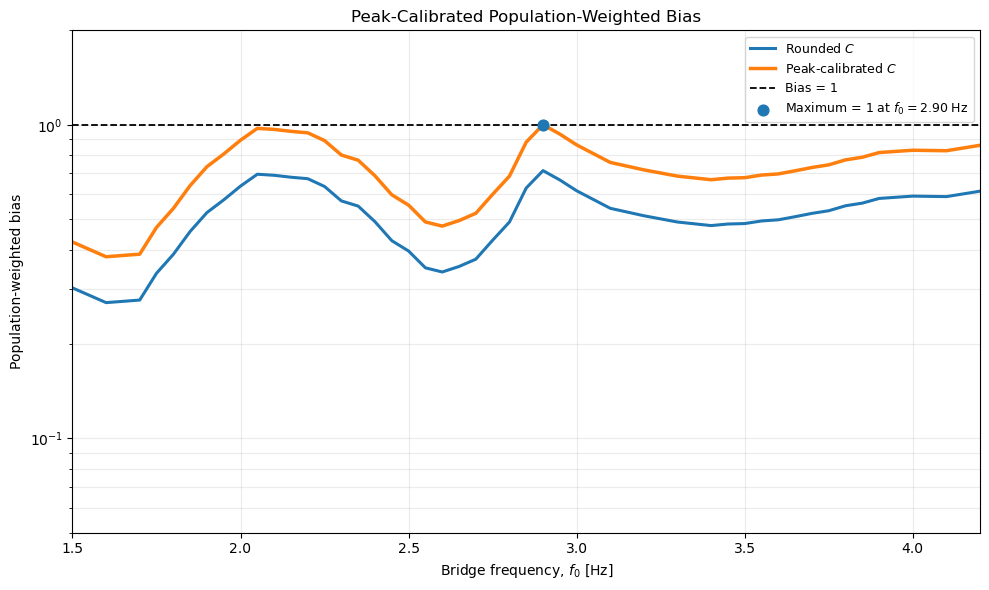


Saved: peak_calibrated_population_weighted_bias.csv


In [27]:
# ============================================================
# FINAL POPULATION CALIBRATION
#
# REQUIREMENT:
#
# Maximum point of the population-weighted bias line = 1
#
# C_final = gamma * C_rounded
#
# Therefore:
#
# B_final = B_rounded / gamma
#
# Choose:
#
# gamma = max_f [B_weighted,rounded(f)]
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE ORIGINAL POPULATION-WEIGHTED ROUNDED-C LINE
# ============================================================

weighted_df["weighted_rounded_for_peak"] = (
    weighted_df["weight"]
    *
    weighted_df["bias_rounded_C"]
)


base_weighted_line = (
    weighted_df
    .groupby(
        "bridge_frequency",
        as_index=False
    )
    .agg(
        B_weighted_rounded=(
            "weighted_rounded_for_peak",
            "sum"
        ),
        weight_sum=(
            "weight",
            "sum"
        )
    )
    .sort_values(
        "bridge_frequency"
    )
)


# ============================================================
# 2. KEEP COMPLETE FREQUENCY RANGE
# ============================================================

base_weighted_line = base_weighted_line[
    (base_weighted_line["bridge_frequency"] >= 1.50)
    &
    (base_weighted_line["bridge_frequency"] <= 4.20)
].copy()


# ============================================================
# 3. FIND MAXIMUM OF WEIGHTED LINE
# ============================================================

peak_idx = (
    base_weighted_line[
        "B_weighted_rounded"
    ]
    .idxmax()
)


B_peak = (
    base_weighted_line.loc[
        peak_idx,
        "B_weighted_rounded"
    ]
)


f_peak = (
    base_weighted_line.loc[
        peak_idx,
        "bridge_frequency"
    ]
)


# ============================================================
# 4. FINAL SCALAR CALIBRATION
#
# This guarantees:
#
# max(B_final) = 1
# ============================================================

gamma_peak = B_peak


print("\n==========================================")
print("PEAK-BASED POPULATION CALIBRATION")
print("==========================================")

print(
    f"Original weighted-line maximum = "
    f"{B_peak:.6f}"
)

print(
    f"Occurs at f = "
    f"{f_peak:.4f} Hz"
)

print(
    f"\ngamma_peak = {gamma_peak:.6f}"
)


# ============================================================
# 5. APPLY gamma TO EVERY INDIVIDUAL BIAS CURVE
# ============================================================

weighted_df[
    "C_final_peak"
] = (
    gamma_peak
    *
    weighted_df["C_rounded"]
)


weighted_df[
    "bias_final_peak"
] = (
    weighted_df["bias_rounded_C"]
    /
    gamma_peak
)


# ============================================================
# 6. RE-CALCULATE WEIGHTED CONTRIBUTIONS
# ============================================================

weighted_df[
    "weighted_final_peak"
] = (
    weighted_df["weight"]
    *
    weighted_df["bias_final_peak"]
)


# ============================================================
# 7. CREATE FINAL POPULATION-WEIGHTED LINE
# ============================================================

final_peak_line = (
    weighted_df
    .groupby(
        "bridge_frequency",
        as_index=False
    )
    .agg(
        B_rounded=(
            "weighted_rounded_for_peak",
            "sum"
        ),
        B_final=(
            "weighted_final_peak",
            "sum"
        ),
        weight_sum=(
            "weight",
            "sum"
        )
    )
    .sort_values(
        "bridge_frequency"
    )
)


final_peak_line = final_peak_line[
    (final_peak_line["bridge_frequency"] >= 1.50)
    &
    (final_peak_line["bridge_frequency"] <= 4.20)
].copy()


# ============================================================
# 8. CHECK THE RESULT
# ============================================================

final_max = (
    final_peak_line[
        "B_final"
    ].max()
)

final_mean = (
    final_peak_line[
        "B_final"
    ].mean()
)

final_min = (
    final_peak_line[
        "B_final"
    ].min()
)


print("\n==========================================")
print("FINAL WEIGHTED-LINE CHECK")
print("==========================================")

print(
    f"Maximum = {final_max:.12f}"
)

print(
    f"Mean    = {final_mean:.6f}"
)

print(
    f"Minimum = {final_min:.6f}"
)


if not np.isclose(
    final_max,
    1.0,
    atol=1e-10
):
    print(
        "\nWARNING: maximum is not exactly 1 "
        "within numerical tolerance."
    )
else:
    print(
        "\nSUCCESS: maximum weighted bias = 1."
    )


# ============================================================
# 9. FINAL CORRECTION EQUATION
# ============================================================

print("\n==========================================")
print("FINAL CORRECTION")
print("==========================================")

print(
    f"C_final = {gamma_peak:.6f} "
    "* (0.60 + 4.00 xi_b - 0.90 mu + 50 mu xi_b)"
)


# Expanded coefficients

a0 = gamma_peak * 0.60
a_xi = gamma_peak * 4.00
a_mu = gamma_peak * (-0.90)
a_muxi = gamma_peak * 50.0


print("\nExpanded form:")

print(
    f"C_final = "
    f"{a0:.6f}"
    f" + {a_xi:.6f} xi_b"
    f" {a_mu:+.6f} mu"
    f" + {a_muxi:.6f} mu xi_b"
)


# ============================================================
# 10. PLOT BEFORE AND AFTER PEAK CALIBRATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.plot(
    final_peak_line[
        "bridge_frequency"
    ],
    final_peak_line[
        "B_rounded"
    ],
    linewidth=2.2,
    label=r"Rounded $C$"
)


ax.plot(
    final_peak_line[
        "bridge_frequency"
    ],
    final_peak_line[
        "B_final"
    ],
    linewidth=2.5,
    label=r"Peak-calibrated $C$"
)


ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Bias = 1"
)


# Mark touching point

ax.scatter(
    [f_peak],
    [1.0],
    s=60,
    zorder=5,
    label=rf"Maximum = 1 at $f_0={f_peak:.2f}$ Hz"
)


ax.set_xlim(
    1.50,
    4.20
)

ax.set_yscale(
    "log"
)

ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(
    "Peak-Calibrated Population-Weighted Bias"
)


ax.grid(
    True,
    which="both",
    alpha=0.25
)

ax.legend(
    fontsize=9
)


plt.tight_layout()
plt.show()


# ============================================================
# 11. SAVE
# ============================================================

final_peak_line.to_csv(
    "peak_calibrated_population_weighted_bias.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSaved: "
    "peak_calibrated_population_weighted_bias.csv"
)

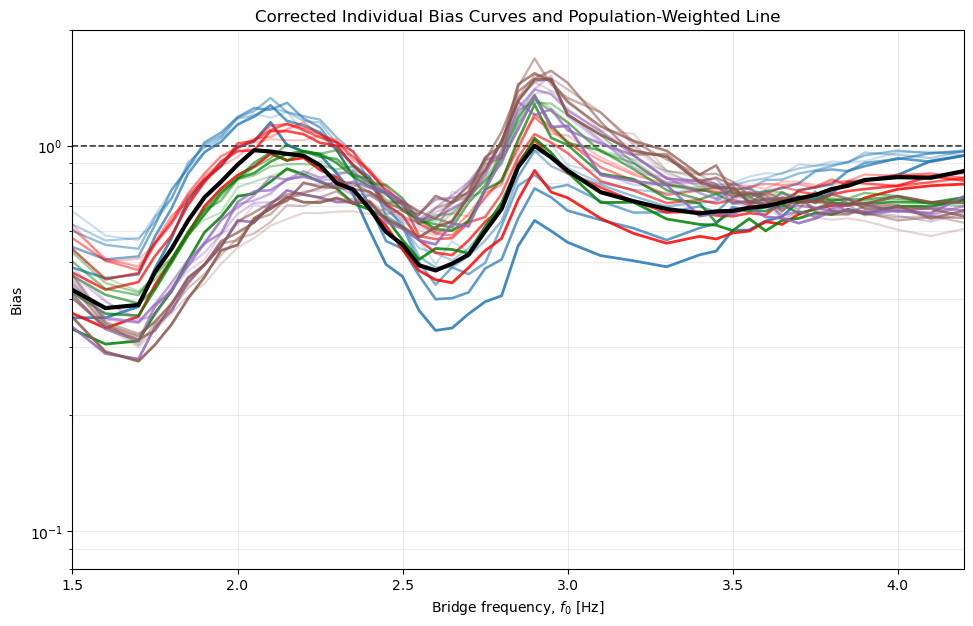

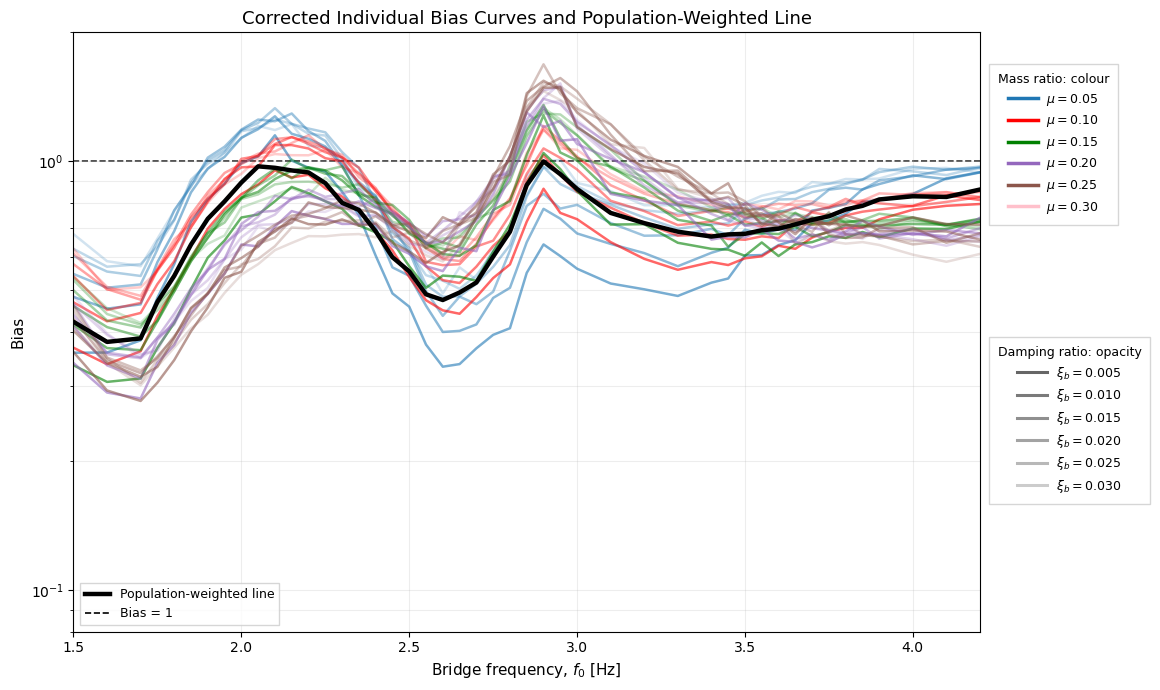

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# SETTINGS
# ============================================================

BIAS_COLUMN = "bias_final_peak"   # change if needed
WEIGHTED_COLUMN = "B_final"       # matching weighted line
WEIGHTED_LABEL = "Population-weighted line"

F_MIN = 1.50
F_MAX = 4.20

# ------------------------------------------------------------
# REMOVE mu = 0.01
# Keep only these mass ratios
# ------------------------------------------------------------
MU_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Keep all damping ratios
XI_VALUES = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]


# ============================================================
# CHECK REQUIRED VARIABLES
# ============================================================

required_objects = ["weighted_df", "final_peak_line"]
missing_objects = [x for x in required_objects if x not in globals()]

if missing_objects:
    raise NameError(
        "Run the previous population-weighting code first.\n"
        f"Missing objects: {missing_objects}"
    )

required_columns_weighted_df = [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    BIAS_COLUMN,
]

missing_cols = [
    c for c in required_columns_weighted_df
    if c not in weighted_df.columns
]

if missing_cols:
    raise KeyError(
        "weighted_df is missing required columns:\n"
        f"{missing_cols}"
    )

if WEIGHTED_COLUMN not in final_peak_line.columns:
    raise KeyError(
        f"final_peak_line does not contain '{WEIGHTED_COLUMN}'."
    )


# ============================================================
# FILTER DATA
# ============================================================

plot_df = weighted_df.copy()

plot_df = plot_df[
    (plot_df["bridge_frequency"] >= F_MIN)
    &
    (plot_df["bridge_frequency"] <= F_MAX)
].copy()

weighted_line_df = final_peak_line.copy()

weighted_line_df = weighted_line_df[
    (weighted_line_df["bridge_frequency"] >= F_MIN)
    &
    (weighted_line_df["bridge_frequency"] <= F_MAX)
].copy()


# ============================================================
# STYLE MAPS
# ============================================================

# One colour per mass ratio
mu_colors = {
    0.05: "tab:blue",
    0.10: "red",
    0.15: "green",
    0.20: "tab:purple",
    0.25: "tab:brown",
    0.30: "pink",
}

# MORE transparent coloured lines (lower alpha)
xi_alpha = {
    0.005: 0.85,
    0.010: 0.72,
    0.015: 0.60,
    0.020: 0.48,
    0.025: 0.36,
    0.030: 0.24,
}

# Line widths for damping categories
xi_lw = {
    0.005: 2.0,
    0.010: 1.9,
    0.015: 1.8,
    0.020: 1.7,
    0.025: 1.6,
    0.030: 1.5,
}


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11.5, 7))

# ------------------------------------------------------------
# Plot all individual curves
# ------------------------------------------------------------
for mu in MU_VALUES:
    for xi in XI_VALUES:

        sub = plot_df[
            np.isclose(plot_df["mass_ratio"], mu)
            &
            np.isclose(plot_df["target_beamdamp"], xi)
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        ax.plot(
            sub["bridge_frequency"],
            sub[BIAS_COLUMN],
            color=mu_colors[mu],
            alpha=xi_alpha[xi],
            linewidth=xi_lw[xi],
            zorder=2,
        )

# ------------------------------------------------------------
# Plot weighted line
# ------------------------------------------------------------
weighted_line_df = weighted_line_df.sort_values("bridge_frequency")

ax.plot(
    weighted_line_df["bridge_frequency"],
    weighted_line_df[WEIGHTED_COLUMN],
    color="black",
    linewidth=3.0,
    label=WEIGHTED_LABEL,
    zorder=10,
)

# ------------------------------------------------------------
# Bias = 1
# ------------------------------------------------------------
ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label="Bias = 1",
    zorder=1,
)


# ============================================================
# AXES
# ============================================================

ax.set_xlim(F_MIN, F_MAX)
ax.set_yscale("log")
ax.set_ylim(0.08, 2.0)

ax.set_xlabel(r"Bridge frequency, $f_0$ [Hz]")
ax.set_ylabel("Bias")

ax.set_title(
    "Corrected Individual Bias Curves and Population-Weighted Line"
)

ax.grid(True, which="both", alpha=0.25)


# ============================================================
# STYLE MAPS
# ============================================================

MU_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

XI_VALUES = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

mu_colors = {
    0.05: "tab:blue",
    0.10: "red",
    0.15: "green",
    0.20: "tab:purple",
    0.25: "tab:brown",
    0.30: "pink",
}

# More transparent individual curves
xi_alpha = {
    0.005: 0.60,
    0.010: 0.52,
    0.015: 0.44,
    0.020: 0.36,
    0.025: 0.28,
    0.030: 0.20,
}

# Keep linewidth approximately similar
xi_lw = {
    0.005: 1.8,
    0.010: 1.8,
    0.015: 1.8,
    0.020: 1.8,
    0.025: 1.8,
    0.030: 1.8,
}


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(12.5, 7))

# IMPORTANT:
# Reserve a large strip on the right for the two legends
fig.subplots_adjust(
    left=0.09,
    right=0.77,
    bottom=0.12,
    top=0.92
)


# ============================================================
# INDIVIDUAL BIAS CURVES
# ============================================================

for mu in MU_VALUES:

    for xi in XI_VALUES:

        sub = plot_df[
            np.isclose(plot_df["mass_ratio"], mu)
            &
            np.isclose(plot_df["target_beamdamp"], xi)
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("bridge_frequency")

        ax.plot(
            sub["bridge_frequency"],
            sub[BIAS_COLUMN],
            color=mu_colors[mu],
            alpha=xi_alpha[xi],
            linewidth=xi_lw[xi],
            zorder=2,
        )


# ============================================================
# POPULATION-WEIGHTED LINE
# ============================================================

weighted_line_df = weighted_line_df.sort_values(
    "bridge_frequency"
)

ax.plot(
    weighted_line_df["bridge_frequency"],
    weighted_line_df[WEIGHTED_COLUMN],
    color="black",
    linewidth=3.2,
    zorder=10,
)


# ============================================================
# BIAS = 1
# ============================================================

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    zorder=1,
)


# ============================================================
# AXES
# ============================================================

ax.set_xlim(F_MIN, F_MAX)

ax.set_yscale("log")
ax.set_ylim(0.08, 2.0)

ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]",
    fontsize=11
)

ax.set_ylabel(
    "Bias",
    fontsize=11
)

ax.set_title(
    "Corrected Individual Bias Curves and Population-Weighted Line",
    fontsize=13
)

ax.grid(
    True,
    which="both",
    alpha=0.22
)


# ============================================================
# LEGEND 1:
# MASS RATIO = COLOUR
# ============================================================

mu_handles = [

    Line2D(
        [0], [0],
        color=mu_colors[mu],
        linewidth=2.5,
        alpha=1.0,
        label=rf"$\mu = {mu:.2f}$"
    )

    for mu in MU_VALUES
]


legend_mu = fig.legend(
    handles=mu_handles,
    title="Mass ratio: colour",

    # figure coordinates
    loc="upper left",
    bbox_to_anchor=(0.79, 0.91),

    frameon=True,
    fancybox=False,

    fontsize=9,
    title_fontsize=9,

    borderpad=0.7,
    labelspacing=0.45,

    handlelength=2.4,
    handletextpad=0.7,
)


# ============================================================
# LEGEND 2:
# DAMPING RATIO = OPACITY
# ============================================================

xi_handles = [

    Line2D(
        [0], [0],
        color="black",
        linewidth=2.2,
        alpha=xi_alpha[xi],
        label=rf"$\xi_b = {xi:.3f}$"
    )

    for xi in XI_VALUES
]


legend_xi = fig.legend(
    handles=xi_handles,
    title="Damping ratio: opacity",

    loc="upper left",
    bbox_to_anchor=(0.79, 0.52),

    frameon=True,
    fancybox=False,

    fontsize=9,
    title_fontsize=9,

    borderpad=0.7,
    labelspacing=0.45,

    handlelength=2.4,
    handletextpad=0.7,
)


# ============================================================
# LEGEND 3:
# MAIN LINES
# ============================================================

main_handles = [

    Line2D(
        [0], [0],
        color="black",
        linewidth=3.2,
        label="Population-weighted line"
    ),

    Line2D(
        [0], [0],
        color="black",
        linewidth=1.2,
        linestyle="--",
        label="Bias = 1"
    ),
]


ax.legend(
    handles=main_handles,
    loc="lower left",
    frameon=True,
    fancybox=False,
    fontsize=9,
)


# ============================================================
# SHOW
# ============================================================


# leave space on right for legends
plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()


POPULATION WEIGHT CHECK
Number of weighted (mu, xi_b) cells = 36
Sum of weights = 1.000000000000

The SAME population weights will be used for every percentile.

PROCESSING PERCENTILE = 50

Shifted equation:
C_50 = 0.30143484 +7.34339890 xi_b -0.18133397 mu +0.57616072 mu*xi_b

OLS fit: R2 = 0.962433, RMSE = 0.012823
After +0.050 intercept shift: R2 = 0.391298, RMSE = 0.051618

PROCESSING PERCENTILE = 52.5

Shifted equation:
C_52.5 = 0.32185568 +6.87152996 xi_b -0.27071605 mu +3.15344755 mu*xi_b

OLS fit: R2 = 0.963538, RMSE = 0.012577
After +0.050 intercept shift: R2 = 0.387244, RMSE = 0.051557

PROCESSING PERCENTILE = 55

Shifted equation:
C_55 = 0.34427799 +6.22839038 xi_b -0.37335555 mu +6.76456086 mu*xi_b

OLS fit: R2 = 0.965226, RMSE = 0.012200
After +0.050 intercept shift: R2 = 0.381133, RMSE = 0.051467

PROCESSING PERCENTILE = 57.5

Shifted equation:
C_57.5 = 0.35077319 +6.57760261 xi_b -0.38690433 mu +4.96516681 mu*xi_b

OLS fit: R2 = 0.973407, RMSE = 0.010988
After +0.050 in

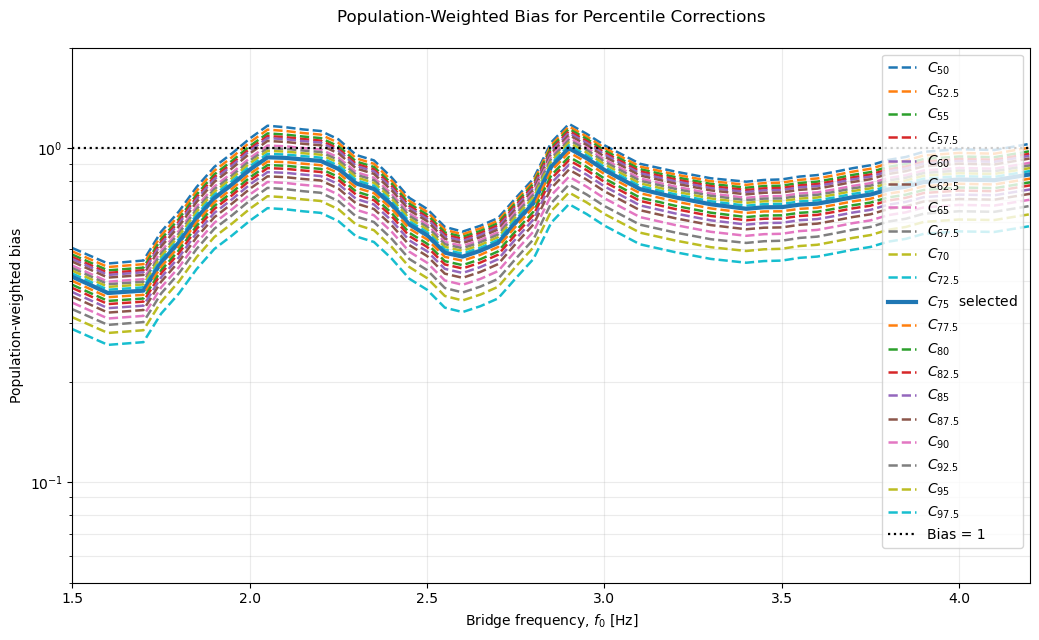

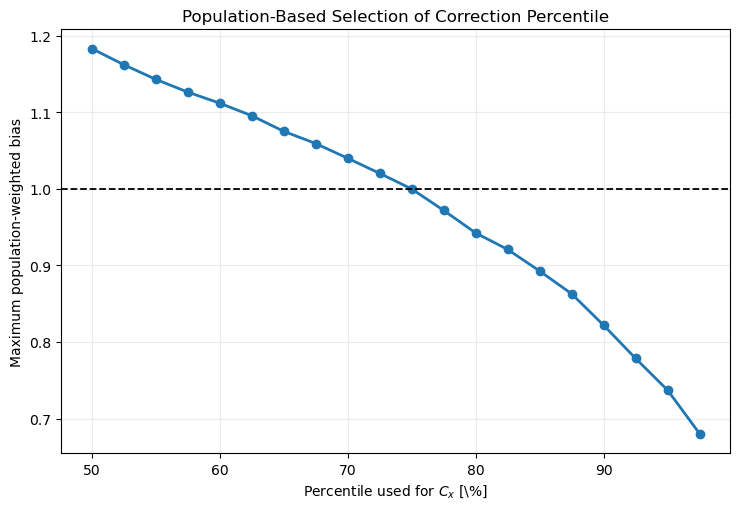


Saved:
Cx_raw_percentile_points_and_fits.csv
Cx_candidate_equations.csv
Cx_percentile_selection_summary.csv
Cx_population_weighted_bias_lines.csv
Cx_candidate_detailed_bias.csv


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# POPULATION-BASED SELECTION OF C_x PERCENTILE
# ============================================================
#
# For each percentile x:
#
# 1. Calculate C_x(mu, xi_b)
#    = xth percentile across bridge frequency
#      for each fixed (mu, xi_b) combination
#
# 2. Fit:
#
#    C_x =
#    b0 + b_xi xi_b + b_mu mu + b_muxi mu xi_b
#
# 3. Add manual safety shift:
#
#    b0_shifted = b0 + 0.05
#
# 4. Recalculate:
#
#    B_final =
#    B_after_new_psi / C_x_fit_shifted
#
# 5. Apply SAME population weights w_jk
#
# 6. Form:
#
#    B_W,x(f)
#    =
#    sum_j sum_k w_jk B_jk,x(f)
#
# 7. Select the percentile whose MAXIMUM weighted bias
#    has the smallest gap to Bias = 1
#
# ============================================================


# ============================================================
# 1. SETTINGS
# ============================================================

PERCENTILES = [
    50.0,
    52.5,
    55.0,
    57.5,
    60.0,
    62.5,
    65.0,
    67.5,
    70.0,
    72.5,
    75.0,
    77.5,
    80.0,
    82.5,
    85.0,
    87.5,
    90.0,
    92.5,
    95.0,
    97.5,
]

# Manual safety margin added AFTER curve fitting
SAFETY_SHIFT = 0.05

MEASURE = "Peak absolute acceleration"


# ------------------------------------------------------------
# Frequency range used to calculate C_x
#
# Your earlier P95 calculation used 1.50–4.40 Hz.
# ------------------------------------------------------------

CX_FMIN = 1.50
CX_FMAX = 4.40


# ------------------------------------------------------------
# Frequency range used to judge final weighted bias
# ------------------------------------------------------------

EVAL_FMIN = 1.50
EVAL_FMAX = 4.20


# Numerical matching
MU_KEY_DECIMALS = 4
XI_KEY_DECIMALS = 4
FREQ_KEY_DECIMALS = 6


# ============================================================
# 2. CHECK INPUT DATA
# ============================================================

if "plot_all_df" not in globals():

    raise NameError(
        "plot_all_df is missing.\n"
        "Run the new-psi bias code first."
    )


# ============================================================
# 3. GET POPULATION WEIGHTS
#
# These weights stay IDENTICAL for all percentiles.
# ============================================================

if "weights_df" in globals():

    W = weights_df[
        [
            "mu",
            "xi_b",
            "weight",
        ]
    ].copy()

else:

    print(
        "weights_df not found in memory. "
        "Loading bias_line_weights.csv"
    )

    W = pd.read_csv(
        "bias_line_weights.csv",
        encoding="utf-8-sig"
    )

    W = W[
        [
            "mu",
            "xi_b",
            "weight",
        ]
    ].copy()


# ============================================================
# 4. CHECK REQUIRED BIAS COLUMNS
# ============================================================

required_bias_columns = [

    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "measure",
    "newpsi_bias_mean",

]


missing_columns = [

    column

    for column in required_bias_columns

    if column not in plot_all_df.columns

]


if missing_columns:

    raise KeyError(

        "plot_all_df is missing columns:\n"
        f"{missing_columns}"

    )


# ============================================================
# 5. CLEAN WEIGHTS
# ============================================================

for column in [

    "mu",
    "xi_b",
    "weight",

]:

    W[column] = pd.to_numeric(
        W[column],
        errors="coerce"
    )


W = W.dropna(
    subset=[
        "mu",
        "xi_b",
        "weight",
    ]
).copy()


weight_sum = W["weight"].sum()


print("\n============================================================")
print("POPULATION WEIGHT CHECK")
print("============================================================")

print(
    f"Number of weighted (mu, xi_b) cells = "
    f"{len(W)}"
)

print(
    f"Sum of weights = "
    f"{weight_sum:.12f}"
)


if not np.isclose(
    weight_sum,
    1.0,
    atol=1e-10
):

    raise ValueError(

        "Population weights do not sum to 1.\n"
        f"Current sum = {weight_sum:.12f}"

    )


W["mu_key"] = (
    W["mu"]
    .round(MU_KEY_DECIMALS)
)

W["xi_key"] = (
    W["xi_b"]
    .round(XI_KEY_DECIMALS)
)


if W.duplicated(
    [
        "mu_key",
        "xi_key",
    ]
).any():

    raise ValueError(
        "Duplicate population-weight cells found."
    )


print(
    "\nThe SAME population weights will be used "
    "for every percentile."
)


# ============================================================
# 6. PREPARE NEW-PSI BIAS DATA
# ============================================================

bias_df = plot_all_df.copy()


for column in [

    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "newpsi_bias_mean",

]:

    bias_df[column] = pd.to_numeric(
        bias_df[column],
        errors="coerce"
    )


bias_df["measure"] = (
    bias_df["measure"]
    .astype(str)
    .str.strip()
)


bias_df = bias_df[

    bias_df["measure"].eq(
        MEASURE
    )

].copy()


bias_df = bias_df.dropna(

    subset=[

        "bridge_frequency",
        "mass_ratio",
        "target_beamdamp",
        "newpsi_bias_mean",

    ]

).copy()


bias_df = bias_df[

    np.isfinite(
        bias_df["newpsi_bias_mean"]
    )

].copy()


# Matching keys

bias_df["mu_key"] = (
    bias_df["mass_ratio"]
    .round(MU_KEY_DECIMALS)
)

bias_df["xi_key"] = (
    bias_df["target_beamdamp"]
    .round(XI_KEY_DECIMALS)
)

bias_df["f_key"] = (
    bias_df["bridge_frequency"]
    .round(FREQ_KEY_DECIMALS)
)


# ============================================================
# 7. KEEP ONLY POPULATION-WEIGHTED CELLS
# ============================================================

bias_df = bias_df.merge(

    W[
        [
            "mu_key",
            "xi_key",
        ]
    ],

    on=[
        "mu_key",
        "xi_key",
    ],

    how="inner",

)


if bias_df.empty:

    raise ValueError(
        "No overlap between bias data and population weights."
    )


expected_cells = set(

    zip(
        W["mu_key"],
        W["xi_key"]
    )

)


available_cells = set(

    zip(
        bias_df["mu_key"],
        bias_df["xi_key"]
    )

)


missing_cells = (
    expected_cells
    -
    available_cells
)


if missing_cells:

    raise ValueError(

        "Some population-weighted cells have "
        "no bias data:\n"
        f"{sorted(missing_cells)}"

    )


# ============================================================
# 8. SIMPLE C_x MODEL
#
# C_x =
#
# b0
# + b_xi xi_b
# + b_mu mu
# + b_muxi mu xi_b
#
# ============================================================

def design_matrix(
    mu,
    xi
):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )


    return np.column_stack(

        [

            np.ones_like(mu),

            xi,

            mu,

            mu * xi,

        ]

    )


def predict_C(
    mu,
    xi,
    beta
):

    X = design_matrix(
        mu,
        xi
    )

    return (
        X
        @
        np.asarray(
            beta,
            dtype=float
        )
    )


# ============================================================
# 9. FIT STATISTICS
# ============================================================

def calculate_r2(
    observed,
    predicted
):

    observed = np.asarray(
        observed,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )


    ss_res = np.sum(

        (
            observed
            -
            predicted
        ) ** 2

    )


    ss_tot = np.sum(

        (
            observed
            -
            np.mean(observed)
        ) ** 2

    )


    if ss_tot <= 0:

        return np.nan


    return (
        1.0
        -
        ss_res / ss_tot
    )


def calculate_rmse(
    observed,
    predicted
):

    observed = np.asarray(
        observed,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.sqrt(

            np.mean(

                (
                    observed
                    -
                    predicted
                ) ** 2

            )

        )

    )


# ============================================================
# 10. EQUATION PRINTING FUNCTION
# ============================================================

def equation_text(
    percentile,
    beta
):

    b0 = beta[0]
    bxi = beta[1]
    bmu = beta[2]
    bmuxi = beta[3]


    return (

        f"C_{percentile:g} = "

        f"{b0:.8f} "

        f"{bxi:+.8f} xi_b "

        f"{bmu:+.8f} mu "

        f"{bmuxi:+.8f} mu*xi_b"

    )


# ============================================================
# 11. DATA USED TO CALCULATE RAW C_x
# ============================================================

cx_source = bias_df[

    (
        bias_df["bridge_frequency"]
        >=
        CX_FMIN
    )

    &

    (
        bias_df["bridge_frequency"]
        <=
        CX_FMAX
    )

].copy()


if cx_source.empty:

    raise ValueError(
        "No data inside the C_x frequency range."
    )


# ============================================================
# 12. CALCULATE RAW C_x FOR EACH PERCENTILE
# ============================================================

raw_cx_tables = {}


for percentile in PERCENTILES:


    cx = (

        cx_source

        .groupby(
            [
                "mu_key",
                "xi_key",
            ],
            as_index=False
        )

        ["newpsi_bias_mean"]

        .quantile(
            percentile / 100.0
        )

        .rename(

            columns={

                "newpsi_bias_mean":
                    "C_raw"

            }

        )

    )


    cx["percentile"] = percentile


    raw_cx_tables[
        percentile
    ] = cx


# ============================================================
# STORAGE
# ============================================================

summary_rows = []

equation_rows = []

weighted_line_parts = []

detailed_parts = []

raw_point_parts = []


# ============================================================
# 13. PROCESS EACH PERCENTILE
# ============================================================

for percentile in PERCENTILES:


    print(
        "\n============================================================"
    )

    print(
        f"PROCESSING PERCENTILE = "
        f"{percentile:g}"
    )

    print(
        "============================================================"
    )


    cx = (
        raw_cx_tables[
            percentile
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Check every weighted cell exists
    # --------------------------------------------------------

    cx_cells = set(

        zip(
            cx["mu_key"],
            cx["xi_key"]
        )

    )


    if cx_cells != expected_cells:


        missing_here = (
            expected_cells
            -
            cx_cells
        )


        extra_here = (
            cx_cells
            -
            expected_cells
        )


        raise ValueError(

            f"Percentile {percentile:g}: "
            f"C_x cell mismatch.\n"
            f"Missing = {sorted(missing_here)}\n"
            f"Extra = {sorted(extra_here)}"

        )


    # ========================================================
    # 14. FIT C_x(mu, xi_b)
    # ========================================================

    mu_raw = (
        cx["mu_key"]
        .to_numpy(
            dtype=float
        )
    )


    xi_raw = (
        cx["xi_key"]
        .to_numpy(
            dtype=float
        )
    )


    C_raw = (
        cx["C_raw"]
        .to_numpy(
            dtype=float
        )
    )


    X = design_matrix(
        mu_raw,
        xi_raw
    )


    beta, *_ = np.linalg.lstsq(

        X,

        C_raw,

        rcond=None

    )


    C_fit = (
        X @ beta
    )


    # ========================================================
    # 15. MANUAL SAFETY SHIFT
    #
    # Add +0.05 to INTERCEPT ONLY.
    #
    # NO REFITTING.
    # ========================================================

    beta_shifted = (
        beta.copy()
    )


    beta_shifted[0] = (

        beta_shifted[0]
        +
        SAFETY_SHIFT

    )


    C_fit_shifted = (

        X
        @
        beta_shifted

    )


    # ========================================================
    # 16. FIT STATISTICS
    # ========================================================

    R2_OLS = calculate_r2(
        C_raw,
        C_fit
    )


    RMSE_OLS = calculate_rmse(
        C_raw,
        C_fit
    )


    R2_shifted = calculate_r2(
        C_raw,
        C_fit_shifted
    )


    RMSE_shifted = calculate_rmse(
        C_raw,
        C_fit_shifted
    )


    cx["C_fit"] = C_fit

    cx[
        "C_fit_shifted"
    ] = C_fit_shifted


    raw_point_parts.append(
        cx.copy()
    )


    # ========================================================
    # 17. STORE EQUATION
    # ========================================================

    b0 = beta_shifted[0]

    bxi = beta_shifted[1]

    bmu = beta_shifted[2]

    bmuxi = beta_shifted[3]


    equation = equation_text(
        percentile,
        beta_shifted
    )


    equation_rows.append(

        {

            "percentile":
                percentile,

            "safety_shift":
                SAFETY_SHIFT,

            "intercept_shifted":
                b0,

            "coef_xi":
                bxi,

            "coef_mu":
                bmu,

            "coef_mu_xi":
                bmuxi,

            "R2_OLS":
                R2_OLS,

            "RMSE_OLS":
                RMSE_OLS,

            "R2_after_shift":
                R2_shifted,

            "RMSE_after_shift":
                RMSE_shifted,

            "equation":
                equation,

        }

    )


    print(
        "\nShifted equation:"
    )

    print(
        equation
    )


    print(
        f"\nOLS fit:"
        f" R2 = {R2_OLS:.6f},"
        f" RMSE = {RMSE_OLS:.6f}"
    )


    print(
        f"After +{SAFETY_SHIFT:.3f} intercept shift:"
        f" R2 = {R2_shifted:.6f},"
        f" RMSE = {RMSE_shifted:.6f}"
    )


    # ========================================================
    # 18. APPLY FITTED C_x EQUATION TO ALL BIAS CURVES
    # ========================================================

    candidate = bias_df[

        (
            bias_df["bridge_frequency"]
            >=
            EVAL_FMIN
        )

        &

        (
            bias_df["bridge_frequency"]
            <=
            EVAL_FMAX
        )

    ].copy()


    candidate[
        "C_candidate"
    ] = predict_C(

        candidate[
            "mass_ratio"
        ].to_numpy(
            dtype=float
        ),

        candidate[
            "target_beamdamp"
        ].to_numpy(
            dtype=float
        ),

        beta_shifted

    )


    # C must remain positive

    if (
        candidate[
            "C_candidate"
        ]
        <=
        0
    ).any():


        bad = candidate.loc[

            candidate[
                "C_candidate"
            ]
            <=
            0,

            [
                "mass_ratio",
                "target_beamdamp",
                "C_candidate",
            ]

        ]


        raise ValueError(

            f"Percentile {percentile:g}: "
            "fitted C became non-positive:\n"

            +

            bad
            .drop_duplicates()
            .to_string(
                index=False
            )

        )


    # ========================================================
    # 19. RECALCULATE BIAS
    #
    # B_final =
    #
    # newpsi_bias_mean / C_x
    # ========================================================

    candidate[
        "bias_after_Cx"
    ] = (

        candidate[
            "newpsi_bias_mean"
        ]

        /

        candidate[
            "C_candidate"
        ]

    )


    # ========================================================
    # 20. ADD THE SAME POPULATION WEIGHTS
    # ========================================================

    candidate = candidate.merge(

        W[
            [
                "mu_key",
                "xi_key",
                "weight",
            ]
        ],

        on=[
            "mu_key",
            "xi_key",
        ],

        how="left",

        validate="many_to_one",

    )


    if candidate[
        "weight"
    ].isna().any():

        raise ValueError(

            f"Percentile {percentile:g}: "
            "some bias rows did not receive a weight."

        )


    # ========================================================
    # 21. CHECK COMPLETE 36-LINE GRID AT EACH FREQUENCY
    # ========================================================

    coverage = (

        candidate

        .groupby(
            "f_key"
        )

        .agg(

            weight_sum=(
                "weight",
                "sum"
            ),

            n_cells=(
                "weight",
                "size"
            ),

        )

        .reset_index()

    )


    good_frequencies = coverage[

        np.isclose(
            coverage[
                "weight_sum"
            ],
            1.0,
            atol=1e-8
        )

        &

        (
            coverage[
                "n_cells"
            ]
            ==
            len(W)
        )

    ][
        "f_key"
    ]


    dropped_frequencies = coverage[

        ~coverage[
            "f_key"
        ].isin(
            good_frequencies
        )

    ][
        "f_key"
    ]


    if len(
        dropped_frequencies
    ) > 0:

        print(

            f"\nDropping "
            f"{len(dropped_frequencies)} "
            "frequency points because they "
            "do not contain the complete "
            "weighted grid."

        )


    candidate = candidate[

        candidate[
            "f_key"
        ].isin(
            good_frequencies
        )

    ].copy()


    if candidate.empty:

        raise ValueError(

            f"Percentile {percentile:g}: "
            "no complete weighted frequencies remain."

        )


    # ========================================================
    # 22. WEIGHT EACH INDIVIDUAL BIAS LINE
    # ========================================================

    candidate[
        "weighted_contribution"
    ] = (

        candidate[
            "weight"
        ]

        *

        candidate[
            "bias_after_Cx"
        ]

    )


    # ========================================================
    # 23. CREATE ONE POPULATION-WEIGHTED LINE
    # ========================================================

    weighted_line = (

        candidate

        .groupby(
            "f_key",
            as_index=False
        )

        .agg(

            bridge_frequency=(
                "bridge_frequency",
                "mean"
            ),

            B_weighted=(
                "weighted_contribution",
                "sum"
            ),

            weight_sum=(
                "weight",
                "sum"
            ),

        )

        .sort_values(
            "bridge_frequency"
        )

    )


    # ========================================================
    # 24. FIND MAXIMUM OF WEIGHTED LINE
    # ========================================================

    peak_index = (

        weighted_line[
            "B_weighted"
        ]
        .idxmax()

    )


    peak_bias = float(

        weighted_line.loc[
            peak_index,
            "B_weighted"
        ]

    )


    peak_frequency = float(

        weighted_line.loc[
            peak_index,
            "bridge_frequency"
        ]

    )


    # The exact criterion you requested:
    #
    # distance between highest point and Bias = 1

    peak_gap = abs(
        1.0
        -
        peak_bias
    )


    summary_rows.append(

        {

            "percentile":
                percentile,

            "weighted_peak_bias":
                peak_bias,

            "peak_frequency_Hz":
                peak_frequency,

            "absolute_gap_to_1":
                peak_gap,

            "weighted_mean_bias":
                float(
                    weighted_line[
                        "B_weighted"
                    ].mean()
                ),

            "weighted_min_bias":
                float(
                    weighted_line[
                        "B_weighted"
                    ].min()
                ),

            "peak_at_or_below_1":
                bool(
                    peak_bias
                    <=
                    1.0 + 1e-12
                ),

        }

    )


    weighted_line[
        "percentile"
    ] = percentile


    weighted_line_parts.append(
        weighted_line
    )


    candidate[
        "percentile"
    ] = percentile


    detailed_parts.append(
        candidate
    )


# ============================================================
# 25. COMBINE RESULTS
# ============================================================

selection_df = pd.DataFrame(
    summary_rows
).sort_values(
    "percentile"
).reset_index(
    drop=True
)


equation_df = pd.DataFrame(
    equation_rows
).sort_values(
    "percentile"
).reset_index(
    drop=True
)


all_weighted_lines = pd.concat(
    weighted_line_parts,
    ignore_index=True
)


all_detailed = pd.concat(
    detailed_parts,
    ignore_index=True
)


all_raw_cx = pd.concat(
    raw_point_parts,
    ignore_index=True
)


# ============================================================
# 26. SELECT BEST PERCENTILE
#
# PRIMARY CRITERION:
#
# min | max(B_W,x) - 1 |
# ============================================================

best_index = (

    selection_df[
        "absolute_gap_to_1"
    ]
    .idxmin()

)


best = selection_df.loc[
    best_index
]


best_percentile = float(
    best[
        "percentile"
    ]
)


# ============================================================
# 27. ALSO FIND BEST CONSERVATIVE OPTION
#
# max weighted bias <= 1
# ============================================================

conservative_candidates = selection_df[

    selection_df[
        "peak_at_or_below_1"
    ]

].copy()


if not conservative_candidates.empty:


    best_conservative_index = (

        conservative_candidates[
            "absolute_gap_to_1"
        ]
        .idxmin()

    )


    best_conservative = (

        conservative_candidates.loc[
            best_conservative_index
        ]

    )


else:

    best_conservative = None


# ============================================================
# 28. PRINT SELECTION TABLE
# ============================================================

print(
    "\n============================================================"
)

print(
    "PERCENTILE SELECTION SUMMARY"
)

print(
    "============================================================"
)


print(

    selection_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


# ============================================================
# 29. PRINT ALL FINAL C_x EQUATIONS
# ============================================================

print(
    "\n============================================================"
)

print(
    "FINAL SHIFTED C_x EQUATIONS"
)

print(
    "============================================================"
)


for _, row in equation_df.iterrows():


    print(
        f"\nPercentile "
        f"{row['percentile']:g}"
    )


    print(
        row["equation"]
    )


    print(

        f"OLS: "
        f"R2 = {row['R2_OLS']:.6f}, "
        f"RMSE = {row['RMSE_OLS']:.6f}"

    )


    print(

        f"After +{SAFETY_SHIFT:.3f} intercept shift: "
        f"R2 = {row['R2_after_shift']:.6f}, "
        f"RMSE = {row['RMSE_after_shift']:.6f}"

    )


# ============================================================
# 30. PRINT WINNER
# ============================================================

best_equation = equation_df.loc[

    np.isclose(

        equation_df[
            "percentile"
        ],

        best_percentile

    ),

    "equation"

].iloc[0]


print(
    "\n============================================================"
)

print(
    "BEST BY PEAK-GAP CRITERION"
)

print(
    "============================================================"
)


print(
    f"Selected percentile = "
    f"{best_percentile:g}"
)


print(
    f"Maximum weighted bias = "
    f"{best['weighted_peak_bias']:.6f}"
)


print(
    f"Peak frequency = "
    f"{best['peak_frequency_Hz']:.4f} Hz"
)


print(
    f"Gap between maximum and Bias = 1 = "
    f"{best['absolute_gap_to_1']:.6f}"
)


print(
    "\nSelected equation:"
)

print(
    best_equation
)


# ============================================================
# 31. PRINT BEST OPTION THAT DOES NOT EXCEED 1
# ============================================================

if best_conservative is not None:


    conservative_percentile = float(

        best_conservative[
            "percentile"
        ]

    )


    conservative_equation = equation_df.loc[

        np.isclose(

            equation_df[
                "percentile"
            ],

            conservative_percentile

        ),

        "equation"

    ].iloc[0]


    print(
        "\n============================================================"
    )

    print(
        "BEST CANDIDATE WITH MAX WEIGHTED BIAS <= 1"
    )

    print(
        "============================================================"
    )


    print(
        f"Selected percentile = "
        f"{conservative_percentile:g}"
    )


    print(
        f"Maximum weighted bias = "
        f"{best_conservative['weighted_peak_bias']:.6f}"
    )


    print(
        f"Gap below Bias = 1 = "
        f"{1.0 - best_conservative['weighted_peak_bias']:.6f}"
    )


    print(
        "\nEquation:"
    )


    print(
        conservative_equation
    )


else:


    print(

        "\nNo tested percentile produced "
        "a weighted maximum <= 1."

    )


# ============================================================
# 32. PLOT ALL POPULATION-WEIGHTED LINES
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        10.5,
        6.5
    )
)


for percentile in PERCENTILES:


    sub = all_weighted_lines[

        np.isclose(

            all_weighted_lines[
                "percentile"
            ],

            percentile

        )

    ].sort_values(
        "bridge_frequency"
    )


    selected = np.isclose(

        percentile,
        best_percentile

    )


    ax.plot(

        sub[
            "bridge_frequency"
        ],

        sub[
            "B_weighted"
        ],

        linewidth=(
            3.0
            if selected
            else
            1.8
        ),

        linestyle=(
            "-"
            if selected
            else
            "--"
        ),

        label=(

            rf"$C_{{{percentile:g}}}$"

            +

            (
                "  selected"
                if selected
                else
                ""
            )

        )

    )


ax.axhline(

    1.0,

    color="black",

    linestyle=":",

    linewidth=1.6,

    label="Bias = 1"

)


ax.set_xlim(
    EVAL_FMIN,
    EVAL_FMAX
)


ax.set_yscale(
    "log"
)


ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(

    "Population-Weighted Bias for Percentile Corrections\n"

)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 33. PLOT MAXIMUM WEIGHTED BIAS VS PERCENTILE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7.5,
        5.2
    )
)


ax.plot(

    selection_df[
        "percentile"
    ],

    selection_df[
        "weighted_peak_bias"
    ],

    marker="o",

    linewidth=2.0

)


ax.axhline(

    1.0,

    color="black",

    linestyle="--",

    linewidth=1.3

)


ax.set_xlabel(
    r"Percentile used for $C_x$ [\%]"
)


ax.set_ylabel(
    "Maximum population-weighted bias"
)


ax.set_title(
    "Population-Based Selection of Correction Percentile"
)


ax.grid(
    True,
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 34. SAVE EVERYTHING
# ============================================================

all_raw_cx.to_csv(

    "Cx_raw_percentile_points_and_fits.csv",

    index=False,

    encoding="utf-8-sig"

)


equation_df.to_csv(

    "Cx_candidate_equations.csv",

    index=False,

    encoding="utf-8-sig"

)


selection_df.to_csv(

    "Cx_percentile_selection_summary.csv",

    index=False,

    encoding="utf-8-sig"

)


all_weighted_lines.to_csv(

    "Cx_population_weighted_bias_lines.csv",

    index=False,

    encoding="utf-8-sig"

)


all_detailed.to_csv(

    "Cx_candidate_detailed_bias.csv",

    index=False,

    encoding="utf-8-sig"

)


print(
    "\nSaved:"
)

print(
    "Cx_raw_percentile_points_and_fits.csv"
)

print(
    "Cx_candidate_equations.csv"
)

print(
    "Cx_percentile_selection_summary.csv"
)

print(
    "Cx_population_weighted_bias_lines.csv"
)

print(
    "Cx_candidate_detailed_bias.csv"
)


RAW C75 DATA
  mu_key   xi_key    C_raw
0.050000 0.005000 0.368261
0.100000 0.005000 0.314437
0.150000 0.005000 0.287133
0.200000 0.005000 0.268920
0.250000 0.005000 0.262140
0.050000 0.010000 0.423843
0.100000 0.010000 0.396032
0.150000 0.010000 0.352945
0.200000 0.010000 0.328042
0.250000 0.010000 0.336922
0.050000 0.015000 0.455124
0.100000 0.015000 0.444476
0.150000 0.015000 0.419554
0.200000 0.015000 0.384519
0.250000 0.015000 0.365842
0.050000 0.020000 0.487530
0.100000 0.020000 0.484960
0.150000 0.020000 0.456872
0.200000 0.020000 0.411143
0.250000 0.020000 0.425499
0.050000 0.025000 0.503945
0.100000 0.025000 0.526228
0.150000 0.025000 0.477324
0.200000 0.025000 0.439888
0.250000 0.025000 0.446661
0.050000 0.030000 0.538770
0.100000 0.030000 0.535400
0.150000 0.030000 0.496341
0.200000 0.030000 0.480339
0.250000 0.030000 0.485132


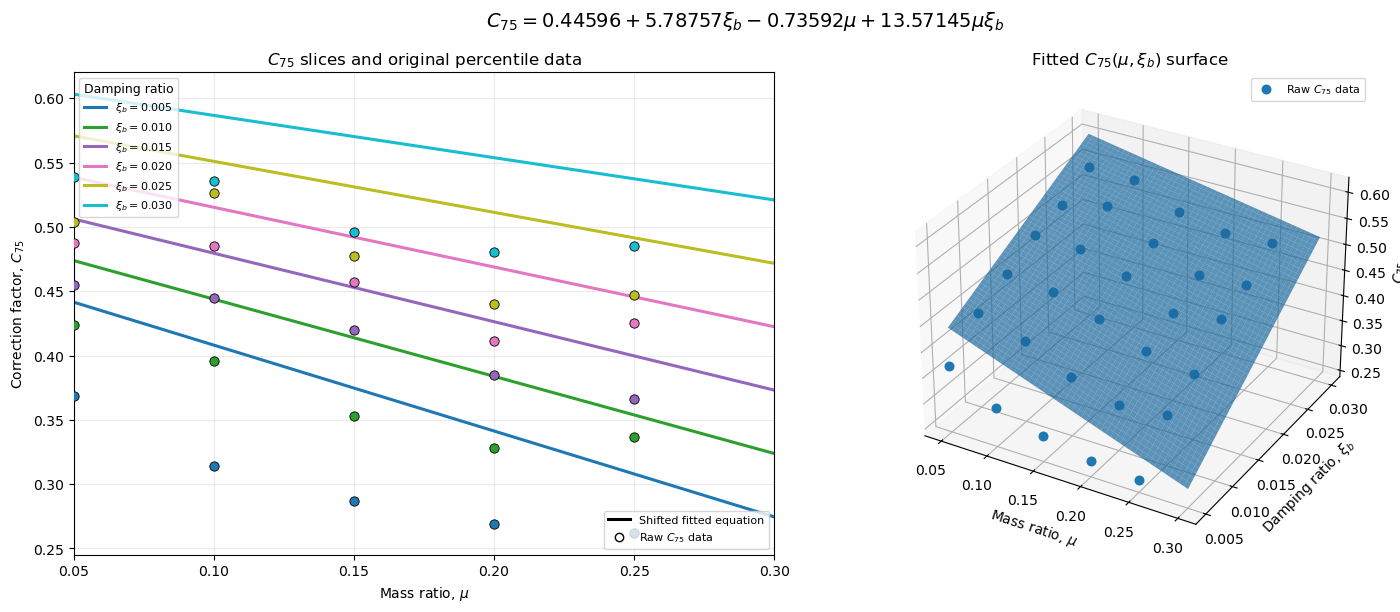



TERM CONTRIBUTION TO C75
Domain: 0.050 <= mu <= 0.300
        0.005 <= xi_b <= 0.030

Relative magnitude is based on mean absolute contribution of the three VARIABLE terms only.

     Term            Equation  Minimum contribution  Maximum contribution  Maximum absolute contribution  Mean contribution  Mean absolute contribution  Relative variable magnitude [%]
Intercept          0.44595556              0.445956              0.445956                       0.445956           0.445956                    0.445956                              NaN
     xi_b     5.78756835 xi_b              0.028938              0.173627                       0.173627           0.101282                    0.101282                        37.286685
       mu      -0.73592379 mu             -0.220777             -0.036796                       0.220777          -0.128787                    0.128787                        47.412240
mu * xi_b 13.57145033 mu xi_b              0.003393              0.122143      

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# C75 SELECTED EQUATION
# ============================================================
#
# Shifted fitted equation:
#
# C75 =
# 0.44595556
# + 5.78756835 xi_b
# - 0.73592379 mu
# + 13.57145033 mu xi_b
#
# ============================================================

B0 = 0.44595556
B_XI = 5.78756835
B_MU = -0.73592379
B_MU_XI = 13.57145033

SAFETY_SHIFT = 0.05


def C75(mu, xi):

    mu = np.asarray(mu, dtype=float)
    xi = np.asarray(xi, dtype=float)

    return (
        B0
        + B_XI * xi
        + B_MU * mu
        + B_MU_XI * mu * xi
    )


# ============================================================
# DOMAIN TO INVESTIGATE
# ============================================================

MU_MIN = 0.05
MU_MAX = 0.30

XI_MIN = 0.005
XI_MAX = 0.030

MU_SLICES = np.array(
    [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
)

XI_SLICES = np.array(
    [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
)


# ============================================================
# 1. GET ORIGINAL RAW C75 DATA POINTS
# ============================================================
#
# The previous percentile-selection code created:
#
#     all_raw_cx
#
# containing:
#
# percentile
# mu_key
# xi_key
# C_raw
# C_fit
# C_fit_shifted
#
# ============================================================

if "all_raw_cx" not in globals():

    raise NameError(
        "all_raw_cx was not found.\n"
        "Run the percentile-selection code first."
    )


raw75 = all_raw_cx[
    np.isclose(
        all_raw_cx["percentile"],
        75.0
    )
].copy()


required_columns = [
    "mu_key",
    "xi_key",
    "C_raw",
]

missing_columns = [
    col for col in required_columns
    if col not in raw75.columns
]

if missing_columns:

    raise KeyError(
        "raw C75 table is missing columns:\n"
        f"{missing_columns}"
    )


for col in required_columns:

    raw75[col] = pd.to_numeric(
        raw75[col],
        errors="coerce"
    )


raw75 = raw75.dropna(
    subset=required_columns
).copy()


# Only use requested domain

raw75 = raw75[
    (raw75["mu_key"] >= MU_MIN)
    &
    (raw75["mu_key"] <= MU_MAX)
    &
    (raw75["xi_key"] >= XI_MIN)
    &
    (raw75["xi_key"] <= XI_MAX)
].copy()


raw75 = raw75.sort_values(
    [
        "xi_key",
        "mu_key",
    ]
)


if raw75.empty:

    raise ValueError(
        "No raw C75 points were found in the selected domain."
    )


print("\n==============================================")
print("RAW C75 DATA")
print("==============================================")

print(
    raw75[
        [
            "mu_key",
            "xi_key",
            "C_raw",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 2. GRID FOR FITTED SURFACE
# ============================================================

mu_grid = np.linspace(
    MU_MIN,
    MU_MAX,
    250
)

xi_grid = np.linspace(
    XI_MIN,
    XI_MAX,
    250
)

MU, XI = np.meshgrid(
    mu_grid,
    xi_grid
)

C_SURFACE = C75(
    MU,
    XI
)


# ============================================================
# 3. COLOURS FOR DAMPING SLICES
# ============================================================

colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(XI_SLICES)
    )
)

xi_color = {
    xi: colors[i]
    for i, xi in enumerate(XI_SLICES)
}


# ============================================================
# FIGURE:
#
# LEFT:
# fitted slices + ORIGINAL RAW C75 DATA POINTS
#
# RIGHT:
# fitted 3D surface + ORIGINAL RAW DATA POINTS
# ============================================================

fig = plt.figure(
    figsize=(15, 6.2)
)


# ============================================================
# LEFT — SLICES
# ============================================================

ax1 = fig.add_subplot(
    1,
    2,
    1
)


for xi in XI_SLICES:

    # --------------------------------------------------------
    # Fitted equation
    # --------------------------------------------------------

    fitted_values = C75(
        mu_grid,
        np.full_like(
            mu_grid,
            xi
        )
    )


    ax1.plot(
        mu_grid,
        fitted_values,
        color=xi_color[xi],
        linewidth=2.2,
        label=rf"$\xi_b={xi:.3f}$"
    )


    # --------------------------------------------------------
    # Original raw C75 points
    # --------------------------------------------------------

    raw_slice = raw75[
        np.isclose(
            raw75["xi_key"],
            xi
        )
    ].copy()


    if not raw_slice.empty:

        ax1.scatter(
            raw_slice["mu_key"],
            raw_slice["C_raw"],
            color=xi_color[xi],
            marker="o",
            s=45,
            edgecolor="black",
            linewidth=0.6,
            zorder=5
        )


ax1.set_xlim(
    MU_MIN,
    MU_MAX
)

ax1.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax1.set_ylabel(
    r"Correction factor, $C_{75}$"
)

ax1.set_title(
    r"$C_{75}$ slices and original percentile data"
)

ax1.grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# Detailed legend
# ------------------------------------------------------------

damping_handles = [

    Line2D(
        [0], [0],
        color=xi_color[xi],
        linewidth=2.2,
        label=rf"$\xi_b={xi:.3f}$"
    )

    for xi in XI_SLICES

]


point_handle = Line2D(
    [0], [0],
    marker="o",
    color="black",
    linestyle="None",
    markerfacecolor="white",
    markersize=6,
    label=r"Raw $C_{75}$ data"
)


fit_handle = Line2D(
    [0], [0],
    color="black",
    linewidth=2.2,
    label="Shifted fitted equation"
)


legend1 = ax1.legend(
    handles=damping_handles,
    title="Damping ratio",
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

ax1.add_artist(
    legend1
)


ax1.legend(
    handles=[
        fit_handle,
        point_handle
    ],
    loc="lower right",
    fontsize=8
)


# ============================================================
# RIGHT — 3D SURFACE
# ============================================================

ax2 = fig.add_subplot(
    1,
    2,
    2,
    projection="3d"
)


ax2.plot_surface(
    MU,
    XI,
    C_SURFACE,
    alpha=0.70,
    linewidth=0,
    antialiased=True
)


# Raw data points

ax2.scatter(
    raw75["mu_key"],
    raw75["xi_key"],
    raw75["C_raw"],
    s=38,
    marker="o",
    depthshade=False,
    label=r"Raw $C_{75}$ data"
)


ax2.set_xlabel(
    r"Mass ratio, $\mu$"
)

ax2.set_ylabel(
    r"Damping ratio, $\xi_b$"
)

ax2.set_zlabel(
    r"$C_{75}$"
)

ax2.set_title(
    r"Fitted $C_{75}(\mu,\xi_b)$ surface"
)

ax2.legend(
    fontsize=8
)


fig.suptitle(
    r"$C_{75}=0.44596+5.78757\xi_b"
    r"-0.73592\mu+13.57145\mu\xi_b$",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 4. TERM CONTRIBUTION ANALYSIS
# ============================================================
#
# We are NOT plotting these.
#
# We calculate how much each term contributes throughout:
#
# 0.05 <= mu <= 0.30
# 0.005 <= xi <= 0.030
#
# ============================================================

TERM_INTERCEPT = np.full_like(
    MU,
    B0
)

TERM_XI = (
    B_XI
    *
    XI
)

TERM_MU = (
    B_MU
    *
    MU
)

TERM_INTERACTION = (
    B_MU_XI
    *
    MU
    *
    XI
)


# ============================================================
# 5. CONTRIBUTION TABLE
# ============================================================

term_names = [
    "Intercept",
    "xi_b",
    "mu",
    "mu * xi_b",
]

term_equations = [
    f"{B0:.8f}",
    f"{B_XI:.8f} xi_b",
    f"{B_MU:.8f} mu",
    f"{B_MU_XI:.8f} mu xi_b",
]

terms = [
    TERM_INTERCEPT,
    TERM_XI,
    TERM_MU,
    TERM_INTERACTION,
]


# ------------------------------------------------------------
# Relative magnitude is calculated only for VARIABLE terms.
#
# We do not include intercept in this percentage because
# intercept is the baseline of the equation.
# ------------------------------------------------------------

variable_mean_abs = np.array(
    [
        np.mean(np.abs(TERM_XI)),
        np.mean(np.abs(TERM_MU)),
        np.mean(np.abs(TERM_INTERACTION)),
    ]
)

variable_total_abs = (
    variable_mean_abs.sum()
)


relative_variable = {
    "Intercept": np.nan,

    "xi_b":
        100
        *
        variable_mean_abs[0]
        /
        variable_total_abs,

    "mu":
        100
        *
        variable_mean_abs[1]
        /
        variable_total_abs,

    "mu * xi_b":
        100
        *
        variable_mean_abs[2]
        /
        variable_total_abs,
}


contribution_rows = []


for name, equation, term in zip(
    term_names,
    term_equations,
    terms
):

    contribution_rows.append(

        {

            "Term":
                name,

            "Equation":
                equation,

            "Minimum contribution":
                np.min(term),

            "Maximum contribution":
                np.max(term),

            "Maximum absolute contribution":
                np.max(
                    np.abs(term)
                ),

            "Mean contribution":
                np.mean(term),

            "Mean absolute contribution":
                np.mean(
                    np.abs(term)
                ),

            "Relative variable magnitude [%]":
                relative_variable[name],

        }

    )


contribution_df = pd.DataFrame(
    contribution_rows
)


print(
    "\n\n============================================================"
)

print(
    "TERM CONTRIBUTION TO C75"
)

print(
    "============================================================"
)

print(
    f"Domain: {MU_MIN:.3f} <= mu <= {MU_MAX:.3f}"
)

print(
    f"        {XI_MIN:.3f} <= xi_b <= {XI_MAX:.3f}"
)

print(
    "\nRelative magnitude is based on mean absolute "
    "contribution of the three VARIABLE terms only.\n"
)


print(

    contribution_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


# ============================================================
# 6. NOW ACTUALLY TEST WHETHER TERMS CAN BE REMOVED
# ============================================================
#
# This is more useful than contribution magnitude alone.
#
# We refit these equations to ORIGINAL RAW C75 data:
#
# FULL:
#
#   1 + xi + mu + mu*xi
#
# REMOVE INTERACTION:
#
#   1 + xi + mu
#
# REMOVE mu:
#
#   1 + xi + mu*xi
#
# REMOVE xi:
#
#   1 + mu + mu*xi
#
# ============================================================


mu_data = raw75[
    "mu_key"
].to_numpy(
    dtype=float
)

xi_data = raw75[
    "xi_key"
].to_numpy(
    dtype=float
)

y_data = raw75[
    "C_raw"
].to_numpy(
    dtype=float
)


# ============================================================
# MODEL DEFINITIONS
# ============================================================

def build_model_matrix(
    mu,
    xi,
    terms_to_keep
):

    columns = []


    for term in terms_to_keep:


        if term == "1":

            columns.append(
                np.ones_like(mu)
            )


        elif term == "xi":

            columns.append(
                xi
            )


        elif term == "mu":

            columns.append(
                mu
            )


        elif term == "mu_xi":

            columns.append(
                mu * xi
            )


        else:

            raise ValueError(
                f"Unknown term: {term}"
            )


    return np.column_stack(
        columns
    )


candidate_models = {

    "Full":
        [
            "1",
            "xi",
            "mu",
            "mu_xi",
        ],

    "No interaction":
        [
            "1",
            "xi",
            "mu",
        ],

    "No mu main term":
        [
            "1",
            "xi",
            "mu_xi",
        ],

    "No xi main term":
        [
            "1",
            "mu",
            "mu_xi",
        ],

}


# ============================================================
# STATISTICS FUNCTIONS
# ============================================================

def calculate_r2(
    observed,
    predicted
):

    observed = np.asarray(
        observed,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )


    ss_res = np.sum(
        (
            observed
            -
            predicted
        ) ** 2
    )


    ss_tot = np.sum(
        (
            observed
            -
            np.mean(observed)
        ) ** 2
    )


    if ss_tot <= 0:

        return np.nan


    return (
        1.0
        -
        ss_res / ss_tot
    )


def calculate_rmse(
    observed,
    predicted
):

    return float(

        np.sqrt(

            np.mean(

                (
                    np.asarray(
                        observed
                    )

                    -

                    np.asarray(
                        predicted
                    )

                ) ** 2

            )

        )

    )


def calculate_mae(
    observed,
    predicted
):

    return float(

        np.mean(

            np.abs(

                np.asarray(
                    observed
                )

                -

                np.asarray(
                    predicted
                )

            )

        )

    )


# ============================================================
# 7. FIT FULL + REDUCED MODELS
# ============================================================

model_results = {}


for model_name, terms_to_keep in candidate_models.items():


    X = build_model_matrix(
        mu_data,
        xi_data,
        terms_to_keep
    )


    beta, *_ = np.linalg.lstsq(
        X,
        y_data,
        rcond=None
    )


    prediction = (
        X
        @
        beta
    )


    model_results[
        model_name
    ] = {

        "terms":
            terms_to_keep,

        "beta":
            beta,

        "prediction":
            prediction,

        "R2":
            calculate_r2(
                y_data,
                prediction
            ),

        "RMSE":
            calculate_rmse(
                y_data,
                prediction
            ),

        "MAE":
            calculate_mae(
                y_data,
                prediction
            ),

    }


# ============================================================
# 8. COMPARE REDUCED MODELS AGAINST FULL MODEL
# ============================================================

full_rmse = (
    model_results[
        "Full"
    ][
        "RMSE"
    ]
)

full_r2 = (
    model_results[
        "Full"
    ][
        "R2"
    ]
)


reduction_rows = []


for model_name, result in model_results.items():


    delta_rmse = (
        result["RMSE"]
        -
        full_rmse
    )


    if full_rmse > 0:

        rmse_increase_percent = (

            100
            *
            delta_rmse
            /
            full_rmse

        )

    else:

        rmse_increase_percent = np.nan


    reduction_rows.append(

        {

            "Model":
                model_name,

            "Terms retained":
                " + ".join(
                    result["terms"]
                ),

            "Number coefficients":
                len(
                    result["beta"]
                ),

            "R2":
                result["R2"],

            "Delta R2 vs full":
                result["R2"]
                -
                full_r2,

            "RMSE":
                result["RMSE"],

            "Delta RMSE vs full":
                delta_rmse,

            "RMSE increase [%]":
                rmse_increase_percent,

            "MAE":
                result["MAE"],

        }

    )


reduction_df = pd.DataFrame(
    reduction_rows
)


print(
    "\n\n============================================================"
)

print(
    "TERM-REMOVAL / MODEL-SIMPLIFICATION TEST"
)

print(
    "============================================================"
)

print(
    "\nThese models are REFITTED after removing each term.\n"
)


print(

    reduction_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


# ============================================================
# 9. PRINT EACH REFITTED EQUATION
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "REFITTED EQUATIONS BEFORE +0.05 SAFETY SHIFT"
)

print(
    "============================================================"
)


def format_equation(
    model_name,
    terms,
    beta
):

    pieces = []


    for term, coefficient in zip(
        terms,
        beta
    ):


        if term == "1":

            pieces.append(
                f"{coefficient:.8f}"
            )


        elif term == "xi":

            pieces.append(
                f"{coefficient:+.8f} xi_b"
            )


        elif term == "mu":

            pieces.append(
                f"{coefficient:+.8f} mu"
            )


        elif term == "mu_xi":

            pieces.append(
                f"{coefficient:+.8f} mu*xi_b"
            )


    return (
        " ".join(
            pieces
        )
    )


for model_name, result in model_results.items():


    print(
        f"\n{model_name}:"
    )


    print(

        "C75 = "

        +

        format_equation(
            model_name,
            result["terms"],
            result["beta"]
        )

    )


# ============================================================
# 10. ALSO PRINT EQUATIONS AFTER +0.05 SAFETY SHIFT
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "REFITTED EQUATIONS AFTER +0.05 INTERCEPT SAFETY SHIFT"
)

print(
    "============================================================"
)


for model_name, result in model_results.items():


    shifted_beta = (
        result["beta"]
        .copy()
    )


    # Intercept is always first
    shifted_beta[0] += SAFETY_SHIFT


    print(
        f"\n{model_name}:"
    )


    print(

        "C75_shifted = "

        +

        format_equation(
            model_name,
            result["terms"],
            shifted_beta
        )

    )


# ============================================================
# 11. SAVE TABLES
# ============================================================

contribution_df.to_csv(
    "C75_term_contribution_table.csv",
    index=False,
    encoding="utf-8-sig"
)


reduction_df.to_csv(
    "C75_term_removal_test.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSaved:"
)

print(
    "C75_term_contribution_table.csv"
)

print(
    "C75_term_removal_test.csv"
)


POPULATION WEIGHT GRID
Mass ratios: [0.01 0.05 0.1  0.15 0.2  0.25]
Damping ratios: [0.005 0.01  0.015 0.02  0.025 0.03 ]
Number of cells = 36
Weight sum = 1.000000000000

WEIGHTED PEAK BIAS
Current code                 peak = 1.513640 at 2.250 Hz, gap to 1 = 0.513640
New psi                      peak = 0.418475 at 2.050 Hz, gap to 1 = 0.581525
New psi + exact C75          peak = 0.999794 at 2.900 Hz, gap to 1 = 0.000206
New psi + rounded C75        peak = 0.970058 at 2.900 Hz, gap to 1 = 0.029942

EXACT vs ROUNDED C75
Maximum absolute difference in C = 0.025051
Maximum relative difference = 6.021%


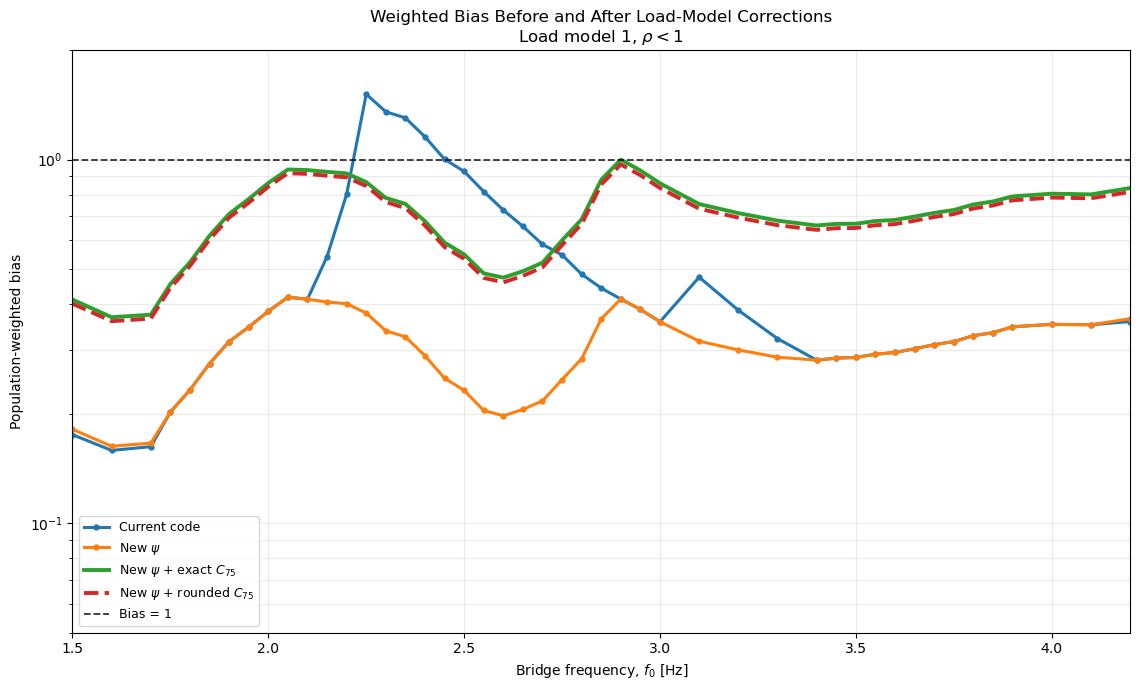

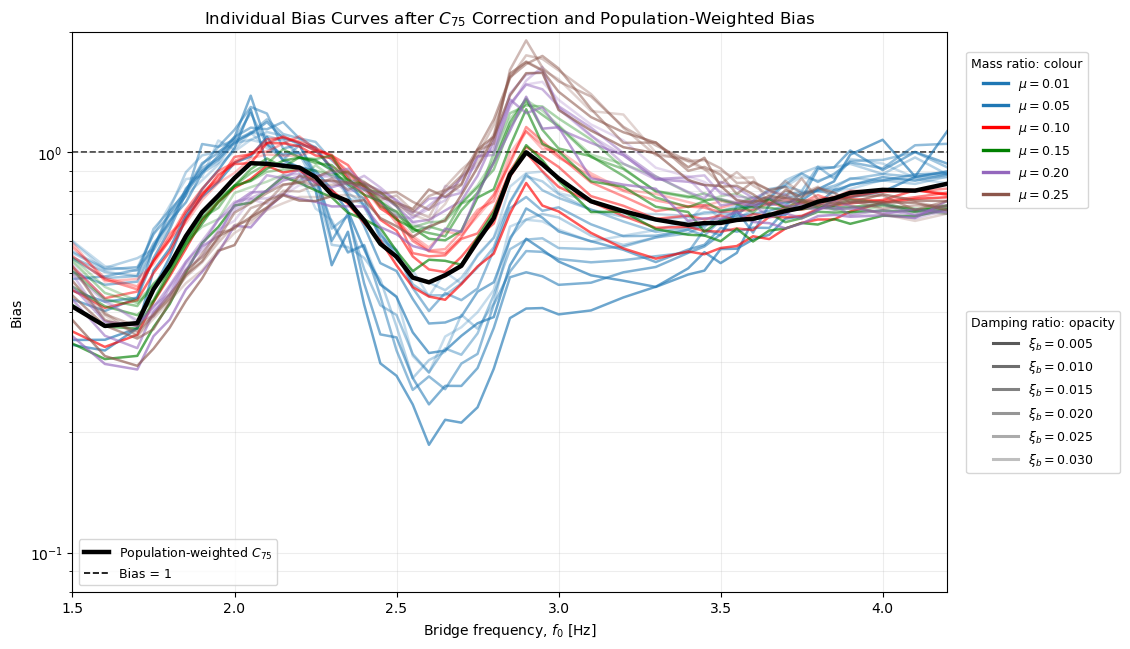


Saved:
C75_exact_vs_rounded_population_weighted_bias.csv
C75_exact_vs_rounded_individual_bias.csv


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# C75 EXACT AND ROUNDED EQUATIONS
# ============================================================
#
# IMPORTANT:
# These are the +0.05 shifted equations.
#
# Exact:
#
# C75 =
# 0.44595556
# + 5.78756835 xi_b
# - 0.73592379 mu
# + 13.57145033 mu xi_b
#
# Rounded:
#
# C75 =
# 0.45
# + 5.8 xi_b
# - 0.74 mu
# + 14 mu xi_b
#
# ============================================================


# ============================================================
# 1. SETTINGS
# ============================================================

MEASURE = "Peak absolute acceleration"

F_MIN = 1.50
F_MAX = 4.20

# Exact C75
B0_EXACT = 0.44595556
B_XI_EXACT = 5.78756835
B_MU_EXACT = -0.73592379
B_MUXI_EXACT = 13.57145033

# Rounded C75
B0_ROUND = 0.45
B_XI_ROUND = 6
B_MU_ROUND = -0.7
B_MUXI_ROUND = 14.0


# ============================================================
# 2. C FUNCTIONS
# ============================================================

def C75_exact(mu, xi):

    mu = np.asarray(mu, dtype=float)
    xi = np.asarray(xi, dtype=float)

    return (
        B0_EXACT
        + B_XI_EXACT * xi
        + B_MU_EXACT * mu
        + B_MUXI_EXACT * mu * xi
    )


def C75_rounded(mu, xi):

    mu = np.asarray(mu, dtype=float)
    xi = np.asarray(xi, dtype=float)

    return (
        B0_ROUND
        + B_XI_ROUND * xi
        + B_MU_ROUND * mu
        + B_MUXI_ROUND * mu * xi
    )


# ============================================================
# 3. CHECK REQUIRED DATA
# ============================================================

if "plot_all_df" not in globals():

    raise NameError(
        "plot_all_df was not found.\n"
        "Run the new-psi bias calculation first."
    )


if "weights_df" not in globals():

    raise NameError(
        "weights_df was not found.\n"
        "Run the population-weight calculation first."
    )


required_bias_columns = [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "newpsi_bias_mean",
]


missing = [
    col
    for col in required_bias_columns
    if col not in plot_all_df.columns
]


if missing:

    raise KeyError(
        "plot_all_df is missing:\n"
        f"{missing}"
    )


required_weight_columns = [
    "mu",
    "xi_b",
    "weight",
]


missing = [
    col
    for col in required_weight_columns
    if col not in weights_df.columns
]


if missing:

    raise KeyError(
        "weights_df is missing:\n"
        f"{missing}"
    )


# ============================================================
# 4. PREPARE BIAS DATA
# ============================================================

df = plot_all_df.copy()


for col in [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "code_bias_mean",
    "newpsi_bias_mean",
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df["measure"] = (
    df["measure"]
    .astype(str)
    .str.strip()
)


df = df[
    df["measure"].eq(MEASURE)
].copy()


df = df[
    (df["bridge_frequency"] >= F_MIN)
    &
    (df["bridge_frequency"] <= F_MAX)
].copy()


df = df.dropna(
    subset=[
        "bridge_frequency",
        "mass_ratio",
        "target_beamdamp",
        "code_bias_mean",
        "newpsi_bias_mean",
    ]
)


# ============================================================
# 5. PREPARE WEIGHTS
# ============================================================

W = weights_df[
    [
        "mu",
        "xi_b",
        "weight",
    ]
].copy()


for col in [
    "mu",
    "xi_b",
    "weight",
]:

    W[col] = pd.to_numeric(
        W[col],
        errors="coerce"
    )


W = W.dropna().copy()


print("\n==============================================")
print("POPULATION WEIGHT GRID")
print("==============================================")

print(
    "Mass ratios:",
    np.sort(W["mu"].unique())
)

print(
    "Damping ratios:",
    np.sort(W["xi_b"].unique())
)

print(
    f"Number of cells = {len(W)}"
)

print(
    f"Weight sum = {W['weight'].sum():.12f}"
)


# ============================================================
# 6. CREATE MATCHING KEYS
# ============================================================

df["mu_key"] = (
    df["mass_ratio"]
    .round(4)
)

df["xi_key"] = (
    df["target_beamdamp"]
    .round(4)
)

df["f_key"] = (
    df["bridge_frequency"]
    .round(6)
)


W["mu_key"] = (
    W["mu"]
    .round(4)
)

W["xi_key"] = (
    W["xi_b"]
    .round(4)
)


# ============================================================
# 7. KEEP ONLY POPULATION GRID
# ============================================================

df = df.merge(

    W[
        [
            "mu_key",
            "xi_key",
            "weight",
        ]
    ],

    on=[
        "mu_key",
        "xi_key",
    ],

    how="inner",

    validate="many_to_one",
)


if df.empty:

    raise ValueError(
        "No overlap between bias data and population weights."
    )


# ============================================================
# 8. CALCULATE EXACT AND ROUNDED C75
# ============================================================

mu = df[
    "mass_ratio"
].to_numpy(
    dtype=float
)

xi = df[
    "target_beamdamp"
].to_numpy(
    dtype=float
)


df["C75_exact"] = C75_exact(
    mu,
    xi
)


df["C75_rounded"] = C75_rounded(
    mu,
    xi
)


# ============================================================
# 9. RECALCULATE BIAS
#
# B_after_C =
# B_after_newpsi / C
# ============================================================

df["bias_C75_exact"] = (
    df["newpsi_bias_mean"]
    /
    df["C75_exact"]
)


df["bias_C75_rounded"] = (
    df["newpsi_bias_mean"]
    /
    df["C75_rounded"]
)


# ============================================================
# 10. CHECK COMPLETE POPULATION GRID
# ============================================================

coverage = (

    df

    .groupby(
        "f_key"
    )

    .agg(

        weight_sum=(
            "weight",
            "sum"
        ),

        n_cells=(
            "weight",
            "size"
        ),

    )

    .reset_index()

)


good_frequencies = coverage[

    np.isclose(
        coverage["weight_sum"],
        1.0,
        atol=1e-8
    )

    &

    (
        coverage["n_cells"]
        ==
        len(W)
    )

]["f_key"]


df = df[
    df["f_key"].isin(
        good_frequencies
    )
].copy()


if df.empty:

    raise ValueError(
        "No complete weighted frequency points remain."
    )


# ============================================================
# 11. WEIGHT ALL FOUR MODEL RESULTS
# ============================================================

df["w_current"] = (
    df["weight"]
    *
    df["code_bias_mean"]
)

df["w_newpsi"] = (
    df["weight"]
    *
    df["newpsi_bias_mean"]
)

df["w_C75_exact"] = (
    df["weight"]
    *
    df["bias_C75_exact"]
)

df["w_C75_rounded"] = (
    df["weight"]
    *
    df["bias_C75_rounded"]
)


# ============================================================
# 12. CREATE FOUR POPULATION-WEIGHTED LINES
# ============================================================

weighted_lines = (

    df

    .groupby(
        "f_key",
        as_index=False
    )

    .agg(

        bridge_frequency=(
            "bridge_frequency",
            "mean"
        ),

        B_current=(
            "w_current",
            "sum"
        ),

        B_newpsi=(
            "w_newpsi",
            "sum"
        ),

        B_C75_exact=(
            "w_C75_exact",
            "sum"
        ),

        B_C75_rounded=(
            "w_C75_rounded",
            "sum"
        ),

        weight_sum=(
            "weight",
            "sum"
        ),

    )

    .sort_values(
        "bridge_frequency"
    )

)


# ============================================================
# 13. PRINT PEAK RESULTS
# ============================================================

print("\n==============================================")
print("WEIGHTED PEAK BIAS")
print("==============================================")


for column, label in [

    (
        "B_current",
        "Current code"
    ),

    (
        "B_newpsi",
        "New psi"
    ),

    (
        "B_C75_exact",
        "New psi + exact C75"
    ),

    (
        "B_C75_rounded",
        "New psi + rounded C75"
    ),

]:

    idx = (
        weighted_lines[column]
        .idxmax()
    )

    peak = float(
        weighted_lines.loc[
            idx,
            column
        ]
    )

    f_peak = float(
        weighted_lines.loc[
            idx,
            "bridge_frequency"
        ]
    )

    print(
        f"{label:28s} "
        f"peak = {peak:.6f} "
        f"at {f_peak:.3f} Hz, "
        f"gap to 1 = {abs(1-peak):.6f}"
    )


# ============================================================
# 14. EXACT vs ROUNDED C DIFFERENCE OVER DESIGN DOMAIN
# ============================================================

mu_check = np.linspace(
    0.05,
    0.30,
    300
)

xi_check = np.linspace(
    0.005,
    0.030,
    300
)

MU_CHECK, XI_CHECK = np.meshgrid(
    mu_check,
    xi_check
)


C_exact_check = C75_exact(
    MU_CHECK,
    XI_CHECK
)

C_round_check = C75_rounded(
    MU_CHECK,
    XI_CHECK
)


absolute_difference = np.abs(
    C_round_check
    -
    C_exact_check
)


relative_difference = (

    100
    *
    absolute_difference
    /
    np.abs(
        C_exact_check
    )

)


print("\n==============================================")
print("EXACT vs ROUNDED C75")
print("==============================================")

print(
    "Maximum absolute difference in C = "
    f"{absolute_difference.max():.6f}"
)

print(
    "Maximum relative difference = "
    f"{relative_difference.max():.3f}%"
)


# ============================================================
# ============================================================
#
# FIGURE 1
#
# CURRENT CODE
# vs
# NEW psi
# vs
# NEW psi + EXACT C75
# vs
# NEW psi + ROUNDED C75
#
# ============================================================
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 7)
)


# Current code
ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_current"
    ],

    marker="o",
    markersize=3.5,
    linewidth=2.2,
    label="Current code"
)


# New psi
ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_newpsi"
    ],

    marker="o",
    markersize=3.5,
    linewidth=2.2,
    label=r"New $\psi$"
)


# Exact C75
ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_C75_exact"
    ],

    linewidth=2.8,
    label=r"New $\psi$ + exact $C_{75}$"
)


# Rounded C75
ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_C75_rounded"
    ],

    linewidth=2.8,
    linestyle="--",
    label=r"New $\psi$ + rounded $C_{75}$"
)


# Bias = 1
ax.axhline(

    1.0,

    color="black",
    linestyle="--",
    linewidth=1.3,
    alpha=0.8,
    label="Bias = 1"
)


ax.set_xlim(
    F_MIN,
    F_MAX
)

ax.set_yscale(
    "log"
)

ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(

    "Weighted Bias Before and After Load-Model Corrections\n"
    r"Load model 1, $\rho < 1$"

)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(
    loc="lower left",
    fontsize=9
)


plt.tight_layout()

plt.show()


# ============================================================
# ============================================================
#
# FIGURE 2
#
# ALL INDIVIDUAL BIAS CURVES AFTER EXACT C75
#
# BLACK =
# POPULATION-WEIGHTED C75 LINE
#
# ============================================================
# ============================================================


# Actual grid values from weights

MU_VALUES = np.sort(
    W["mu"].unique()
)

XI_VALUES = np.sort(
    W["xi_b"].unique()
)


# ============================================================
# MASS RATIO COLOURS
# ============================================================

preferred_colors = {

    0.05: "tab:blue",

    0.10: "red",

    0.15: "green",

    0.20: "tab:purple",

    0.25: "tab:brown",

    0.30: "pink",

}


# fallback if another mass ratio appears

fallback = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(MU_VALUES)
    )
)


mu_colors = {}


for i, mu_value in enumerate(
    MU_VALUES
):

    mu_colors[
        mu_value
    ] = preferred_colors.get(
        round(
            float(mu_value),
            2
        ),
        fallback[i]
    )


# ============================================================
# DAMPING OPACITY
# ============================================================

# More damping -> more transparent

alpha_values = np.linspace(
    0.65,
    0.25,
    len(XI_VALUES)
)


xi_alpha = {

    xi_value:
        alpha_values[i]

    for i, xi_value in enumerate(
        XI_VALUES
    )

}


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12.5, 7)
)


# leave room for detailed legends

fig.subplots_adjust(
    left=0.08,
    right=0.78,
    bottom=0.12,
    top=0.92
)


# ============================================================
# INDIVIDUAL EXACT C75 BIAS CURVES
# ============================================================

for mu_value in MU_VALUES:

    for xi_value in XI_VALUES:


        sub = df[

            np.isclose(
                df["mass_ratio"],
                mu_value
            )

            &

            np.isclose(
                df["target_beamdamp"],
                xi_value
            )

        ].copy()


        if sub.empty:

            continue


        sub = sub.sort_values(
            "bridge_frequency"
        )


        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_C75_exact"
            ],

            color=
                mu_colors[
                    mu_value
                ],

            alpha=
                xi_alpha[
                    xi_value
                ],

            linewidth=1.8,

            zorder=2

        )


# ============================================================
# BLACK POPULATION-WEIGHTED C75 LINE
# ============================================================

ax.plot(

    weighted_lines[
        "bridge_frequency"
    ],

    weighted_lines[
        "B_C75_exact"
    ],

    color="black",

    linewidth=3.2,

    zorder=10,

    label=r"Population-weighted $C_{75}$ line"

)


# ============================================================
# BIAS = 1
# ============================================================

ax.axhline(

    1.0,

    color="black",

    linestyle="--",

    linewidth=1.2,

    alpha=0.8,

    zorder=1

)


# ============================================================
# AXES
# ============================================================

ax.set_xlim(
    F_MIN,
    F_MAX
)

ax.set_yscale(
    "log"
)

ax.set_ylim(
    0.08,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Bias"
)


ax.set_title(

    r"Individual Bias Curves after $C_{75}$ Correction "
    "and Population-Weighted Bias"

)


ax.grid(
    True,
    which="both",
    alpha=0.22
)


# ============================================================
# MASS-RATIO LEGEND
# ============================================================

mu_handles = [

    Line2D(

        [0],
        [0],

        color=
            mu_colors[
                mu_value
            ],

        linewidth=2.4,

        label=
            rf"$\mu={mu_value:.2f}$"

    )

    for mu_value in MU_VALUES

]


fig.legend(

    handles=mu_handles,

    title="Mass ratio: colour",

    loc="upper left",

    bbox_to_anchor=(
        0.79,
        0.90
    ),

    frameon=True,

    fontsize=9,

    title_fontsize=9

)


# ============================================================
# DAMPING LEGEND
# ============================================================

xi_handles = [

    Line2D(

        [0],
        [0],

        color="black",

        alpha=
            xi_alpha[
                xi_value
            ],

        linewidth=2.2,

        label=
            rf"$\xi_b={xi_value:.3f}$"

    )

    for xi_value in XI_VALUES

]


fig.legend(

    handles=xi_handles,

    title="Damping ratio: opacity",

    loc="upper left",

    bbox_to_anchor=(
        0.79,
        0.53
    ),

    frameon=True,

    fontsize=9,

    title_fontsize=9

)


# ============================================================
# MAIN LEGEND
# ============================================================

main_handles = [

    Line2D(

        [0],
        [0],

        color="black",

        linewidth=3.2,

        label=
            r"Population-weighted $C_{75}$"

    ),

    Line2D(

        [0],
        [0],

        color="black",

        linestyle="--",

        linewidth=1.2,

        label="Bias = 1"

    ),

]


ax.legend(

    handles=main_handles,

    loc="lower left",

    fontsize=9,

    frameon=True

)


plt.show()


# ============================================================
# 15. SAVE DATA
# ============================================================

weighted_lines.to_csv(

    "C75_exact_vs_rounded_population_weighted_bias.csv",

    index=False,

    encoding="utf-8-sig"

)


df.to_csv(

    "C75_exact_vs_rounded_individual_bias.csv",

    index=False,

    encoding="utf-8-sig"

)


print("\nSaved:")

print(
    "C75_exact_vs_rounded_population_weighted_bias.csv"
)

print(
    "C75_exact_vs_rounded_individual_bias.csv"
)

In [41]:
import numpy as np
import pandas as pd

# ============================================================
# SELECTED C75 EQUATION
# ============================================================
#
# C75 =
# 0.44595556
# + 5.78756835 xi_b
# - 0.73592379 mu
# + 13.57145033 mu xi_b
#
# ============================================================

b0 = 0.44595556
b_xi = 5.78756835
b_mu = -0.73592379
b_muxi = 13.57145033


# ============================================================
# DOMAIN
# ============================================================

MU_MIN = 0.05
MU_MAX = 0.30

XI_MIN = 0.005
XI_MAX = 0.030


# ============================================================
# CREATE FINE GRID OVER DOMAIN
# ============================================================

mu = np.linspace(
    MU_MIN,
    MU_MAX,
    1000
)

xi = np.linspace(
    XI_MIN,
    XI_MAX,
    1000
)

MU, XI = np.meshgrid(
    mu,
    xi
)


# ============================================================
# CALCULATE CONTRIBUTION OF EACH TERM
# ============================================================

term_intercept = np.full_like(
    MU,
    b0
)

term_xi = (
    b_xi
    *
    XI
)

term_mu = (
    b_mu
    *
    MU
)

term_muxi = (
    b_muxi
    *
    MU
    *
    XI
)


# ============================================================
# FINAL C75
# ============================================================

C75 = (
    term_intercept
    +
    term_xi
    +
    term_mu
    +
    term_muxi
)


# ============================================================
# FUNCTION TO FORMAT RANGE
# ============================================================

def range_string(values):

    minimum = np.min(values)
    maximum = np.max(values)

    # Constant term
    if np.isclose(
        minimum,
        maximum
    ):

        return f"{minimum:.6f}"

    return (
        f"{minimum:.6f} to "
        f"{maximum:.6f}"
    )


# ============================================================
# BUILD TERM CONTRIBUTION TABLE
# ============================================================

rows = [

    {
        "Expression":
            f"{b0:.6f}",

        "Range over domain":
            range_string(
                term_intercept
            ),

        "Min":
            np.min(
                term_intercept
            ),

        "Max":
            np.max(
                term_intercept
            ),

        "Max absolute contribution":
            np.max(
                np.abs(
                    term_intercept
                )
            ),
    },

    {
        "Expression":
            f"{b_xi:.6f} xi_b",

        "Range over domain":
            range_string(
                term_xi
            ),

        "Min":
            np.min(
                term_xi
            ),

        "Max":
            np.max(
                term_xi
            ),

        "Max absolute contribution":
            np.max(
                np.abs(
                    term_xi
                )
            ),
    },

    {
        "Expression":
            f"{b_mu:.6f} mu",

        "Range over domain":
            range_string(
                term_mu
            ),

        "Min":
            np.min(
                term_mu
            ),

        "Max":
            np.max(
                term_mu
            ),

        "Max absolute contribution":
            np.max(
                np.abs(
                    term_mu
                )
            ),
    },

    {
        "Expression":
            f"{b_muxi:.6f} mu xi_b",

        "Range over domain":
            range_string(
                term_muxi
            ),

        "Min":
            np.min(
                term_muxi
            ),

        "Max":
            np.max(
                term_muxi
            ),

        "Max absolute contribution":
            np.max(
                np.abs(
                    term_muxi
                )
            ),
    },

]


term_range_df = pd.DataFrame(
    rows
)


# ============================================================
# PRINT EQUATION
# ============================================================

print(
    "\n============================================================"
)

print(
    "C75 EQUATION"
)

print(
    "============================================================"
)

print(
    f"\nC75 = "
    f"{b0:.8f} "
    f"{b_xi:+.8f} xi_b "
    f"{b_mu:+.8f} mu "
    f"{b_muxi:+.8f} mu xi_b"
)


# ============================================================
# PRINT DOMAIN
# ============================================================

print(
    "\nDomain:"
)

print(
    f"{MU_MIN:.3f} <= mu <= {MU_MAX:.3f}"
)

print(
    f"{XI_MIN:.3f} <= xi_b <= {XI_MAX:.3f}"
)


# ============================================================
# PRINT TABLE
# ============================================================

print(
    "\n============================================================"
)

print(
    "TERM CONTRIBUTION RANGES"
)

print(
    "============================================================\n"
)


print(

    term_range_df[
        [
            "Expression",
            "Range over domain",
            "Max absolute contribution",
        ]
    ].to_string(
        index=False,
        float_format=
            lambda x:
                f"{x:.6f}"
    )

)


# ============================================================
# FINAL C75 RANGE
# ============================================================

print(
    "\n============================================================"
)

print(
    "FINAL C75 RANGE"
)

print(
    "============================================================"
)

print(
    f"C75 minimum = "
    f"{np.min(C75):.6f}"
)

print(
    f"C75 maximum = "
    f"{np.max(C75):.6f}"
)


# ============================================================
# OPTIONAL:
# RANK VARIABLE TERMS BY MAXIMUM ABSOLUTE CONTRIBUTION
# ============================================================

ranking_df = (

    term_range_df[
        term_range_df[
            "Expression"
        ]
        !=
        f"{b0:.6f}"
    ]

    .sort_values(
        "Max absolute contribution",
        ascending=True
    )

    .reset_index(
        drop=True
    )

)


print(
    "\n============================================================"
)

print(
    "VARIABLE TERMS RANKED FROM SMALLEST TO LARGEST"
)

print(
    "============================================================\n"
)


print(

    ranking_df[
        [
            "Expression",
            "Range over domain",
            "Max absolute contribution",
        ]
    ].to_string(
        index=False,
        float_format=
            lambda x:
                f"{x:.6f}"
    )

)


# ============================================================
# SAVE
# ============================================================

term_range_df.to_csv(
    "C75_term_range_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nSaved: C75_term_range_table.csv"
)


C75 EQUATION

C75 = 0.44595556 +5.78756835 xi_b -0.73592379 mu +13.57145033 mu xi_b

Domain:
0.050 <= mu <= 0.300
0.005 <= xi_b <= 0.030

TERM CONTRIBUTION RANGES

       Expression      Range over domain  Max absolute contribution
         0.445956               0.445956                   0.445956
    5.787568 xi_b   0.028938 to 0.173627                   0.173627
     -0.735924 mu -0.220777 to -0.036796                   0.220777
13.571450 mu xi_b   0.003393 to 0.122143                   0.122143

FINAL C75 RANGE
C75 minimum = 0.274473
C75 maximum = 0.603144

VARIABLE TERMS RANKED FROM SMALLEST TO LARGEST

       Expression      Range over domain  Max absolute contribution
13.571450 mu xi_b   0.003393 to 0.122143                   0.122143
    5.787568 xi_b   0.028938 to 0.173627                   0.173627
     -0.735924 mu -0.220777 to -0.036796                   0.220777

Saved: C75_term_range_table.csv


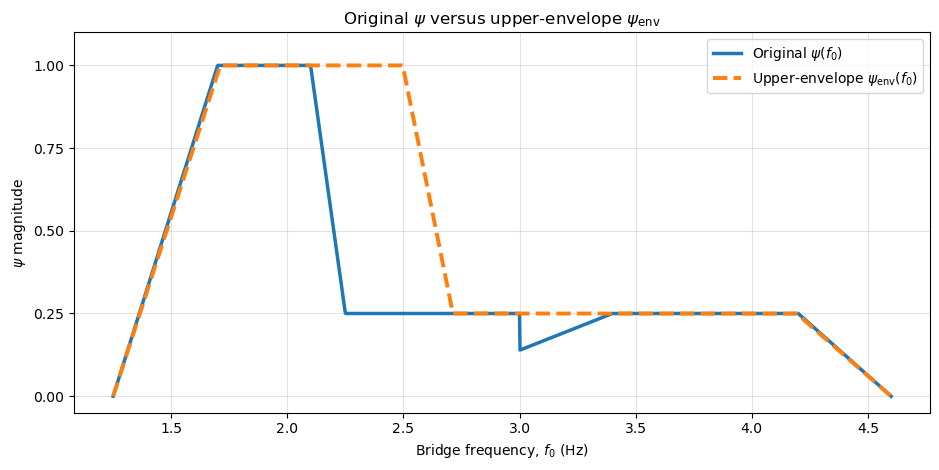

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

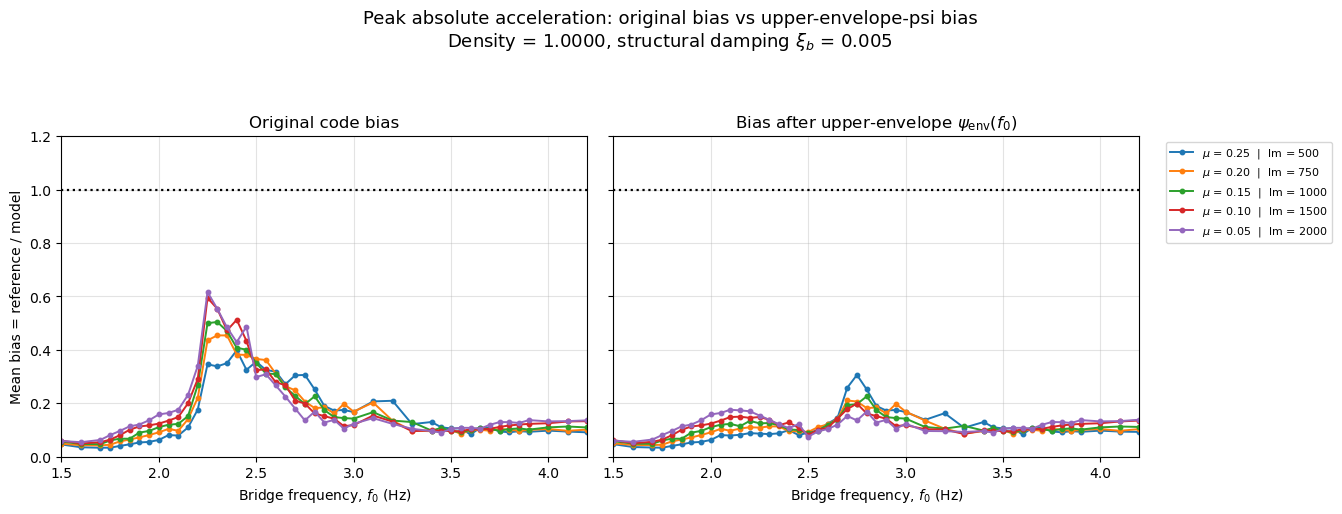

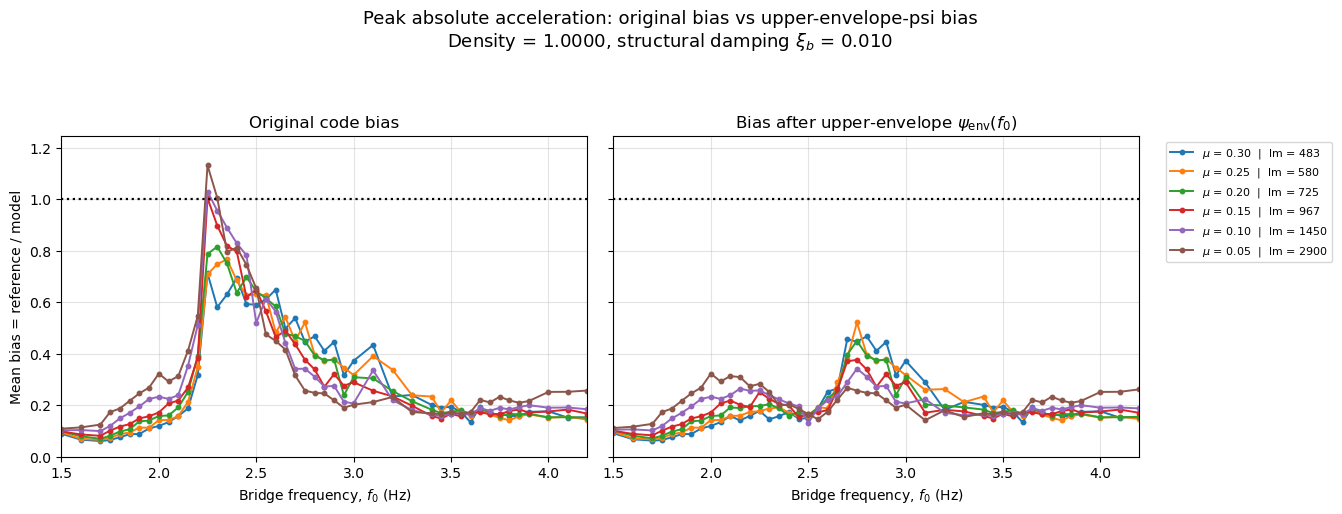

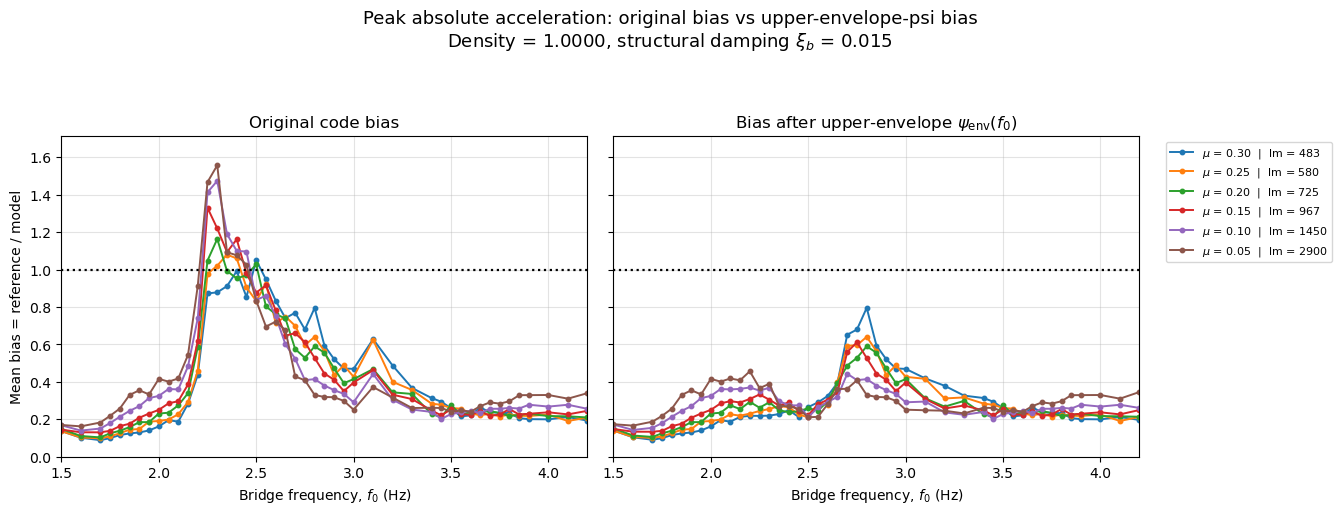

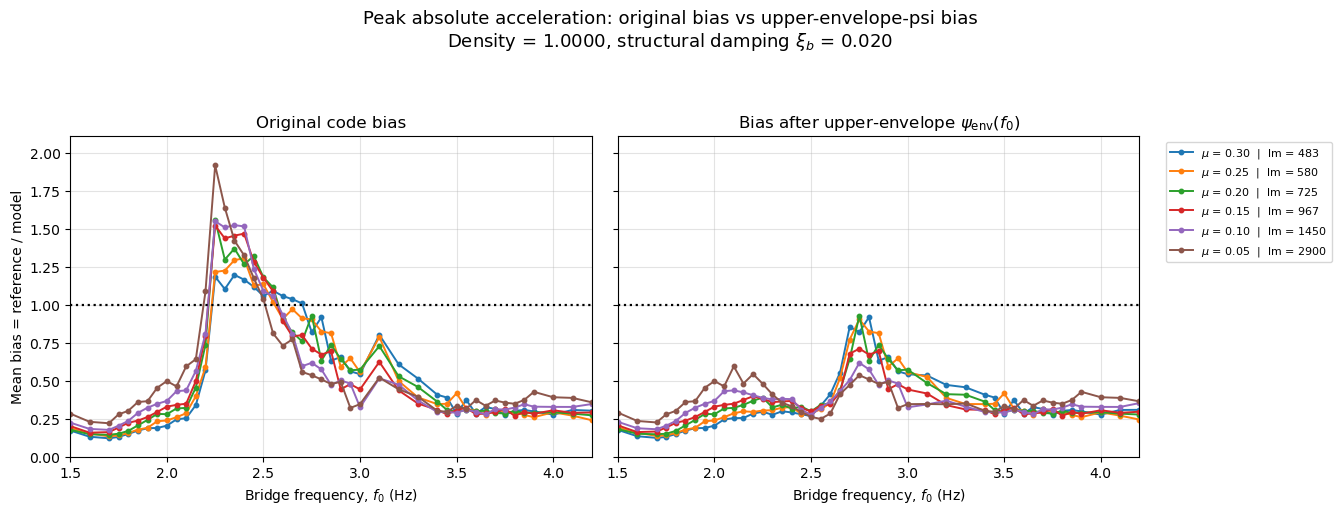

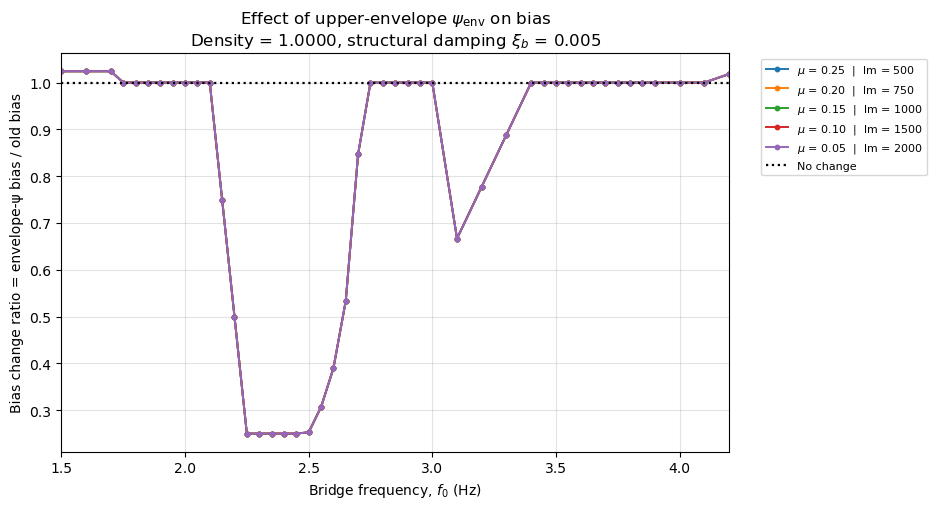

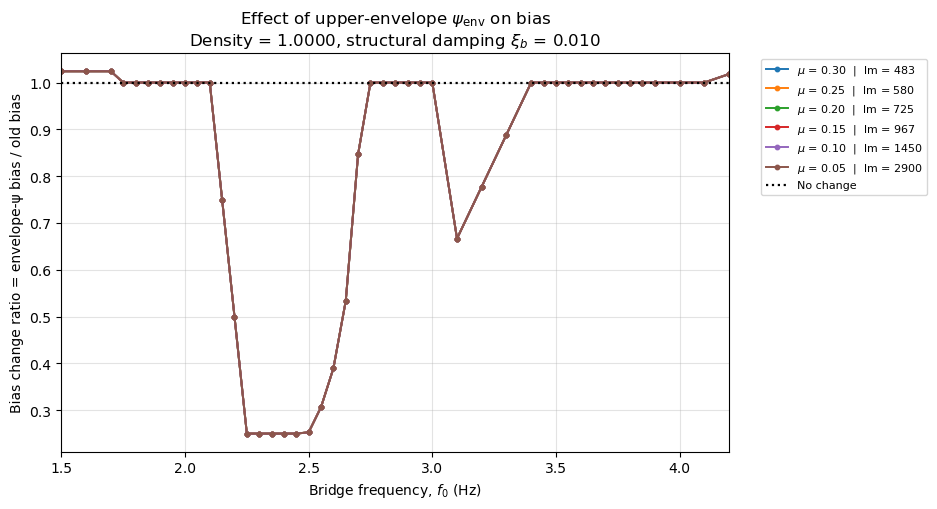

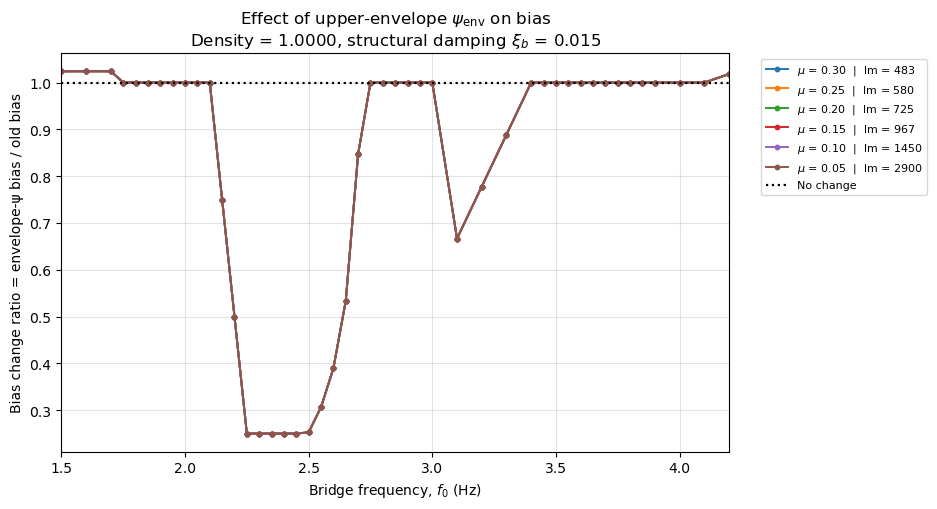

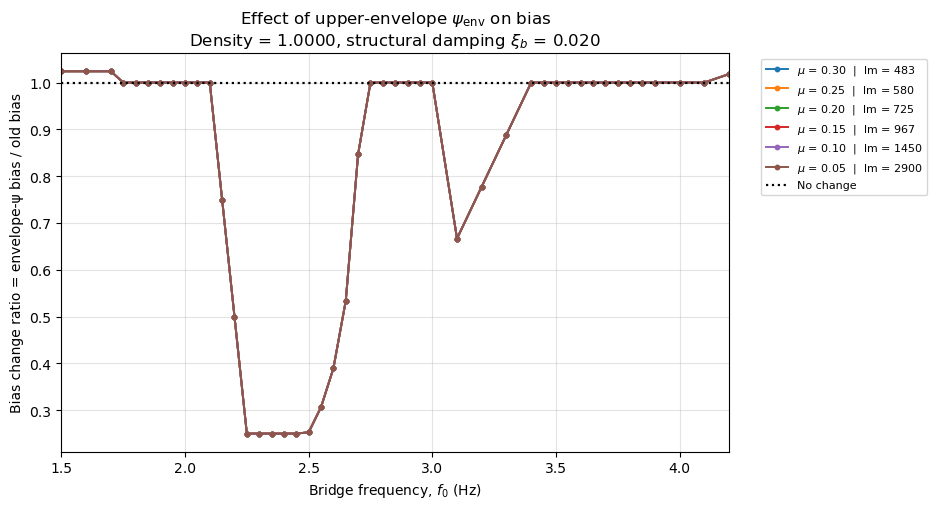


Summary table:
 damping_key  linear_mass_key  mass_ratio  old_bias_mean  env_bias_mean  old_bias_max  env_bias_max  mean_bias_change_ratio
       0.005              500        0.25       0.160823       0.108266      0.398131      0.306204                0.831589
       0.005              750        0.20       0.167101       0.108297      0.454150      0.210449                0.831589
       0.005             1000        0.15       0.173092       0.112188      0.504448      0.226072                0.831589
       0.005             1500        0.10       0.181362       0.116096      0.594561      0.198859                0.831589
       0.005             2000        0.05       0.184129       0.119601      0.616419      0.175922                0.831589
       0.010              483        0.30       0.291698       0.195941      0.712788      0.467535                0.831589
       0.010              580        0.25       0.296683       0.196153      0.766111      0.521570                0

In [45]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted as original bias / correction factor
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,
    500:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# UPPER-ENVELOPE PSI FUNCTION
#
# Your suggested envelope:
#
# For 1.2500 <= f0 <= 1.7109: psi_env =  2.169878*f0 - 2.712347
# For 1.7109 <= f0 <= 2.4968: psi_env =  1.000000
# For 2.4968 <= f0 <= 2.7130: psi_env = -3.469281*f0 + 9.662183
# For 2.7130 <= f0 <= 4.1928: psi_env =  0.250000
# For 4.1928 <= f0 <= 4.6000: psi_env = -0.613906*f0 + 2.823967
# ==================================================

def psi_upper_envelope(f):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Breakpoints
    f_start = 1.2500
    a = 1.7109
    b = 2.4968
    c = 2.7130
    d = 4.1928
    f_end = 4.6000

    # Segment 1: ramp from 0 to 1
    m = (f >= f_start) & (f < a)
    psi[m] = 2.169878 * f[m] - 2.712347

    # Segment 2: plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = 1.0

    # Segment 3: ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = -3.469281 * f[m] + 9.662183

    # Segment 4: plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = 0.25

    # Segment 5: ramp from 0.25 to 0
    m = (f >= d) & (f <= f_end)
    psi[m] = -0.613906 * f[m] + 2.823967

    # Outside range: keep zero
    psi = np.clip(psi, 0.0, 1.0)

    return psi


# ==================================================
# QUICK CHECK: PLOT OLD PSI VS UPPER-ENVELOPE PSI
# ==================================================

f_check = np.linspace(1.25, 4.60, 1500)

plt.figure(figsize=(9.5, 4.8))

plt.plot(
    f_check,
    psi_original(f_check),
    linewidth=2.5,
    label=r"Original $\psi(f_0)$"
)

plt.plot(
    f_check,
    psi_upper_envelope(f_check),
    "--",
    linewidth=2.8,
    label=r"Upper-envelope $\psi_{\mathrm{env}}(f_0)$"
)

plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")
plt.title(r"Original $\psi$ versus upper-envelope $\psi_{\mathrm{env}}$")
plt.ylim(-0.05, 1.10)
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Stable mass-ratio label from lm
raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE BIAS IF UPPER-ENVELOPE PSI IS USED
# ==================================================

compare_df["psi_old"] = psi_original(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

compare_df["psi_env"] = psi_upper_envelope(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

psi_old_safe = np.maximum(
    compare_df["psi_old"].to_numpy(dtype=float),
    PSI_EPS
)

psi_env_safe = np.maximum(
    compare_df["psi_env"].to_numpy(dtype=float),
    PSI_EPS
)

# Model_new = Model_old * psi_env / psi_old
# Bias = Reference / Model
# Therefore:
# Bias_new = Bias_old * psi_old / psi_env

compare_df["env_bias"] = (
    compare_df["old_bias"] * psi_old_safe / psi_env_safe
)

compare_df["bias_ratio_env_over_old"] = (
    compare_df["env_bias"] / compare_df["old_bias"]
)

compare_df["psi_scale_env_over_old"] = (
    psi_env_safe / psi_old_safe
)

compare_df.to_csv(
    "old_vs_upper_envelope_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_upper_envelope_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        damp_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# env_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_env_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = envelope-ψ bias / old bias")

    plt.title(
        r"Effect of upper-envelope $\psi_{\mathrm{env}}$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


# ==================================================
# OPTIONAL: SUMMARY TABLE
# ==================================================

summary_df = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"], as_index=False)
    .agg(
        old_bias_mean=("old_bias", "mean"),
        env_bias_mean=("env_bias", "mean"),
        old_bias_max=("old_bias", "max"),
        env_bias_max=("env_bias", "max"),
        mean_bias_change_ratio=("bias_ratio_env_over_old", "mean"),
    )
    .sort_values(["damping_key", "mass_ratio"], ascending=[True, False])
)

print("\nSummary table:")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "summary_upper_envelope_psi_bias_effect.csv",
    index=False
)

print("\nSaved: summary_upper_envelope_psi_bias_effect.csv")


SECOND LOAD MODEL — ORIGINAL vs ROUNDED C

Original equation:
C = 0.097 + 20 xi_b + 61.4 mu xi_b

Rounded equation:
C = 0.10 + 20 xi_b + 60 mu xi_b

C_original range: 0.2653 to 0.9184
C_rounded range: 0.3150 to 0.9600

Maximum absolute difference in C: 0.049650
Maximum relative difference in C: 18.711%
Maximum absolute difference in resulting bias: 0.120576


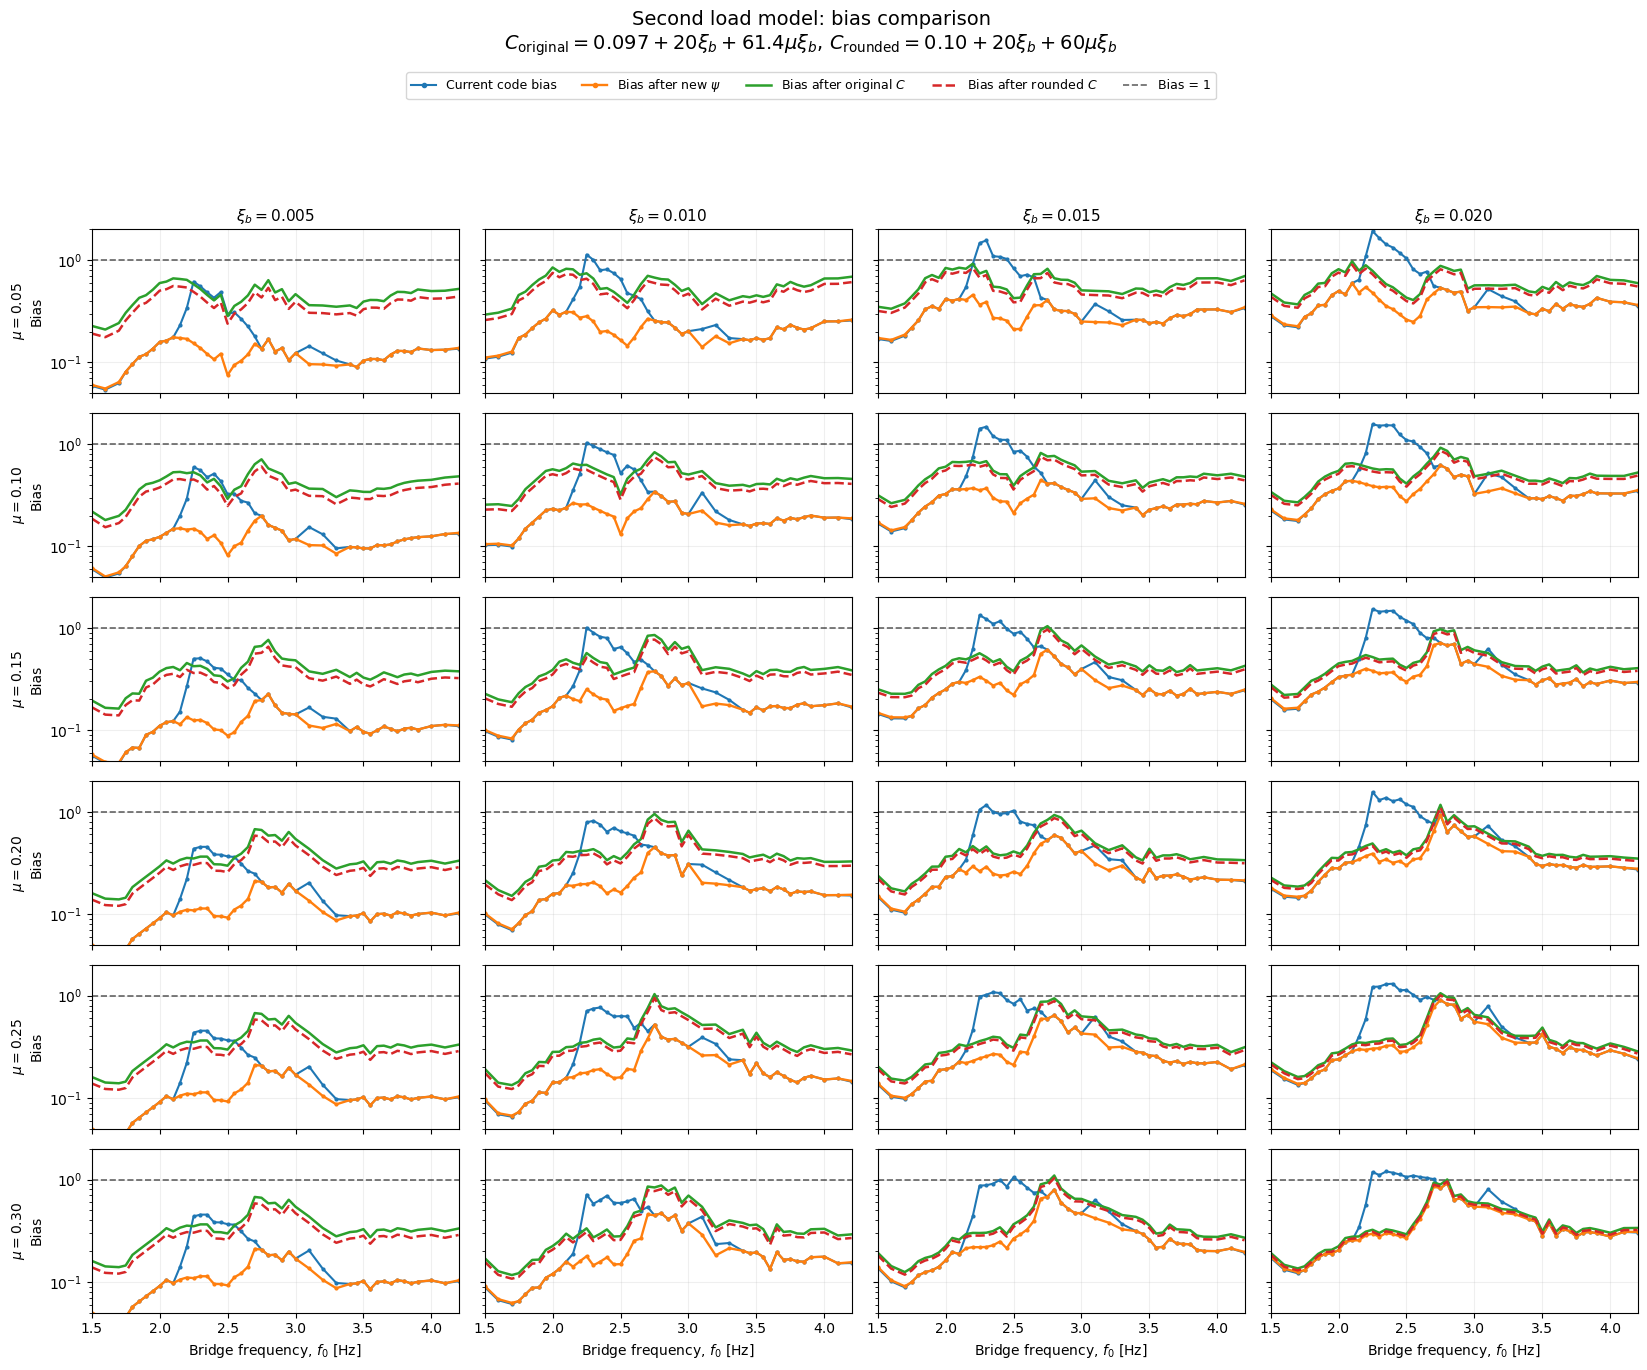

In [44]:
# ============================================================
# SECOND LOAD MODEL
#
# COMPARE:
#
# 1. ORIGINAL CODE BIAS
# 2. BIAS AFTER NEW psi
# 3. BIAS AFTER ORIGINAL C EQUATION
# 4. BIAS AFTER ROUNDED C EQUATION
#
# Original:
#
# C = 0.097 + 20 xi_b + 61.4 mu xi_b
#
# Rounded:
#
# C = 0.10 + 20 xi_b + 60 mu xi_b
#
# B_final = B_after_psi / C
#
# SPECIAL PLOT RULE:
#
# Panel labelled:
#
#     mu = 0.25, xi_b = 0.005
#
# will deliberately repeat the curves from:
#
#     mu = 0.30, xi_b = 0.005
#
# Plot range:
#
#     1.50 <= f <= 4.20 Hz
#
# Damping ratios shown:
#
#     0.005, 0.010, 0.015, 0.020
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# ============================================================
# 1. COPY CURRENT SECOND-LOAD-MODEL DATA
# ============================================================

if "compare_df" not in globals():

    raise NameError(
        "compare_df does not exist.\n"
        "Run the first second-load-model code first."
    )


comparison_df = compare_df.copy()


# ============================================================
# 2. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [

    "bridge_frequency",

    "damping_key",

    "mass_ratio",

    "old_bias",

    "env_bias",
]


missing_columns = [

    column

    for column in required_columns

    if column not in comparison_df.columns
]


if missing_columns:

    raise KeyError(
        "Missing required columns in compare_df:\n"
        f"{missing_columns}"
    )


# ============================================================
# 3. CREATE STANDARD DAMPING COLUMN
# ============================================================

comparison_df[
    "target_beamdamp"
] = pd.to_numeric(

    comparison_df[
        "damping_key"
    ],

    errors="coerce"
)


# ============================================================
# 4. NUMERICAL ARRAYS
# ============================================================

mu = comparison_df[
    "mass_ratio"
].to_numpy(
    dtype=float
)


xi = comparison_df[
    "target_beamdamp"
].to_numpy(
    dtype=float
)


# ============================================================
# 5. ORIGINAL SECOND-LOAD-MODEL C
#
# C = 0.097 + 20 xi_b + 61.4 mu xi_b
# ============================================================

comparison_df[
    "C_original"
] = (

    0.15

    +

    20.0 * xi

    +

    61.4 * mu * xi
)


# ============================================================
# 6. ROUNDED SECOND-LOAD-MODEL C
#
# C = 0.10 + 20 xi_b + 60 mu xi_b
# ============================================================

comparison_df[
    "C_rounded"
] = (

    0.20

    +

    20.0 * xi

    +

    60.0 * mu * xi
)


# ============================================================
# 7. APPLY C TO BIAS
#
# env_bias = bias after new psi
#
# B_final = B_after_psi / C
# ============================================================

comparison_df[
    "bias_original_C"
] = np.where(

    comparison_df[
        "C_original"
    ] > 0,

    comparison_df[
        "env_bias"
    ]

    /

    comparison_df[
        "C_original"
    ],

    np.nan
)


comparison_df[
    "bias_rounded_C"
] = np.where(

    comparison_df[
        "C_rounded"
    ] > 0,

    comparison_df[
        "env_bias"
    ]

    /

    comparison_df[
        "C_rounded"
    ],

    np.nan
)


# ============================================================
# 8. NUMERICAL DIFFERENCE BETWEEN EQUATIONS
# ============================================================

comparison_df[
    "C_difference"
] = (

    comparison_df[
        "C_rounded"
    ]

    -

    comparison_df[
        "C_original"
    ]
)


comparison_df[
    "C_relative_difference_pct"
] = (

    100.0

    *

    comparison_df[
        "C_difference"
    ]

    /

    comparison_df[
        "C_original"
    ]
)


comparison_df[
    "bias_difference"
] = (

    comparison_df[
        "bias_rounded_C"
    ]

    -

    comparison_df[
        "bias_original_C"
    ]
)


# ============================================================
# 9. NUMERICAL CHECK
# ============================================================

print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — ORIGINAL vs ROUNDED C"
)

print(
    "============================================================"
)


print(
    "\nOriginal equation:"
)

print(
    "C = 0.097 + 20 xi_b + 61.4 mu xi_b"
)


print(
    "\nRounded equation:"
)

print(
    "C = 0.10 + 20 xi_b + 60 mu xi_b"
)


print(
    "\nC_original range:"
    f" {comparison_df['C_original'].min():.4f}"
    f" to {comparison_df['C_original'].max():.4f}"
)


print(
    "C_rounded range:"
    f" {comparison_df['C_rounded'].min():.4f}"
    f" to {comparison_df['C_rounded'].max():.4f}"
)


print(
    "\nMaximum absolute difference in C:"
    f" {comparison_df['C_difference'].abs().max():.6f}"
)


print(
    "Maximum relative difference in C:"
    f" "
    f"{comparison_df['C_relative_difference_pct'].abs().max():.3f}%"
)


print(
    "Maximum absolute difference in resulting bias:"
    f" "
    f"{comparison_df['bias_difference'].abs().max():.6f}"
)


# ============================================================
# 10. FREQUENCY RANGE
#
# ALL BIAS CURVES:
#
#       1.50 <= f <= 4.20 Hz
# ============================================================

PLOT_FMIN_SECOND = 1.50

PLOT_FMAX_SECOND = 4.20


plot_df = comparison_df[

    (
        comparison_df[
            "bridge_frequency"
        ]
        >=
        PLOT_FMIN_SECOND
    )

    &

    (
        comparison_df[
            "bridge_frequency"
        ]
        <=
        PLOT_FMAX_SECOND
    )

].copy()


# ============================================================
# 11. MASS RATIOS
# ============================================================

MASS_RATIOS_TO_PLOT = [

    0.05,

    0.10,

    0.15,

    0.20,

    0.25,

    0.30,
]


# ============================================================
# 12. DAMPING RATIOS
#
# 0.025 AND 0.030 REMOVED
# ============================================================

DAMPINGS_TO_PLOT = [

    0.005,

    0.010,

    0.015,

    0.020,
]


# ============================================================
# 13. PLOT COLOURS
# ============================================================

COLOR_CODE = "C0"

COLOR_NEW_PSI = "C1"

COLOR_ORIGINAL_C = "C2"

COLOR_ROUNDED_C = "C3"
# ============================================================
# 14. COMMON FIGURE
#
# ONLY ONE FINAL FIGURE
# 6 mass-ratio rows x 4 damping columns
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(17, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# SPECIAL REPEATED CURVES
#
# Repeat mu = 0.20, xi = 0.005 data in:
#
#     mu = 0.25, xi = 0.005
#     mu = 0.30, xi = 0.005
# ============================================================

REPEAT_SOURCE_MU = 0.20

REPEAT_TARGETS = [
    (0.25, 0.005),
    (0.30, 0.005),
]


# ============================================================
# 15. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]


        # ====================================================
        # DETERMINE SOURCE DATA
        # ====================================================

        is_repeat_panel = any(
            np.isclose(mass_ratio, target_mu)
            and
            np.isclose(damping, target_xi)

            for target_mu, target_xi
            in REPEAT_TARGETS
        )


        if is_repeat_panel:

            source_mass_ratio = REPEAT_SOURCE_MU
            source_damping = 0.005

        else:

            source_mass_ratio = mass_ratio
            source_damping = damping


        # ====================================================
        # SELECT DATA
        # ====================================================

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                source_mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                source_damping
            )
        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ====================================================
        # BIAS = 1
        # ====================================================

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        # ====================================================
        # PLOT CURVES
        # ====================================================

        if not sub.empty:


            # ------------------------------------------------
            # CURRENT CODE
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["old_bias"],
                linewidth=1.5,
                marker="o",
                markersize=2.0,
                color=COLOR_CODE,
                label="Current code"
            )


            # ------------------------------------------------
            # NEW psi
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["env_bias"],
                linewidth=1.7,
                marker="o",
                markersize=2.0,
                color=COLOR_NEW_PSI,
                label=r"New $\psi$"
            )


            # ------------------------------------------------
            # ORIGINAL C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_original_C"],
                linewidth=1.8,
                color=COLOR_ORIGINAL_C,
                label=r"New $\psi$ + original $C$"
            )


            # ------------------------------------------------
            # ROUNDED C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_rounded_C"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ROUNDED_C,
                label=r"New $\psi$ + rounded $C$"
            )


        # ====================================================
        # COLUMN TITLE = DAMPING
        # ====================================================

        if row == 0:

            ax.set_title(
                rf"$\xi_b={damping:.3f}$",
                fontsize=11
            )


        # ====================================================
        # ROW LABEL = DISPLAYED MASS RATIO
        # ====================================================

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$"
                "\nBias",
                fontsize=10
            )


        # ====================================================
        # X LABEL
        # ====================================================

        if row == nrows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ [Hz]",
                fontsize=10
            )


        # ====================================================
        # X AXIS
        #
        # 1.50 – 4.20 Hz
        # ====================================================

        ax.set_xlim(
            1.50,
            4.20
        )


        # ====================================================
        # Y AXIS
        #
        # LINEAR SCALE
        # START = 0
        # END   = 2

        # ====================================================
        # Logarithmic y-axis
        ax.set_yscale("log")

        ax.set_ylim(
            0.05,
            2.0
        )




        # ====================================================
        # GRID
        # ====================================================

        ax.grid(
            True,
            alpha=0.20
        )


# ============================================================
# 16. COMMON TITLE
# ============================================================

fig.suptitle(
    "Second load model: bias comparison\n"
    r"$C_{\mathrm{original}}"
    r"=0.097+20\xi_b+61.4\mu\xi_b$, "
    r"$C_{\mathrm{rounded}}"
    r"=0.10+20\xi_b+60\mu\xi_b$",
    fontsize=14,
    y=0.995
)


# ============================================================
# 17. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.5,
        marker="o",
        markersize=3,
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.7,
        marker="o",
        markersize=3,
        label=r"Bias after new $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ORIGINAL_C,
        linewidth=1.8,
        label=r"Bias after original $C$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ROUNDED_C,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after rounded $C$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=5,
    fontsize=9,
    frameon=True
)


# ============================================================
# 18. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0.02,
        0.02,
        0.995,
        0.91
    ]
)

plt.show()


ORIGINAL vs ROUNDED CORRECTION

C_original range: 0.4157 to 0.8537
C_rounded range: 0.4250 to 0.8700

Maximum absolute difference in C: 0.019450
Maximum relative difference in C: 3.274%
Maximum absolute difference in resulting bias: 0.167258


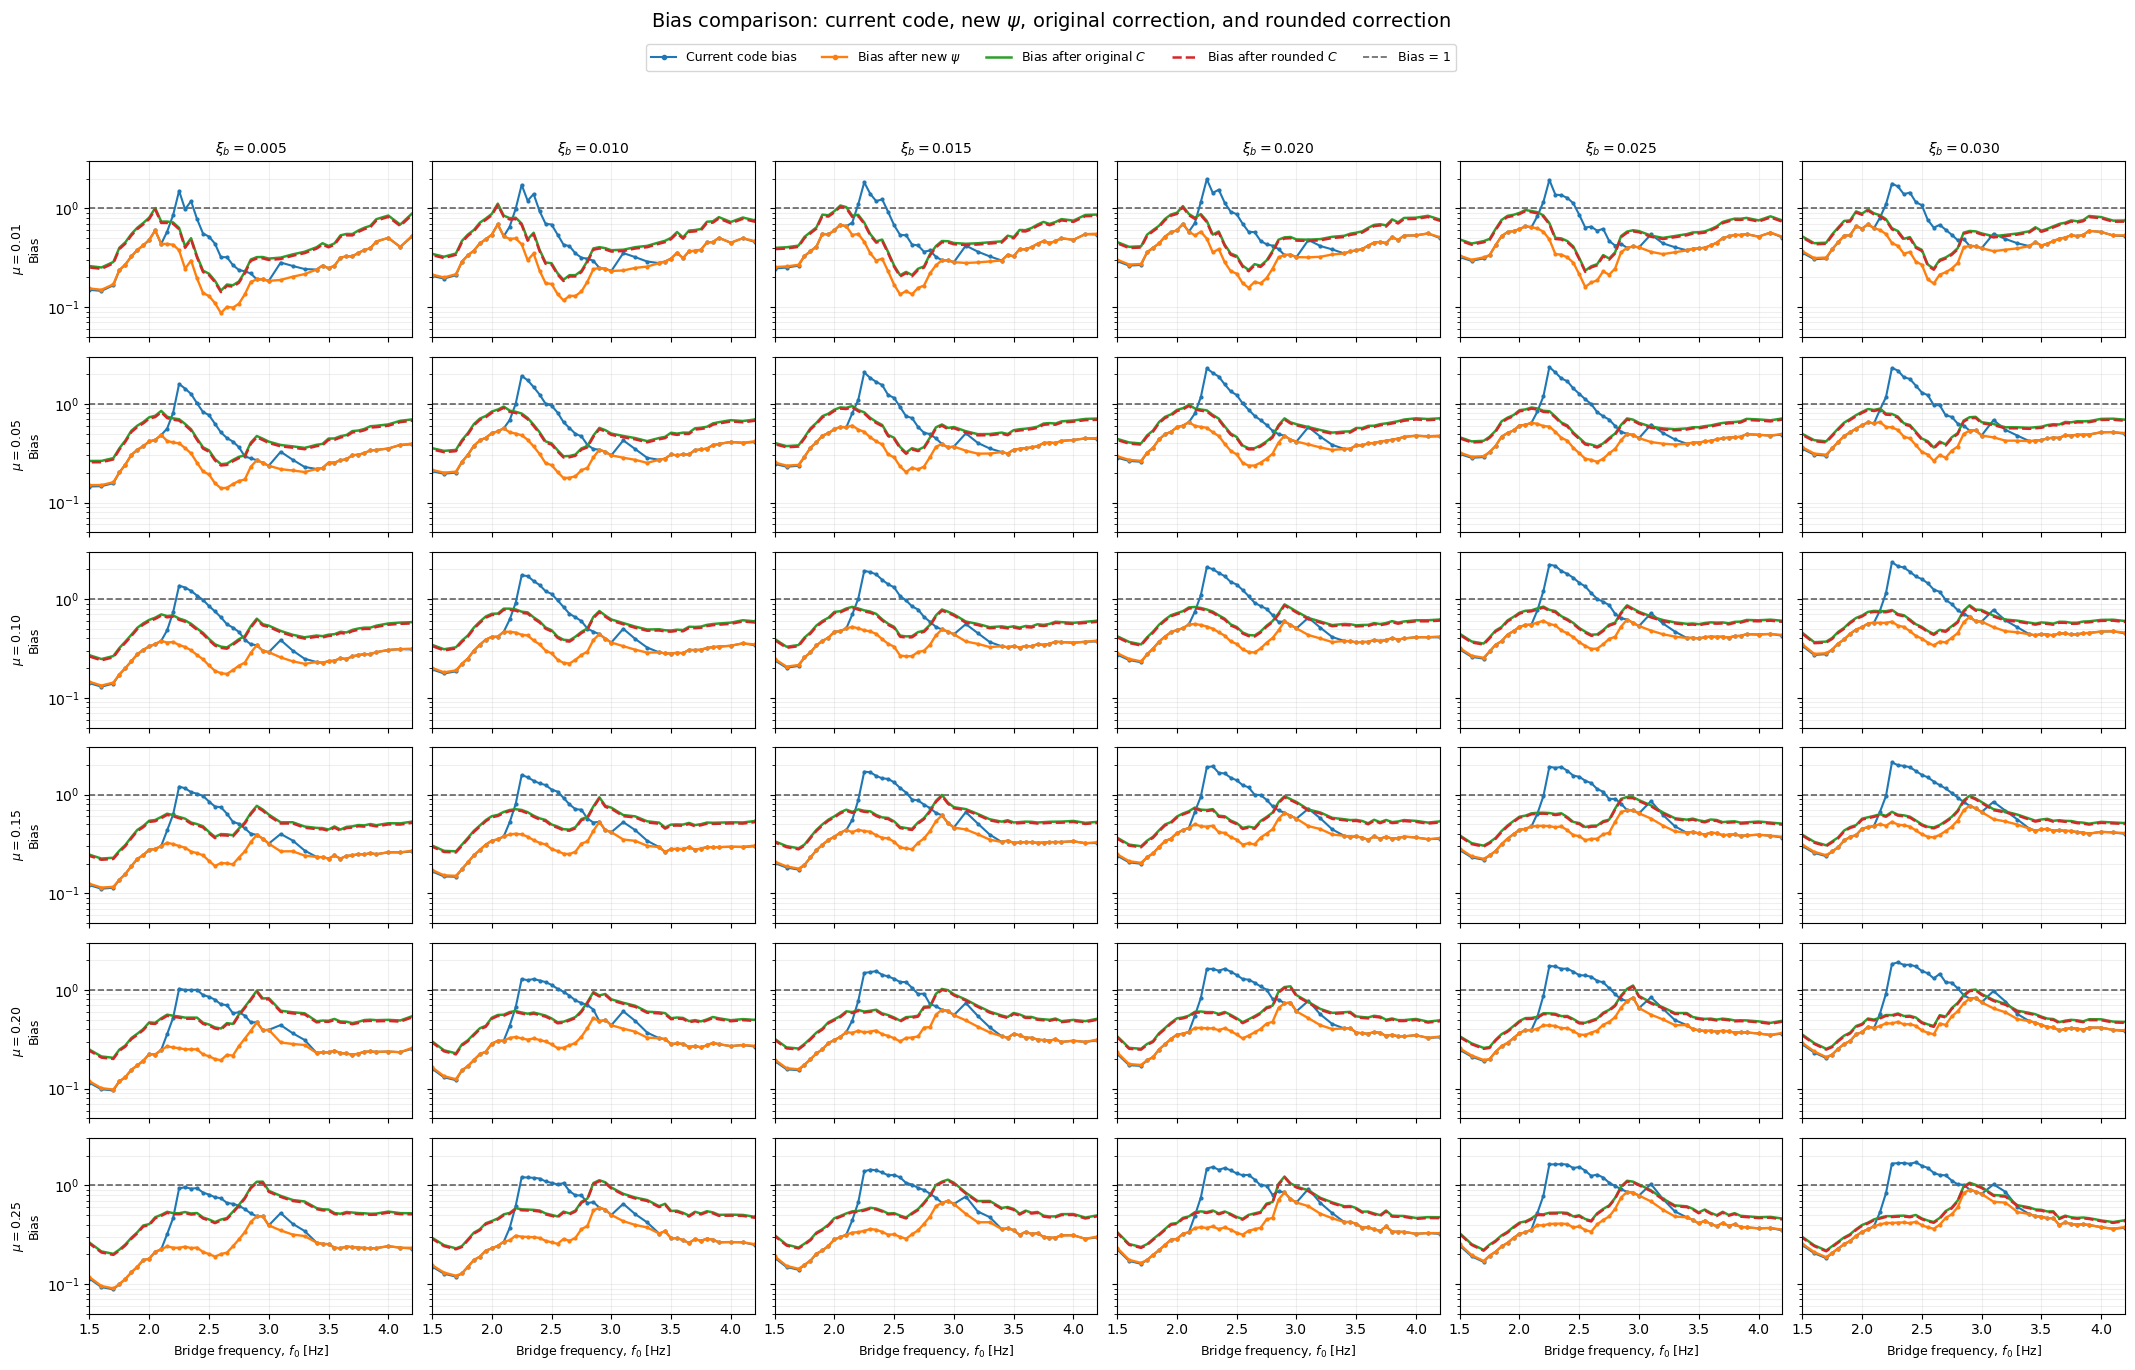

In [ ]:
# ============================================================
# COMPARE:
#
# 1. ORIGINAL CODE BIAS
# 2. BIAS AFTER NEW psi
# 3. BIAS AFTER ORIGINAL C EQUATION
# 4. BIAS AFTER ROUNDED C EQUATION
#
# C_original =
#     0.58 + 4.04 xi_b - 0.86 mu + 49 mu xi_b
#
# C_rounded =
#     0.60 + 4.00 xi_b - 0.90 mu + 50 mu xi_b
#
# Since C multiplies the load-model prediction:
#
#     B_final = B_psi / C
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# 1. COPY CURRENT DATA
# ============================================================

comparison_df = plot_all_df.copy()


# ============================================================
# 2. CALCULATE ORIGINAL AND ROUNDED C
# ============================================================

mu = comparison_df["mass_ratio"].to_numpy(dtype=float)

xi = comparison_df["target_beamdamp"].to_numpy(dtype=float)


comparison_df["C_original"] = (
    0.58
    + 4.04 * xi
    - 0.86 * mu
    + 49.0 * mu * xi
)


comparison_df["C_rounded"] = (
    0.60
    + 4.00 * xi
    - 0.90 * mu
    + 50.0 * mu * xi
)


# ============================================================
# 3. APPLY C TO THE BIAS
#
# IMPORTANT:
#
# B_final = B_after_psi / C
# ============================================================

comparison_df["bias_original_C"] = np.where(
    comparison_df["C_original"] > 0,
    comparison_df["newpsi_bias_mean"]
    / comparison_df["C_original"],
    np.nan
)


comparison_df["bias_rounded_C"] = np.where(
    comparison_df["C_rounded"] > 0,
    comparison_df["newpsi_bias_mean"]
    / comparison_df["C_rounded"],
    np.nan
)


# ============================================================
# 4. SMALL NUMERICAL CHECK:
# DIFFERENCE BETWEEN ORIGINAL AND ROUNDED C
# ============================================================

comparison_df["C_difference"] = (
    comparison_df["C_rounded"]
    - comparison_df["C_original"]
)


comparison_df["C_relative_difference_pct"] = (
    100.0
    * comparison_df["C_difference"]
    / comparison_df["C_original"]
)


comparison_df["bias_difference"] = (
    comparison_df["bias_rounded_C"]
    - comparison_df["bias_original_C"]
)


print(
    "\n============================================================"
)

print(
    "ORIGINAL vs ROUNDED CORRECTION"
)

print(
    "============================================================"
)


print(
    "\nC_original range:"
    f" {comparison_df['C_original'].min():.4f}"
    f" to {comparison_df['C_original'].max():.4f}"
)


print(
    "C_rounded range:"
    f" {comparison_df['C_rounded'].min():.4f}"
    f" to {comparison_df['C_rounded'].max():.4f}"
)


print(
    "\nMaximum absolute difference in C:"
    f" {comparison_df['C_difference'].abs().max():.6f}"
)


print(
    "Maximum relative difference in C:"
    f" {comparison_df['C_relative_difference_pct'].abs().max():.3f}%"
)


print(
    "Maximum absolute difference in resulting bias:"
    f" {comparison_df['bias_difference'].abs().max():.6f}"
)


# ============================================================
# 5. SELECT PEAK ABSOLUTE ACCELERATION
# ============================================================

plot_df = comparison_df[
    comparison_df["measure"].astype(str).str.strip()
    ==
    "Peak absolute acceleration"
].copy()


# ============================================================
# 6. MASS RATIOS + DAMPING RATIOS TO PLOT
#
# This reproduces the style of your screenshot.
#
# If you want mu = 0.30 too, simply add 0.30.
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
]

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

# ============================================================
# PLOT COLOURS
# ============================================================

COLOR_CODE = "C0"
COLOR_NEW_PSI = "C1"
COLOR_ORIGINAL_C = "C2"
COLOR_ROUNDED_C = "C3"

# ============================================================
# 7. COMMON FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)


fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 8. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                damping
            )
        ].copy()

        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ----------------------------------------------------
        # Bias = 1
        # ----------------------------------------------------

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        if not sub.empty:

            # ------------------------------------------------
            # ORIGINAL CODE
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                linewidth=1.5,
                marker="o",
                markersize=2.0,
                color=COLOR_CODE,
                label="Current code"
            )


            # ------------------------------------------------
            # NEW psi ONLY
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_bias_mean"],
                linewidth=1.7,
                marker="o",
                markersize=2.0,
                color=COLOR_NEW_PSI,
                label=r"New $\psi$"
            )


            # ------------------------------------------------
            # NEW psi + ORIGINAL C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_original_C"],
                linewidth=1.8,
                color=COLOR_ORIGINAL_C,
                label=r"New $\psi$ + original $C$"
            )


            # ------------------------------------------------
            # NEW psi + ROUNDED C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_rounded_C"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ROUNDED_C,
                label=r"New $\psi$ + rounded $C$"
            )

        # ----------------------------------------------------
        # COLUMN TITLE = DAMPING
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
            rf"$\xi_b={damping:.3f}$",
                            fontsize=10
            )


        # ----------------------------------------------------
        # ROW LABEL = MASS RATIO
        # ----------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$"
                "\nBias",
                fontsize=9
            )


        # ----------------------------------------------------
        # X LABEL
        # ----------------------------------------------------

        if row == nrows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ [Hz]",
                fontsize=9
            )


        # ----------------------------------------------------
        # FORMAT
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_yscale(
            "log"
        )

        ax.set_ylim(
            0.05,
            3.0
        )

        ax.grid(
            True,
            which="both",
            alpha=0.20
        )


# ============================================================
# 9. COMMON TITLE
# ============================================================

fig.suptitle(
    "Bias comparison: current code, new $\\psi$, "
    "original correction, and rounded correction",
    fontsize=14,
    y=0.995
)


# ============================================================
# 10. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.5,
        marker="o",
        markersize=3,
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.7,
        marker="o",
        markersize=3,
        label=r"Bias after new $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ORIGINAL_C,
        linewidth=1.8,
        label=r"Bias after original $C$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ROUNDED_C,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after rounded $C$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=5,
    fontsize=9,
    frameon=True
)
plt.tight_layout(
    rect=[
        0.02,
        0.02,
        0.995,
        0.94
    ]
)

plt.show()


ORIGINAL POPULATION WEIGHTS
Number of original cells = 36
Original sum W = 1.000000000000

COMMON WEIGHT GRID
Number of common cells = 20

Population probability contained in common domain = 0.760104
                               = 76.01% of the previous weighted domain

NORMALISED COMMON-DOMAIN WEIGHTS
      mu     xi_b  weight_common  weight_common_percent
0.050000 0.005000       0.114847              11.484680
0.050000 0.010000       0.078289               7.828938
0.050000 0.015000       0.033916               3.391639
0.050000 0.020000       0.023882               2.388190
0.100000 0.005000       0.110292              11.029170
0.100000 0.010000       0.056520               5.651965
0.100000 0.015000       0.024054               2.405441
0.100000 0.020000       0.021950               2.195036
0.150000 0.005000       0.076373               7.637262
0.150000 0.010000       0.027340               2.734038
0.150000 0.015000       0.009761               0.976137
0.150000 0.020000    

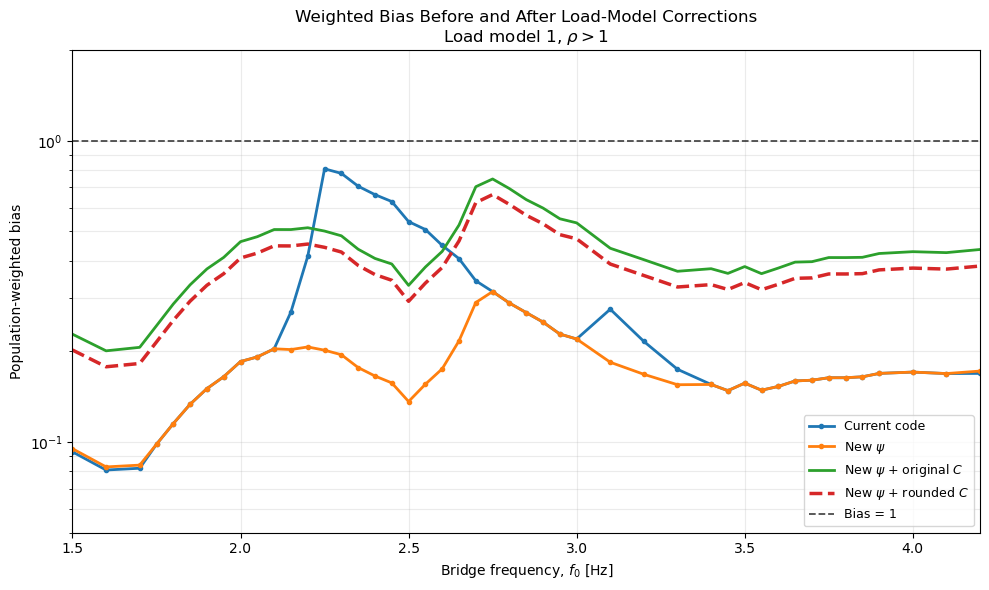


FILES SAVED
second_load_model_population_weighted_bias.csv
second_load_model_population_weighted_detailed.csv
common_domain_population_weights.csv


In [18]:
# ============================================================
# SECOND LOAD MODEL
# POPULATION-WEIGHTED BIAS CURVES
#
# Uses the SAME population probability model as load model 1.
#
# Because load model 2 has a different simulation grid,
# use the COMMON GRID only:
#
# mu:
#   0.05, 0.10, 0.15, 0.20, 0.25
#
# xi:
#   0.005, 0.010, 0.015, 0.020
#
# = 20 common (mu, xi) cells
#
# Existing weights are restricted to these cells and
# renormalised so that:
#
#       sum w_jk = 1
#
# For (mu=0.25, xi=0.005), the second-load-model
# plotting rule uses the response from (mu=0.20, xi=0.005).
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SETTINGS
# ============================================================

WEIGHT_FILE = "bias_line_weights.csv"

F_MIN = 1.50
F_MAX = 4.20


# Common domain between the two load models
MU_COMMON = np.array([
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
])

XI_COMMON = np.array([
    0.005,
    0.010,
    0.015,
    0.020,
])


# ============================================================
# 2. CHECK SECOND-LOAD-MODEL DATA
# ============================================================

required_columns = [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "old_bias",
    "env_bias",
    "bias_original_C",
    "bias_rounded_C",
]

missing_columns = [
    col
    for col in required_columns
    if col not in comparison_df.columns
]

if missing_columns:
    raise KeyError(
        "The second-load-model comparison code must be run first.\n"
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 3. LOAD ORIGINAL POPULATION WEIGHTS
# ============================================================

weights = pd.read_csv(
    WEIGHT_FILE,
    encoding="utf-8-sig"
)


print("\n==========================================")
print("ORIGINAL POPULATION WEIGHTS")
print("==========================================")

print(
    f"Number of original cells = {len(weights)}"
)

print(
    f"Original sum W = {weights['weight'].sum():.12f}"
)


# ============================================================
# 4. ROUND KEYS FOR SAFE FLOAT MATCHING
# ============================================================

weights["mu_key"] = (
    weights["mu"]
    .astype(float)
    .round(6)
)

weights["xi_key"] = (
    weights["xi_b"]
    .astype(float)
    .round(6)
)


# ============================================================
# 5. KEEP ONLY COMMON 5 x 4 DOMAIN
# ============================================================

mu_common_keys = np.round(
    MU_COMMON,
    6
)

xi_common_keys = np.round(
    XI_COMMON,
    6
)


weights_common = weights[
    weights["mu_key"].isin(mu_common_keys)
    &
    weights["xi_key"].isin(xi_common_keys)
].copy()


print("\n==========================================")
print("COMMON WEIGHT GRID")
print("==========================================")

print(
    "Number of common cells =",
    len(weights_common)
)


if len(weights_common) != 20:
    raise ValueError(
        f"Expected 20 common weight cells, "
        f"but found {len(weights_common)}."
    )


# ============================================================
# 6. RAW PROBABILITY MASS OF COMMON DOMAIN
# ============================================================

common_raw_sum = (
    weights_common["weight"].sum()
)


print(
    f"\nPopulation probability contained "
    f"in common domain = {common_raw_sum:.6f}"
)

print(
    f"                               "
    f"= {100*common_raw_sum:.2f}% "
    f"of the previous weighted domain"
)


# ============================================================
# 7. NORMALISE WITHIN COMMON DOMAIN
#
# These are the weights used for BOTH load models
# when comparing them on this common grid.
# ============================================================

weights_common[
    "weight_common"
] = (
    weights_common["weight"]
    /
    common_raw_sum
)


weights_common[
    "weight_common_percent"
] = (
    100
    *
    weights_common["weight_common"]
)


print("\n==========================================")
print("NORMALISED COMMON-DOMAIN WEIGHTS")
print("==========================================")

print(
    weights_common[
        [
            "mu",
            "xi_b",
            "weight_common",
            "weight_common_percent"
        ]
    ]
    .sort_values(
        ["mu", "xi_b"]
    )
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print(
    "\nSum common weights =",
    f"{weights_common['weight_common'].sum():.12f}"
)


# ============================================================
# 8. PREPARE SECOND LOAD MODEL DATA
# ============================================================

second_df = comparison_df.copy()


# Frequency range
second_df = second_df[
    (second_df["bridge_frequency"] >= F_MIN)
    &
    (second_df["bridge_frequency"] <= F_MAX)
].copy()


second_df["mu_key"] = (
    second_df["mass_ratio"]
    .astype(float)
    .round(6)
)

second_df["xi_key"] = (
    second_df["target_beamdamp"]
    .astype(float)
    .round(6)
)


# ============================================================
# 9. BUILD THE 20 REQUIRED RESPONSE CURVES
#
# IMPORTANT:
#
# For target:
#
#       mu = 0.25
#       xi = 0.005
#
# use source:
#
#       mu = 0.20
#       xi = 0.005
#
# This matches your existing second-load-model plotting rule.
# ============================================================

response_blocks = []


for target_mu in MU_COMMON:

    for target_xi in XI_COMMON:

        # ----------------------------------------------------
        # Default:
        # source curve = requested curve
        # ----------------------------------------------------

        source_mu = target_mu
        source_xi = target_xi


        # ----------------------------------------------------
        # Special substitution from second-model figure
        # ----------------------------------------------------

        if (
            np.isclose(target_mu, 0.25)
            and
            np.isclose(target_xi, 0.005)
        ):

            source_mu = 0.20
            source_xi = 0.005


        # ----------------------------------------------------
        # Select source response
        # ----------------------------------------------------

        sub = second_df[
            np.isclose(
                second_df["mass_ratio"],
                source_mu
            )
            &
            np.isclose(
                second_df["target_beamdamp"],
                source_xi
            )
        ].copy()


        if sub.empty:

            raise ValueError(
                "\nNo second-load-model response found for:\n"
                f"target mu = {target_mu}, xi = {target_xi}\n"
                f"source mu = {source_mu}, xi = {source_xi}"
            )


        # ----------------------------------------------------
        # Label using TARGET cell
        # ----------------------------------------------------

        sub["target_mu"] = target_mu
        sub["target_xi"] = target_xi

        sub["source_mu"] = source_mu
        sub["source_xi"] = source_xi

        sub["mu_key_weight"] = round(
            float(target_mu),
            6
        )

        sub["xi_key_weight"] = round(
            float(target_xi),
            6
        )


        response_blocks.append(
            sub
        )


weighted_second_df = pd.concat(
    response_blocks,
    ignore_index=True
)


# ============================================================
# 10. MERGE THE COMMON POPULATION WEIGHTS
# ============================================================

weight_lookup = weights_common[
    [
        "mu_key",
        "xi_key",
        "weight_common",
        "weight_common_percent"
    ]
].copy()


weight_lookup = weight_lookup.rename(
    columns={
        "mu_key": "mu_key_weight",
        "xi_key": "xi_key_weight",
    }
)


weighted_second_df = weighted_second_df.merge(

    weight_lookup,

    on=[
        "mu_key_weight",
        "xi_key_weight"
    ],

    how="left",

    validate="many_to_one"
)


if weighted_second_df[
    "weight_common"
].isna().any():

    missing = (
        weighted_second_df.loc[
            weighted_second_df[
                "weight_common"
            ].isna(),
            [
                "target_mu",
                "target_xi"
            ]
        ]
        .drop_duplicates()
    )

    raise ValueError(
        "Some second-load-model cells did not receive weights:\n"
        +
        missing.to_string(index=False)
    )


# ============================================================
# 11. WEIGHT ALL FOUR SECOND-LOAD-MODEL FORMULATIONS
# ============================================================

# Current/original code
weighted_second_df[
    "weighted_current"
] = (
    weighted_second_df["weight_common"]
    *
    weighted_second_df["old_bias"]
)


# After new psi
weighted_second_df[
    "weighted_new_psi"
] = (
    weighted_second_df["weight_common"]
    *
    weighted_second_df["env_bias"]
)


# After original C
weighted_second_df[
    "weighted_original_C"
] = (
    weighted_second_df["weight_common"]
    *
    weighted_second_df["bias_original_C"]
)


# After rounded C
weighted_second_df[
    "weighted_rounded_C"
] = (
    weighted_second_df["weight_common"]
    *
    weighted_second_df["bias_rounded_C"]
)


# ============================================================
# 12. SUM OVER THE 20 POPULATION CELLS AT EACH FREQUENCY
# ============================================================

weighted_second_lines = (

    weighted_second_df

    .groupby(
        "bridge_frequency",
        as_index=False
    )

    .agg(

        B_current=(
            "weighted_current",
            "sum"
        ),

        B_new_psi=(
            "weighted_new_psi",
            "sum"
        ),

        B_original_C=(
            "weighted_original_C",
            "sum"
        ),

        B_rounded_C=(
            "weighted_rounded_C",
            "sum"
        ),

        weight_sum=(
            "weight_common",
            "sum"
        ),

        n_cells=(
            "weight_common",
            "size"
        )
    )

    .sort_values(
        "bridge_frequency"
    )
)


# ============================================================
# 13. COVERAGE CHECK
# ============================================================

print("\n==========================================")
print("SECOND LOAD MODEL COVERAGE CHECK")
print("==========================================")

print(
    weighted_second_lines[
        [
            "bridge_frequency",
            "weight_sum",
            "n_cells"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


bad = weighted_second_lines[
    (~np.isclose(
        weighted_second_lines["weight_sum"],
        1.0,
        atol=1e-8
    ))
    |
    (
        weighted_second_lines["n_cells"]
        != 20
    )
]


if not bad.empty:

    raise ValueError(
        "\nSome frequencies do not contain "
        "all 20 common population cells:\n"
        +
        bad.to_string(index=False)
    )


# ============================================================
# 14. PRINT WEIGHTED BIAS LINES
# ============================================================

print("\n==========================================")
print("SECOND LOAD MODEL — POPULATION WEIGHTED")
print("==========================================")

print(
    weighted_second_lines[
        [
            "bridge_frequency",
            "B_current",
            "B_new_psi",
            "B_original_C",
            "B_rounded_C"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 15. SUMMARY STATISTICS
# ============================================================

print("\n==========================================")
print("SUMMARY")
print("==========================================")

for col, label in [

    (
        "B_current",
        "Current code"
    ),

    (
        "B_new_psi",
        "New psi"
    ),

    (
        "B_original_C",
        "New psi + original C"
    ),

    (
        "B_rounded_C",
        "New psi + rounded C"
    ),

]:

    values = weighted_second_lines[
        col
    ].to_numpy(dtype=float)

    print(f"\n{label}")

    print(
        f"Mean bias       = "
        f"{np.mean(values):.4f}"
    )

    print(
        f"Minimum bias    = "
        f"{np.min(values):.4f}"
    )

    print(
        f"Maximum bias    = "
        f"{np.max(values):.4f}"
    )

    print(
        f"RMSE from B = 1 = "
        f"{np.sqrt(np.mean((values - 1)**2)):.4f}"
    )


# ============================================================
# 16. PLOT FOUR WEIGHTED LINES
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.plot(
    weighted_second_lines[
        "bridge_frequency"
    ],
    weighted_second_lines[
        "B_current"
    ],
    linewidth=2.0,
    marker="o",
    markersize=3,
    label="Current code"
)


ax.plot(
    weighted_second_lines[
        "bridge_frequency"
    ],
    weighted_second_lines[
        "B_new_psi"
    ],
    linewidth=2.0,
    marker="o",
    markersize=3,
    label=r"New $\psi$"
)


ax.plot(
    weighted_second_lines[
        "bridge_frequency"
    ],
    weighted_second_lines[
        "B_original_C"
    ],
    linewidth=2.0,
    label=r"New $\psi$ + original $C$"
)


ax.plot(
    weighted_second_lines[
        "bridge_frequency"
    ],
    weighted_second_lines[
        "B_rounded_C"
    ],
    linewidth=2.5,
    linestyle="--",
    label=r"New $\psi$ + rounded $C$"
)


# Bias = 1
ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    alpha=0.7,
    label="Bias = 1"
)


# ============================================================
# 17. AXES
# ============================================================

ax.set_xlim(
    F_MIN,
    F_MAX
)

ax.set_yscale(
    "log"
)

ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)

ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(
    "Weighted Bias Before and After Load-Model Corrections\n"
    r"Load model 1, $\rho > 1$"
)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(
    fontsize=9
)


plt.tight_layout()
plt.show()


# ============================================================
# 18. SAVE
# ============================================================

weighted_second_lines.to_csv(
    "second_load_model_population_weighted_bias.csv",
    index=False,
    encoding="utf-8-sig"
)


weighted_second_df.to_csv(
    "second_load_model_population_weighted_detailed.csv",
    index=False,
    encoding="utf-8-sig"
)


weights_common.to_csv(
    "common_domain_population_weights.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\n==========================================")
print("FILES SAVED")
print("==========================================")

print(
    "second_load_model_population_weighted_bias.csv"
)

print(
    "second_load_model_population_weighted_detailed.csv"
)

print(
    "common_domain_population_weights.csv"
)


SECOND LOAD MODEL RESPONSE GRID
 mu_key  xi_key
   0.05   0.005
   0.05   0.010
   0.05   0.015
   0.05   0.020
   0.10   0.005
   0.10   0.010
   0.10   0.015
   0.10   0.020
   0.15   0.005
   0.15   0.010
   0.15   0.015
   0.15   0.020
   0.20   0.005
   0.20   0.010
   0.20   0.015
   0.20   0.020
   0.25   0.005
   0.25   0.010
   0.25   0.015
   0.25   0.020
   0.30   0.005
   0.30   0.010
   0.30   0.015
   0.30   0.020

Number of response cells = 24
Expected = 6 x 4 = 24

SECOND LOAD MODEL POPULATION WEIGHTS
Weight mass retained from original grid = 0.76010354
Renormalised weight sum = 1.000000000000

NOTE: response cells exist outside the final weighted domain:
[(0.3, 0.005), (0.3, 0.01), (0.3, 0.015), (0.3, 0.02)]

SECOND LOAD MODEL — PERCENTILE = 50

OLS equation:
C_50 = 0.05273135 +16.03105861 xi_b -0.08504080 mu -11.39594961 mu*xi_b

After +0.050 intercept shift:
C_50 = 0.10273135 +16.03105861 xi_b -0.08504080 mu -11.39594961 mu*xi_b

OLS: R2 = 0.994539, RMSE = 0.006060


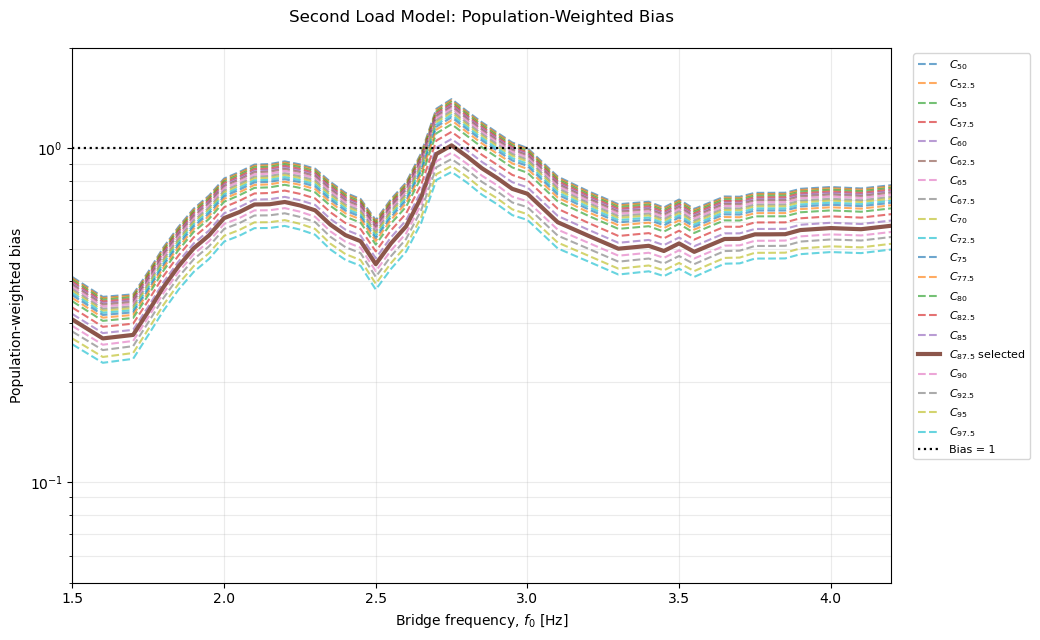

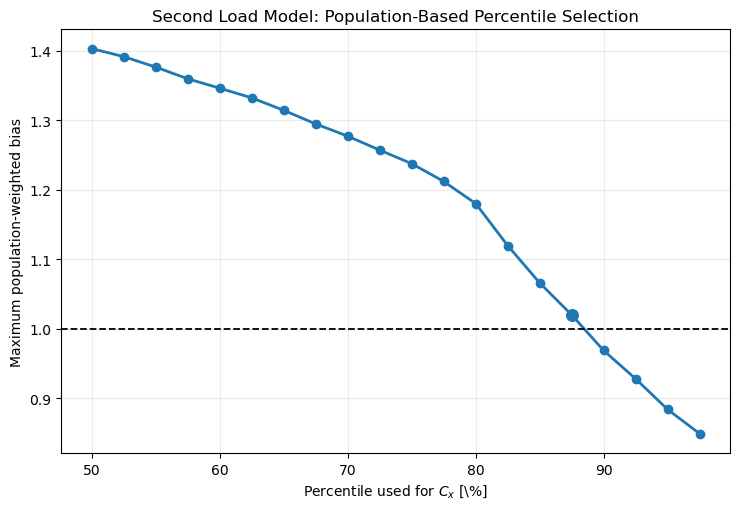


Saved:
second_Cx_raw_percentile_points_and_fits.csv
second_Cx_candidate_equations.csv
second_Cx_percentile_selection_summary.csv
second_Cx_population_weighted_bias_lines.csv
second_Cx_candidate_detailed_bias.csv
second_load_model_population_weights.csv


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SECOND LOAD MODEL
# POPULATION-BASED SELECTION OF C_x PERCENTILE
# ============================================================
#
# For each percentile x:
#
# 1. For every fixed (mu, xi_b), take the xth percentile
#    of env_bias across bridge frequency.
#
#       C_x(mu,xi_b) = P_x[env_bias across f]
#
# 2. Fit:
#
#       C_x =
#       b0
#       + b_xi xi_b
#       + b_mu mu
#       + b_muxi mu xi_b
#
# 3. Add +0.05 to fitted intercept.
#
# 4. Recalculate:
#
#       B_after_Cx = env_bias / C_x
#
# 5. Apply population weights appropriate to the
#    second-load-model domain.
#
# 6. Form:
#
#       B_W,x(f) = sum_jk w_jk B_jk,x(f)
#
# 7. Choose percentile with:
#
#       min | max_f(B_W,x) - 1 |
#
# ============================================================


# ============================================================
# 1. SETTINGS
# ============================================================

PERCENTILES = [

    50.0,
    52.5,
    55.0,
    57.5,
    60.0,
    62.5,
    65.0,
    67.5,
    70.0,
    72.5,
    75.0,
    77.5,
    80.0,
    82.5,
    85.0,
    87.5,
    90.0,
    92.5,
    95.0,
    97.5,

]


# Same manual intercept safety shift
SAFETY_SHIFT = 0.05


# ------------------------------------------------------------
# SECOND LOAD MODEL DOMAIN
# ------------------------------------------------------------

SECOND_MU_VALUES = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
]

SECOND_XI_VALUES = [
    0.005,
    0.010,
    0.015,
    0.020,
]


# ------------------------------------------------------------
# Frequency range
#
# Second model currently runs 1.50 - 4.20 Hz
# ------------------------------------------------------------

CX_FMIN = 1.50
CX_FMAX = 4.20

EVAL_FMIN = 1.50
EVAL_FMAX = 4.20


# Numerical matching
MU_KEY_DECIMALS = 4
XI_KEY_DECIMALS = 4
FREQ_KEY_DECIMALS = 6


# ============================================================
# 2. SPECIAL SECOND-LOAD-MODEL REPEAT RULE
# ============================================================
#
# Same assumption used in your existing second-model plots:
#
# response at:
#
#     mu = 0.25, xi = 0.005
#     mu = 0.30, xi = 0.005
#
# repeats response from:
#
#     mu = 0.20, xi = 0.005
#
# IMPORTANT:
#
# We copy the RESPONSE but retain the TARGET mu value.
# Therefore the fitted C_x surface still sees:
#
#     mu = 0.25
#     mu = 0.30
#
# ============================================================

REPEAT_SOURCE_MU = 0.20
REPEAT_SOURCE_XI = 0.005

REPEAT_TARGETS = [

    (0.25, 0.005),

    (0.30, 0.005),

]


# ============================================================
# 3. CHECK SECOND-LOAD-MODEL DATA
# ============================================================

if "compare_df" not in globals():

    raise NameError(

        "compare_df does not exist.\n"

        "Run the second-load-model psi code first."

    )


required_columns = [

    "bridge_frequency",
    "mass_ratio",
    "damping_key",
    "env_bias",

]


missing_columns = [

    column

    for column in required_columns

    if column not in compare_df.columns

]


if missing_columns:

    raise KeyError(

        "compare_df is missing required columns:\n"

        f"{missing_columns}"

    )


# ============================================================
# 4. PREPARE SECOND-LOAD-MODEL BIAS DATA
# ============================================================

bias_df = compare_df.copy()


for column in [

    "bridge_frequency",
    "mass_ratio",
    "damping_key",
    "env_bias",

]:

    bias_df[column] = pd.to_numeric(

        bias_df[column],

        errors="coerce"

    )


bias_df = bias_df.dropna(

    subset=[

        "bridge_frequency",
        "mass_ratio",
        "damping_key",
        "env_bias",

    ]

).copy()


bias_df = bias_df[

    np.isfinite(
        bias_df["env_bias"]
    )

].copy()


# Standard damping column

bias_df["target_beamdamp"] = (

    bias_df["damping_key"]
    .astype(float)

)


# ============================================================
# 5. KEEP SECOND-MODEL DOMAIN
# ============================================================

mu_mask = np.zeros(
    len(bias_df),
    dtype=bool
)


for mu_value in SECOND_MU_VALUES:

    mu_mask |= np.isclose(

        bias_df["mass_ratio"],

        mu_value

    )


xi_mask = np.zeros(
    len(bias_df),
    dtype=bool
)


for xi_value in SECOND_XI_VALUES:

    xi_mask |= np.isclose(

        bias_df["target_beamdamp"],

        xi_value

    )


bias_df = bias_df[

    mu_mask
    &
    xi_mask
    &
    (
        bias_df["bridge_frequency"]
        >=
        CX_FMIN
    )
    &
    (
        bias_df["bridge_frequency"]
        <=
        CX_FMAX
    )

].copy()


if bias_df.empty:

    raise ValueError(

        "No second-load-model data remain after filtering."

    )


# ============================================================
# 6. COLLAPSE DUPLICATE LINEAR-MASS REALISATIONS
# ============================================================
#
# compare_df may contain more than one linear mass mapping
# to the same mass ratio.
#
# For the optimisation we need ONE bias value for each:
#
# (mu, xi_b, frequency)
#
# ============================================================

bias_df = (

    bias_df

    .groupby(

        [

            "mass_ratio",
            "target_beamdamp",
            "bridge_frequency",

        ],

        as_index=False

    )

    .agg(

        env_bias=(
            "env_bias",
            "mean"
        )

    )

)


# ============================================================
# 7. APPLY SPECIAL REPEAT RULE
# ============================================================
#
# Remove any existing target data for the repeated cells,
# then rebuild them from mu = 0.20, xi = 0.005.
#
# ============================================================

repeat_parts = []


for target_mu, target_xi in REPEAT_TARGETS:


    source = bias_df[

        np.isclose(
            bias_df["mass_ratio"],
            REPEAT_SOURCE_MU
        )

        &

        np.isclose(
            bias_df["target_beamdamp"],
            REPEAT_SOURCE_XI
        )

    ].copy()


    if source.empty:

        raise ValueError(

            "Cannot perform repeat rule because "
            f"source cell "
            f"(mu={REPEAT_SOURCE_MU:.2f}, "
            f"xi={REPEAT_SOURCE_XI:.3f}) "
            "was not found."

        )


    # Keep response, change target coordinates

    source["mass_ratio"] = target_mu

    source["target_beamdamp"] = target_xi


    repeat_parts.append(
        source
    )


# Remove any original rows at repeated target cells

remove_mask = np.zeros(
    len(bias_df),
    dtype=bool
)


for target_mu, target_xi in REPEAT_TARGETS:

    remove_mask |= (

        np.isclose(
            bias_df["mass_ratio"],
            target_mu
        )

        &

        np.isclose(
            bias_df["target_beamdamp"],
            target_xi
        )

    )


bias_df = bias_df[
    ~remove_mask
].copy()


bias_df = pd.concat(

    [
        bias_df,
        *repeat_parts,
    ],

    ignore_index=True

)


# ============================================================
# 8. CREATE MATCHING KEYS
# ============================================================

bias_df["mu_key"] = (

    bias_df["mass_ratio"]
    .round(MU_KEY_DECIMALS)

)


bias_df["xi_key"] = (

    bias_df["target_beamdamp"]
    .round(XI_KEY_DECIMALS)

)


bias_df["f_key"] = (

    bias_df["bridge_frequency"]
    .round(FREQ_KEY_DECIMALS)

)


# ============================================================
# 9. CHECK SECOND-MODEL RESPONSE GRID
# ============================================================

response_cells = (

    bias_df[
        [
            "mu_key",
            "xi_key",
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "mu_key",
            "xi_key",
        ]
    )

)


print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL RESPONSE GRID"
)

print(
    "============================================================"
)


print(
    response_cells.to_string(
        index=False
    )
)


print(

    f"\nNumber of response cells = "
    f"{len(response_cells)}"

)


expected_number_cells = (

    len(SECOND_MU_VALUES)
    *
    len(SECOND_XI_VALUES)

)


print(

    f"Expected = "
    f"{len(SECOND_MU_VALUES)} x "
    f"{len(SECOND_XI_VALUES)} "
    f"= {expected_number_cells}"

)


if len(response_cells) != expected_number_cells:

    raise ValueError(

        "Second-load-model response grid is incomplete.\n"

        "Check the printed cells above."

    )


# ============================================================
# 10. GET POPULATION WEIGHTS
# ============================================================

if "weights_df" not in globals():

    raise NameError(

        "weights_df does not exist.\n"

        "Run the population-weight code first."

    )


W_full = weights_df.copy()


required_weight_columns = [

    "mu",
    "xi_b",
    "weight",

]


missing_weights = [

    column

    for column in required_weight_columns

    if column not in W_full.columns

]


if missing_weights:

    raise KeyError(

        "weights_df is missing:\n"

        f"{missing_weights}"

    )


for column in [

    "mu",
    "xi_b",
    "weight",

]:

    W_full[column] = pd.to_numeric(

        W_full[column],

        errors="coerce"

    )


W_full = W_full.dropna(

    subset=[
        "mu",
        "xi_b",
        "weight",
    ]

).copy()


# ============================================================
# 11. RESTRICT WEIGHTS TO SECOND-MODEL DOMAIN
# ============================================================
#
# Population probabilities themselves do not change.
#
# But the second load model represents only:
#
# mu = 0.05 ... 0.30
#
# xi = 0.005 ... 0.020
#
# So we condition / renormalise the same population weights
# over this represented domain.
#
# ============================================================

mu_weight_mask = np.zeros(
    len(W_full),
    dtype=bool
)


for mu_value in SECOND_MU_VALUES:

    mu_weight_mask |= np.isclose(

        W_full["mu"],

        mu_value

    )


xi_weight_mask = np.zeros(
    len(W_full),
    dtype=bool
)


for xi_value in SECOND_XI_VALUES:

    xi_weight_mask |= np.isclose(

        W_full["xi_b"],

        xi_value

    )


W = W_full[

    mu_weight_mask
    &
    xi_weight_mask

].copy()


if W.empty:

    raise ValueError(

        "No population weights overlap "
        "the second-load-model grid."

    )


# ============================================================
# 12. NORMALISE SECOND-MODEL WEIGHTS
# ============================================================

weight_sum_before = (

    W["weight"]
    .sum()

)


if weight_sum_before <= 0:

    raise ValueError(

        "Second-model population weights sum to zero."

    )


W["weight_original"] = (
    W["weight"]
)


W["weight"] = (

    W["weight"]

    /

    weight_sum_before

)


print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL POPULATION WEIGHTS"
)

print(
    "============================================================"
)


print(

    f"Weight mass retained from original grid = "
    f"{weight_sum_before:.8f}"

)


print(

    f"Renormalised weight sum = "
    f"{W['weight'].sum():.12f}"

)


W["mu_key"] = (

    W["mu"]
    .round(MU_KEY_DECIMALS)

)


W["xi_key"] = (

    W["xi_b"]
    .round(XI_KEY_DECIMALS)

)


if W.duplicated(
    [
        "mu_key",
        "xi_key",
    ]
).any():

    raise ValueError(

        "Duplicate cells exist in second-model weights."

    )


# ============================================================
# 13. CHECK RESPONSE GRID = WEIGHT GRID
# ============================================================

expected_cells = set(

    zip(

        W["mu_key"],

        W["xi_key"]

    )

)


available_cells = set(

    zip(

        bias_df["mu_key"],

        bias_df["xi_key"]

    )

)


missing_response_cells = (

    expected_cells

    -

    available_cells

)


extra_response_cells = (

    available_cells

    -

    expected_cells

)


if missing_response_cells:

    raise ValueError(

        "Weighted cells missing from second-model response:\n"

        f"{sorted(missing_response_cells)}"

    )


if extra_response_cells:

    print(

        "\nNOTE: response cells exist outside "
        "the final weighted domain:\n"

        f"{sorted(extra_response_cells)}"

    )


# Only retain cells with population weights

bias_df = bias_df.merge(

    W[
        [
            "mu_key",
            "xi_key",
        ]
    ],

    on=[
        "mu_key",
        "xi_key",
    ],

    how="inner"

)


# ============================================================
# 14. DESIGN MATRIX
#
# Start with SAME full bilinear form as load model 1:
#
# C_x =
#
# b0
# + b_xi xi_b
# + b_mu mu
# + b_muxi mu xi_b
#
# We can simplify terms AFTER selecting the percentile.
# ============================================================

def design_matrix(
    mu,
    xi
):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )


    return np.column_stack(

        [

            np.ones_like(mu),

            xi,

            mu,

            mu * xi,

        ]

    )


def predict_C(
    mu,
    xi,
    beta
):

    X = design_matrix(
        mu,
        xi
    )

    return (

        X

        @

        np.asarray(
            beta,
            dtype=float
        )

    )


# ============================================================
# 15. FIT STATISTICS
# ============================================================

def calculate_r2(
    observed,
    predicted
):

    observed = np.asarray(
        observed,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )


    ss_res = np.sum(

        (
            observed
            -
            predicted
        ) ** 2

    )


    ss_tot = np.sum(

        (
            observed
            -
            np.mean(observed)
        ) ** 2

    )


    if ss_tot <= 0:

        return np.nan


    return (

        1.0
        -
        ss_res / ss_tot

    )


def calculate_rmse(
    observed,
    predicted
):

    observed = np.asarray(
        observed,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )


    return float(

        np.sqrt(

            np.mean(

                (
                    observed
                    -
                    predicted
                ) ** 2

            )

        )

    )


# ============================================================
# 16. EQUATION PRINT FUNCTION
# ============================================================

def equation_text(
    percentile,
    beta
):

    b0 = beta[0]
    bxi = beta[1]
    bmu = beta[2]
    bmuxi = beta[3]


    return (

        f"C_{percentile:g} = "

        f"{b0:.8f} "

        f"{bxi:+.8f} xi_b "

        f"{bmu:+.8f} mu "

        f"{bmuxi:+.8f} mu*xi_b"

    )


# ============================================================
# 17. DATA USED TO CALCULATE C_x
# ============================================================

cx_source = bias_df[

    (
        bias_df["bridge_frequency"]
        >=
        CX_FMIN
    )

    &

    (
        bias_df["bridge_frequency"]
        <=
        CX_FMAX
    )

].copy()


if cx_source.empty:

    raise ValueError(

        "No second-model data inside C_x frequency range."

    )


# ============================================================
# 18. CALCULATE RAW C_x FOR EVERY PERCENTILE
# ============================================================

raw_cx_tables = {}


for percentile in PERCENTILES:


    cx = (

        cx_source

        .groupby(

            [
                "mu_key",
                "xi_key",
            ],

            as_index=False

        )

        ["env_bias"]

        .quantile(
            percentile / 100.0
        )

        .rename(

            columns={

                "env_bias":
                    "C_raw"

            }

        )

    )


    cx["percentile"] = percentile


    raw_cx_tables[
        percentile
    ] = cx


# ============================================================
# 19. STORAGE
# ============================================================

summary_rows = []

equation_rows = []

weighted_line_parts = []

detailed_parts = []

raw_point_parts = []


# ============================================================
# 20. PROCESS EVERY PERCENTILE
# ============================================================

for percentile in PERCENTILES:


    print(
        "\n============================================================"
    )

    print(
        f"SECOND LOAD MODEL — PERCENTILE = "
        f"{percentile:g}"
    )

    print(
        "============================================================"
    )


    cx = (

        raw_cx_tables[
            percentile
        ]

        .copy()

    )


    # ========================================================
    # Check all weighted cells are represented
    # ========================================================

    cx_cells = set(

        zip(

            cx["mu_key"],

            cx["xi_key"]

        )

    )


    if cx_cells != expected_cells:


        missing_here = (

            expected_cells

            -

            cx_cells

        )


        extra_here = (

            cx_cells

            -

            expected_cells

        )


        raise ValueError(

            f"Percentile {percentile:g}: "
            "C_x grid mismatch.\n"

            f"Missing = {sorted(missing_here)}\n"

            f"Extra = {sorted(extra_here)}"

        )


    # ========================================================
    # 21. FIT C_x
    # ========================================================

    mu_raw = (

        cx["mu_key"]
        .to_numpy(
            dtype=float
        )

    )


    xi_raw = (

        cx["xi_key"]
        .to_numpy(
            dtype=float
        )

    )


    C_raw = (

        cx["C_raw"]
        .to_numpy(
            dtype=float
        )

    )


    X = design_matrix(

        mu_raw,

        xi_raw

    )


    beta, *_ = np.linalg.lstsq(

        X,

        C_raw,

        rcond=None

    )


    C_fit = (

        X
        @
        beta

    )


    # ========================================================
    # 22. +0.05 MANUAL INTERCEPT SAFETY SHIFT
    # ========================================================

    beta_shifted = (
        beta.copy()
    )


    beta_shifted[0] += (
        SAFETY_SHIFT
    )


    C_fit_shifted = (

        X
        @
        beta_shifted

    )


    # ========================================================
    # 23. FIT STATISTICS
    # ========================================================

    R2_OLS = calculate_r2(

        C_raw,

        C_fit

    )


    RMSE_OLS = calculate_rmse(

        C_raw,

        C_fit

    )


    R2_shifted = calculate_r2(

        C_raw,

        C_fit_shifted

    )


    RMSE_shifted = calculate_rmse(

        C_raw,

        C_fit_shifted

    )


    cx["C_fit"] = C_fit

    cx["C_fit_shifted"] = (
        C_fit_shifted
    )


    raw_point_parts.append(
        cx.copy()
    )


    # ========================================================
    # 24. STORE EQUATION
    # ========================================================

    equation = equation_text(

        percentile,

        beta_shifted

    )


    equation_rows.append(

        {

            "percentile":
                percentile,

            "safety_shift":
                SAFETY_SHIFT,

            "intercept_OLS":
                beta[0],

            "intercept_shifted":
                beta_shifted[0],

            "coef_xi":
                beta_shifted[1],

            "coef_mu":
                beta_shifted[2],

            "coef_mu_xi":
                beta_shifted[3],

            "R2_OLS":
                R2_OLS,

            "RMSE_OLS":
                RMSE_OLS,

            "R2_after_shift":
                R2_shifted,

            "RMSE_after_shift":
                RMSE_shifted,

            "equation":
                equation,

        }

    )


    print(
        "\nOLS equation:"
    )


    print(
        equation_text(
            percentile,
            beta
        )
    )


    print(
        "\nAfter +"
        f"{SAFETY_SHIFT:.3f} "
        "intercept shift:"
    )


    print(
        equation
    )


    print(

        f"\nOLS: "
        f"R2 = {R2_OLS:.6f}, "
        f"RMSE = {RMSE_OLS:.6f}"

    )


    print(

        f"Shifted: "
        f"R2 = {R2_shifted:.6f}, "
        f"RMSE = {RMSE_shifted:.6f}"

    )


    # ========================================================
    # 25. APPLY C_x TO SECOND-LOAD-MODEL BIAS
    # ========================================================

    candidate = bias_df[

        (
            bias_df["bridge_frequency"]
            >=
            EVAL_FMIN
        )

        &

        (
            bias_df["bridge_frequency"]
            <=
            EVAL_FMAX
        )

    ].copy()


    candidate["C_candidate"] = predict_C(

        candidate[
            "mass_ratio"
        ].to_numpy(
            dtype=float
        ),

        candidate[
            "target_beamdamp"
        ].to_numpy(
            dtype=float
        ),

        beta_shifted

    )


    # C must remain positive

    if (

        candidate[
            "C_candidate"
        ]

        <=
        0

    ).any():


        bad = (

            candidate.loc[

                candidate[
                    "C_candidate"
                ]
                <=
                0,

                [
                    "mass_ratio",
                    "target_beamdamp",
                    "C_candidate",
                ]

            ]

            .drop_duplicates()

        )


        raise ValueError(

            f"Percentile {percentile:g}: "
            "C became non-positive:\n"

            +

            bad.to_string(
                index=False
            )

        )


    # ========================================================
    # 26. RECALCULATE BIAS
    # ========================================================

    candidate["bias_after_Cx"] = (

        candidate["env_bias"]

        /

        candidate["C_candidate"]

    )


    # ========================================================
    # 27. ADD SECOND-MODEL POPULATION WEIGHTS
    # ========================================================

    candidate = candidate.merge(

        W[
            [
                "mu_key",
                "xi_key",
                "weight",
            ]
        ],

        on=[
            "mu_key",
            "xi_key",
        ],

        how="left",

        validate="many_to_one"

    )


    if candidate[
        "weight"
    ].isna().any():

        raise ValueError(

            f"Percentile {percentile:g}: "
            "some second-model curves "
            "did not receive population weights."

        )


    # ========================================================
    # 28. CHECK COMPLETE GRID AT EACH FREQUENCY
    # ========================================================

    coverage = (

        candidate

        .groupby(
            "f_key"
        )

        .agg(

            weight_sum=(
                "weight",
                "sum"
            ),

            n_cells=(
                "weight",
                "size"
            ),

        )

        .reset_index()

    )


    good_frequencies = coverage[

        np.isclose(

            coverage[
                "weight_sum"
            ],

            1.0,

            atol=1e-8

        )

        &

        (
            coverage[
                "n_cells"
            ]

            ==
            len(W)
        )

    ][
        "f_key"
    ]


    dropped = coverage[

        ~coverage[
            "f_key"
        ].isin(
            good_frequencies
        )

    ]


    if not dropped.empty:

        print(

            f"\nDropping "
            f"{len(dropped)} "
            "incomplete frequency points."

        )


    candidate = candidate[

        candidate[
            "f_key"
        ].isin(
            good_frequencies
        )

    ].copy()


    if candidate.empty:

        raise ValueError(

            f"Percentile {percentile:g}: "
            "no complete weighted frequencies remain."

        )


    # ========================================================
    # 29. WEIGHT EACH CURVE
    # ========================================================

    candidate["weighted_contribution"] = (

        candidate["weight"]

        *

        candidate["bias_after_Cx"]

    )


    # ========================================================
    # 30. SINGLE POPULATION-WEIGHTED LINE
    # ========================================================

    weighted_line = (

        candidate

        .groupby(

            "f_key",

            as_index=False

        )

        .agg(

            bridge_frequency=(
                "bridge_frequency",
                "mean"
            ),

            B_weighted=(
                "weighted_contribution",
                "sum"
            ),

            weight_sum=(
                "weight",
                "sum"
            ),

        )

        .sort_values(
            "bridge_frequency"
        )

    )


    # ========================================================
    # 31. PEAK
    # ========================================================

    peak_index = (

        weighted_line[
            "B_weighted"
        ]

        .idxmax()

    )


    peak_bias = float(

        weighted_line.loc[

            peak_index,

            "B_weighted"

        ]

    )


    peak_frequency = float(

        weighted_line.loc[

            peak_index,

            "bridge_frequency"

        ]

    )


    peak_gap = abs(

        1.0

        -

        peak_bias

    )


    # ========================================================
    # STORE PERFORMANCE
    # ========================================================

    summary_rows.append(

        {

            "percentile":
                percentile,

            "weighted_peak_bias":
                peak_bias,

            "peak_frequency_Hz":
                peak_frequency,

            "absolute_gap_to_1":
                peak_gap,

            "weighted_mean_bias":
                float(
                    weighted_line[
                        "B_weighted"
                    ].mean()
                ),

            "weighted_min_bias":
                float(
                    weighted_line[
                        "B_weighted"
                    ].min()
                ),

            "peak_at_or_below_1":
                bool(
                    peak_bias
                    <=
                    1.0 + 1e-12
                ),

        }

    )


    weighted_line[
        "percentile"
    ] = percentile


    weighted_line_parts.append(
        weighted_line
    )


    candidate[
        "percentile"
    ] = percentile


    detailed_parts.append(
        candidate
    )


# ============================================================
# 32. COMBINE ALL RESULTS
# ============================================================

selection_df_second = pd.DataFrame(

    summary_rows

).sort_values(

    "percentile"

).reset_index(

    drop=True

)


equation_df_second = pd.DataFrame(

    equation_rows

).sort_values(

    "percentile"

).reset_index(

    drop=True

)


all_weighted_lines_second = pd.concat(

    weighted_line_parts,

    ignore_index=True

)


all_detailed_second = pd.concat(

    detailed_parts,

    ignore_index=True

)


all_raw_cx_second = pd.concat(

    raw_point_parts,

    ignore_index=True

)


# ============================================================
# 33. SELECT BEST PERCENTILE
# ============================================================
#
# min | max(B_W) - 1 |
#
# ============================================================

best_index = (

    selection_df_second[
        "absolute_gap_to_1"
    ]

    .idxmin()

)


best_second = (

    selection_df_second.loc[
        best_index
    ]

)


best_percentile_second = float(

    best_second[
        "percentile"
    ]

)


# ============================================================
# 34. BEST CONSERVATIVE OPTION
# ============================================================

conservative_candidates = (

    selection_df_second[

        selection_df_second[
            "peak_at_or_below_1"
        ]

    ]

    .copy()

)


if not conservative_candidates.empty:


    best_conservative_index = (

        conservative_candidates[
            "absolute_gap_to_1"
        ]

        .idxmin()

    )


    best_conservative_second = (

        conservative_candidates.loc[
            best_conservative_index
        ]

    )


else:

    best_conservative_second = None


# ============================================================
# 35. PRINT SELECTION SUMMARY
# ============================================================

print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — PERCENTILE SELECTION"
)

print(
    "============================================================\n"
)


print(

    selection_df_second.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


# ============================================================
# 36. PRINT ALL EQUATIONS
# ============================================================

print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — SHIFTED C_x EQUATIONS"
)

print(
    "============================================================"
)


for _, row in equation_df_second.iterrows():


    print(

        f"\nPercentile "
        f"{row['percentile']:g}"

    )


    print(
        row["equation"]
    )


    print(

        f"OLS: "
        f"R2={row['R2_OLS']:.6f}, "
        f"RMSE={row['RMSE_OLS']:.6f}"

    )


# ============================================================
# 37. WINNER
# ============================================================

best_equation_second = (

    equation_df_second.loc[

        np.isclose(

            equation_df_second[
                "percentile"
            ],

            best_percentile_second

        ),

        "equation"

    ]

    .iloc[0]

)


print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — BEST BY PEAK-GAP CRITERION"
)

print(
    "============================================================"
)


print(

    f"Selected percentile = "
    f"{best_percentile_second:g}"

)


print(

    f"Maximum weighted bias = "
    f"{best_second['weighted_peak_bias']:.6f}"

)


print(

    f"Peak frequency = "
    f"{best_second['peak_frequency_Hz']:.4f} Hz"

)


print(

    f"Gap to Bias = 1 = "
    f"{best_second['absolute_gap_to_1']:.6f}"

)


print(
    "\nSelected equation:"
)


print(
    best_equation_second
)


# ============================================================
# 38. BEST CONSERVATIVE OPTION
# ============================================================

if best_conservative_second is not None:


    conservative_percentile = float(

        best_conservative_second[
            "percentile"
        ]

    )


    conservative_equation = (

        equation_df_second.loc[

            np.isclose(

                equation_df_second[
                    "percentile"
                ],

                conservative_percentile

            ),

            "equation"

        ]

        .iloc[0]

    )


    print(
        "\n============================================================"
    )

    print(
        "SECOND MODEL — BEST WITH MAX WEIGHTED BIAS <= 1"
    )

    print(
        "============================================================"
    )


    print(

        f"Percentile = "
        f"{conservative_percentile:g}"

    )


    print(

        f"Maximum weighted bias = "
        f"{best_conservative_second['weighted_peak_bias']:.6f}"

    )


    print(

        f"Gap below 1 = "
        f"{1.0 - best_conservative_second['weighted_peak_bias']:.6f}"

    )


    print(
        "\nEquation:"
    )


    print(
        conservative_equation
    )


# ============================================================
# 39. PLOT ALL CANDIDATE WEIGHTED LINES
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        10.5,
        6.5
    )
)


for percentile in PERCENTILES:


    sub = all_weighted_lines_second[

        np.isclose(

            all_weighted_lines_second[
                "percentile"
            ],

            percentile

        )

    ].sort_values(
        "bridge_frequency"
    )


    selected = np.isclose(

        percentile,

        best_percentile_second

    )


    ax.plot(

        sub[
            "bridge_frequency"
        ],

        sub[
            "B_weighted"
        ],

        linewidth=(

            3.0
            if selected
            else
            1.5

        ),

        linestyle=(

            "-"
            if selected
            else
            "--"

        ),

        alpha=(

            1.0
            if selected
            else
            0.65

        ),

        label=(

            rf"$C_{{{percentile:g}}}$"

            +

            (
                " selected"
                if selected
                else
                ""
            )

        )

    )


ax.axhline(

    1.0,

    color="black",

    linestyle=":",

    linewidth=1.6,

    label="Bias = 1"

)


ax.set_xlim(
    EVAL_FMIN,
    EVAL_FMAX
)


ax.set_yscale(
    "log"
)


ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(

    "Second Load Model: Population-Weighted Bias\n"

   

)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(

    bbox_to_anchor=(
        1.02,
        1.0
    ),

    loc="upper left",

    fontsize=8

)


plt.tight_layout()

plt.show()


# ============================================================
# 40. PLOT PEAK BIAS VS PERCENTILE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7.5,
        5.2
    )
)


ax.plot(

    selection_df_second[
        "percentile"
    ],

    selection_df_second[
        "weighted_peak_bias"
    ],

    marker="o",

    linewidth=2.0

)


ax.axhline(

    1.0,

    color="black",

    linestyle="--",

    linewidth=1.3

)


ax.scatter(

    [
        best_percentile_second
    ],

    [
        best_second[
            "weighted_peak_bias"
        ]
    ],

    s=70,

    zorder=5

)


ax.set_xlabel(
    r"Percentile used for $C_x$ [\%]"
)


ax.set_ylabel(
    "Maximum population-weighted bias"
)


ax.set_title(
    "Second Load Model: Population-Based Percentile Selection"
)


ax.grid(
    True,
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 41. SAVE RESULTS
# ============================================================

all_raw_cx_second.to_csv(

    "second_Cx_raw_percentile_points_and_fits.csv",

    index=False,

    encoding="utf-8-sig"

)


equation_df_second.to_csv(

    "second_Cx_candidate_equations.csv",

    index=False,

    encoding="utf-8-sig"

)


selection_df_second.to_csv(

    "second_Cx_percentile_selection_summary.csv",

    index=False,

    encoding="utf-8-sig"

)


all_weighted_lines_second.to_csv(

    "second_Cx_population_weighted_bias_lines.csv",

    index=False,

    encoding="utf-8-sig"

)


all_detailed_second.to_csv(

    "second_Cx_candidate_detailed_bias.csv",

    index=False,

    encoding="utf-8-sig"

)


W.to_csv(

    "second_load_model_population_weights.csv",

    index=False,

    encoding="utf-8-sig"

)


print(
    "\nSaved:"
)

print(
    "second_Cx_raw_percentile_points_and_fits.csv"
)

print(
    "second_Cx_candidate_equations.csv"
)

print(
    "second_Cx_percentile_selection_summary.csv"
)

print(
    "second_Cx_population_weighted_bias_lines.csv"
)

print(
    "second_Cx_candidate_detailed_bias.csv"
)

print(
    "second_load_model_population_weights.csv"
)


RAW C87.5 DATA
  mu_key   xi_key    C_raw
0.050000 0.005000 0.155680
0.100000 0.005000 0.148622
0.150000 0.005000 0.143435
0.200000 0.005000 0.164810
0.250000 0.005000 0.164810
0.050000 0.010000 0.270364
0.100000 0.010000 0.260313
0.150000 0.010000 0.273180
0.200000 0.010000 0.275344
0.250000 0.010000 0.327986
0.050000 0.015000 0.393742
0.100000 0.015000 0.364732
0.150000 0.015000 0.367728
0.200000 0.015000 0.401727
0.250000 0.015000 0.430563
0.050000 0.020000 0.486294
0.100000 0.020000 0.450454
0.150000 0.020000 0.443632
0.200000 0.020000 0.571114
0.250000 0.020000 0.570549

Number of raw C87.5 points = 20


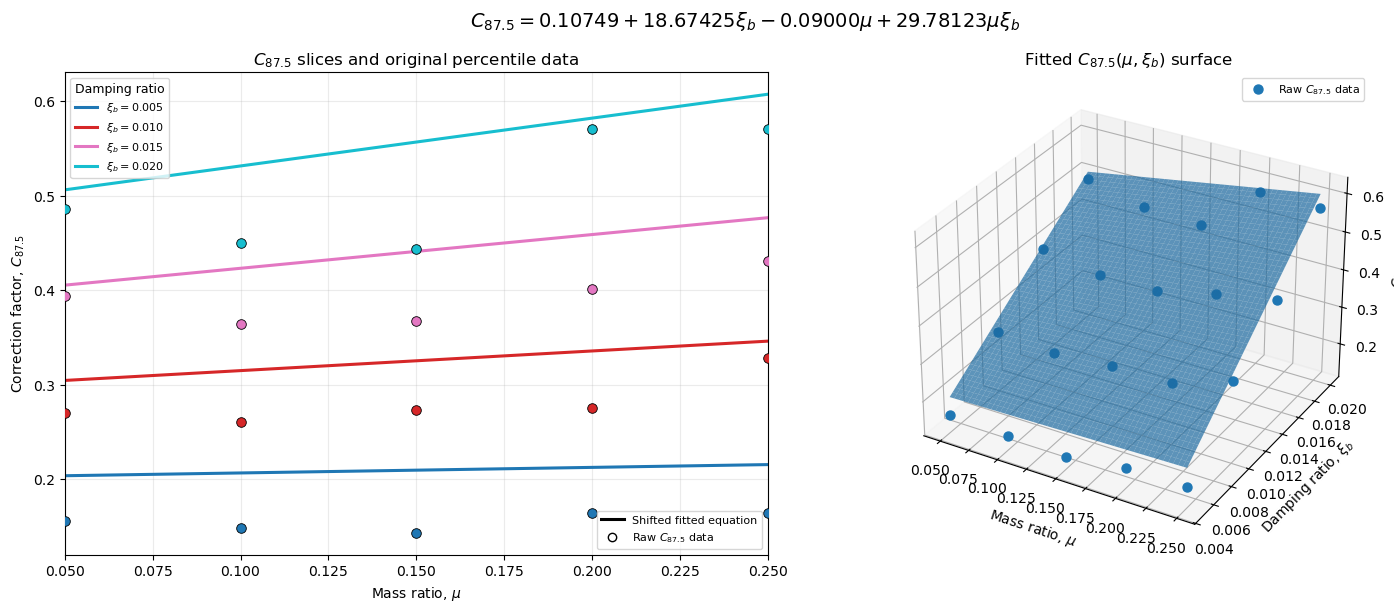



C87.5 TERM CONTRIBUTION RANGES

Domain:
0.050 <= mu <= 0.250
0.005 <= xi_b <= 0.020

       Expression      Range over domain  Max absolute contribution
         0.107486               0.107486                   0.107486
   18.674247 xi_b   0.093371 to 0.373485                   0.373485
     -0.090000 mu -0.022500 to -0.004500                   0.022500
29.781234 mu xi_b   0.007445 to 0.148906                   0.148906

Final C87.5 range:
0.203803 to 0.607377

VARIABLE TERMS — SMALLEST TO LARGEST

       Expression      Range over domain  Max absolute contribution
     -0.090000 mu -0.022500 to -0.004500                   0.022500
29.781234 mu xi_b   0.007445 to 0.148906                   0.148906
   18.674247 xi_b   0.093371 to 0.373485                   0.373485


C87.5 TERM-REMOVAL / MODEL-SIMPLIFICATION TEST

Each reduced equation is REFITTED to the original raw C87.5 data.

          Model      Terms retained  Number coefficients       R2  Delta R2 vs full     RMSE  Delta RMSE

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# SECOND LOAD MODEL
# SELECTED C87.5 EQUATION
# ============================================================
#
# Selected using:
#
# min | max(B_weighted) - 1 |
#
# Shifted fitted equation:
#
# C87.5 =
# 0.10748598
# + 18.67424706 xi_b
# - 0.08999979 mu
# + 29.78123377 mu xi_b
#
# Original OLS equation before +0.05:
#
# C87.5 =
# 0.05748598
# + 18.67424706 xi_b
# - 0.08999979 mu
# + 29.78123377 mu xi_b
#
# ============================================================

SELECTED_PERCENTILE = 87.5

B0 = 0.10748598
B_XI = 18.67424706
B_MU = -0.08999979
B_MU_XI = 29.78123377

SAFETY_SHIFT = 0.05


# ============================================================
# C87.5 FUNCTION
# ============================================================

def C87_5(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (
        B0
        + B_XI * xi
        + B_MU * mu
        + B_MU_XI * mu * xi
    )


# ============================================================
# DOMAIN USED IN POPULATION-BASED SECOND-MODEL FIT
# ============================================================
#
# NOTE:
#
# The population-weight grid used in the optimisation
# contains mu = 0.05 to 0.25.
#
# mu = 0.30 existed in the response data but was not in
# the final population-weight domain.
#
# Therefore use the calibrated domain here:
#
# 0.05 <= mu <= 0.25
# 0.005 <= xi_b <= 0.020
#
# ============================================================

MU_MIN = 0.05
MU_MAX = 0.25

XI_MIN = 0.005
XI_MAX = 0.020


MU_SLICES = np.array(
    [
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
    ]
)


XI_SLICES = np.array(
    [
        0.005,
        0.010,
        0.015,
        0.020,
    ]
)


# ============================================================
# 1. GET ORIGINAL RAW C87.5 DATA POINTS
# ============================================================
#
# Previous second-load-model optimisation created:
#
#     all_raw_cx_second
#
# containing:
#
# percentile
# mu_key
# xi_key
# C_raw
# C_fit
# C_fit_shifted
#
# ============================================================

if "all_raw_cx_second" not in globals():

    raise NameError(

        "all_raw_cx_second was not found.\n"
        "Run the second-load-model percentile-selection "
        "code first."

    )


raw875 = all_raw_cx_second[

    np.isclose(

        all_raw_cx_second[
            "percentile"
        ],

        SELECTED_PERCENTILE

    )

].copy()


required_columns = [

    "mu_key",
    "xi_key",
    "C_raw",

]


missing_columns = [

    col

    for col in required_columns

    if col not in raw875.columns

]


if missing_columns:

    raise KeyError(

        "Raw C87.5 table is missing columns:\n"

        f"{missing_columns}"

    )


for col in required_columns:

    raw875[col] = pd.to_numeric(

        raw875[col],

        errors="coerce"

    )


raw875 = raw875.dropna(

    subset=required_columns

).copy()


# ============================================================
# KEEP CALIBRATED DOMAIN
# ============================================================

raw875 = raw875[

    (
        raw875["mu_key"]
        >=
        MU_MIN
    )

    &

    (
        raw875["mu_key"]
        <=
        MU_MAX
    )

    &

    (
        raw875["xi_key"]
        >=
        XI_MIN
    )

    &

    (
        raw875["xi_key"]
        <=
        XI_MAX
    )

].copy()


raw875 = raw875.sort_values(

    [
        "xi_key",
        "mu_key",
    ]

)


if raw875.empty:

    raise ValueError(

        "No raw C87.5 points were found "
        "in the selected domain."

    )


print(
    "\n============================================================"
)

print(
    "RAW C87.5 DATA"
)

print(
    "============================================================"
)


print(

    raw875[

        [
            "mu_key",
            "xi_key",
            "C_raw",
        ]

    ].to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


print(

    f"\nNumber of raw C87.5 points = "
    f"{len(raw875)}"

)


# ============================================================
# 2. GRID FOR FITTED SURFACE
# ============================================================

mu_grid = np.linspace(
    MU_MIN,
    MU_MAX,
    250
)


xi_grid = np.linspace(
    XI_MIN,
    XI_MAX,
    250
)


MU, XI = np.meshgrid(
    mu_grid,
    xi_grid
)


C_SURFACE = C87_5(
    MU,
    XI
)


# ============================================================
# 3. COLOURS FOR DAMPING SLICES
# ============================================================

colors = plt.cm.tab10(

    np.linspace(

        0,
        1,
        len(XI_SLICES)

    )

)


xi_color = {

    xi:
        colors[i]

    for i, xi in enumerate(
        XI_SLICES
    )

}


# ============================================================
# ============================================================
#
# FIGURE
#
# LEFT:
# C87.5 slices + ORIGINAL RAW C87.5 POINTS
#
# RIGHT:
# fitted C87.5 surface + ORIGINAL RAW C87.5 POINTS
#
# ============================================================
# ============================================================

fig = plt.figure(
    figsize=(15, 6.2)
)


# ============================================================
# LEFT PANEL — SLICES
# ============================================================

ax1 = fig.add_subplot(
    1,
    2,
    1
)


for xi_value in XI_SLICES:


    # --------------------------------------------------------
    # FITTED C87.5 SLICE
    # --------------------------------------------------------

    fitted_values = C87_5(

        mu_grid,

        np.full_like(
            mu_grid,
            xi_value
        )

    )


    ax1.plot(

        mu_grid,

        fitted_values,

        color=
            xi_color[
                xi_value
            ],

        linewidth=2.2,

        label=
            rf"$\xi_b={xi_value:.3f}$"

    )


    # --------------------------------------------------------
    # RAW C87.5 DATA POINTS FOR THIS DAMPING
    # --------------------------------------------------------

    raw_slice = raw875[

        np.isclose(

            raw875[
                "xi_key"
            ],

            xi_value

        )

    ].copy()


    if not raw_slice.empty:


        ax1.scatter(

            raw_slice[
                "mu_key"
            ],

            raw_slice[
                "C_raw"
            ],

            color=
                xi_color[
                    xi_value
                ],

            marker="o",

            s=48,

            edgecolor="black",

            linewidth=0.6,

            zorder=5

        )


ax1.set_xlim(
    MU_MIN,
    MU_MAX
)


ax1.set_xlabel(
    r"Mass ratio, $\mu$"
)


ax1.set_ylabel(
    r"Correction factor, $C_{87.5}$"
)


ax1.set_title(

    r"$C_{87.5}$ slices and original percentile data"

)


ax1.grid(
    True,
    alpha=0.25
)


# ============================================================
# LEFT PANEL LEGENDS
# ============================================================

damping_handles = [

    Line2D(

        [0],
        [0],

        color=
            xi_color[
                xi_value
            ],

        linewidth=2.2,

        label=
            rf"$\xi_b={xi_value:.3f}$"

    )

    for xi_value in XI_SLICES

]


point_handle = Line2D(

    [0],
    [0],

    marker="o",

    color="black",

    linestyle="None",

    markerfacecolor="white",

    markeredgecolor="black",

    markersize=6,

    label=r"Raw $C_{87.5}$ data"

)


fit_handle = Line2D(

    [0],
    [0],

    color="black",

    linewidth=2.2,

    label="Shifted fitted equation"

)


legend1 = ax1.legend(

    handles=damping_handles,

    title="Damping ratio",

    loc="upper left",

    fontsize=8,

    title_fontsize=9

)


ax1.add_artist(
    legend1
)


ax1.legend(

    handles=[

        fit_handle,
        point_handle,

    ],

    loc="lower right",

    fontsize=8

)


# ============================================================
# RIGHT PANEL — 3D SURFACE
# ============================================================

ax2 = fig.add_subplot(

    1,
    2,
    2,

    projection="3d"

)


ax2.plot_surface(

    MU,
    XI,
    C_SURFACE,

    alpha=0.70,

    linewidth=0,

    antialiased=True

)


# ------------------------------------------------------------
# ORIGINAL RAW C87.5 DATA
# ------------------------------------------------------------

ax2.scatter(

    raw875[
        "mu_key"
    ],

    raw875[
        "xi_key"
    ],

    raw875[
        "C_raw"
    ],

    s=42,

    marker="o",

    depthshade=False,

    label=r"Raw $C_{87.5}$ data"

)


ax2.set_xlabel(
    r"Mass ratio, $\mu$"
)


ax2.set_ylabel(
    r"Damping ratio, $\xi_b$"
)


ax2.set_zlabel(
    r"$C_{87.5}$"
)


ax2.set_title(

    r"Fitted $C_{87.5}(\mu,\xi_b)$ surface"

)


ax2.legend(
    fontsize=8
)


fig.suptitle(

    r"$C_{87.5}=0.10749+18.67425\xi_b"
    r"-0.09000\mu+29.78123\mu\xi_b$",

    fontsize=14

)


plt.tight_layout()

plt.show()


# ============================================================
# 4. TERM CONTRIBUTION ANALYSIS
# ============================================================
#
# Same style as your earlier table:
#
# Expression
# Range over design domain
#
# This tells us which terms are potentially negligible.
#
# ============================================================

TERM_INTERCEPT = np.full_like(
    MU,
    B0
)


TERM_XI = (

    B_XI
    *
    XI

)


TERM_MU = (

    B_MU
    *
    MU

)


TERM_INTERACTION = (

    B_MU_XI
    *
    MU
    *
    XI

)


C_CHECK = (

    TERM_INTERCEPT
    +
    TERM_XI
    +
    TERM_MU
    +
    TERM_INTERACTION

)


if not np.allclose(
    C_SURFACE,
    C_CHECK
):

    raise ValueError(

        "Term decomposition does not reproduce C87.5."

    )


# ============================================================
# 5. RANGE-FORMATTING FUNCTION
# ============================================================

def range_string(
    values
):

    minimum = float(
        np.min(values)
    )

    maximum = float(
        np.max(values)
    )


    if np.isclose(
        minimum,
        maximum
    ):

        return (
            f"{minimum:.6f}"
        )


    return (

        f"{minimum:.6f} "
        f"to "
        f"{maximum:.6f}"

    )


# ============================================================
# 6. TERM-RANGE TABLE
# ============================================================

term_range_df = pd.DataFrame(

    [

        {

            "Expression":
                f"{B0:.6f}",

            "Range over domain":
                range_string(
                    TERM_INTERCEPT
                ),

            "Minimum":
                np.min(
                    TERM_INTERCEPT
                ),

            "Maximum":
                np.max(
                    TERM_INTERCEPT
                ),

            "Max absolute contribution":
                np.max(
                    np.abs(
                        TERM_INTERCEPT
                    )
                ),

        },

        {

            "Expression":
                f"{B_XI:.6f} xi_b",

            "Range over domain":
                range_string(
                    TERM_XI
                ),

            "Minimum":
                np.min(
                    TERM_XI
                ),

            "Maximum":
                np.max(
                    TERM_XI
                ),

            "Max absolute contribution":
                np.max(
                    np.abs(
                        TERM_XI
                    )
                ),

        },

        {

            "Expression":
                f"{B_MU:.6f} mu",

            "Range over domain":
                range_string(
                    TERM_MU
                ),

            "Minimum":
                np.min(
                    TERM_MU
                ),

            "Maximum":
                np.max(
                    TERM_MU
                ),

            "Max absolute contribution":
                np.max(
                    np.abs(
                        TERM_MU
                    )
                ),

        },

        {

            "Expression":
                f"{B_MU_XI:.6f} mu xi_b",

            "Range over domain":
                range_string(
                    TERM_INTERACTION
                ),

            "Minimum":
                np.min(
                    TERM_INTERACTION
                ),

            "Maximum":
                np.max(
                    TERM_INTERACTION
                ),

            "Max absolute contribution":
                np.max(
                    np.abs(
                        TERM_INTERACTION
                    )
                ),

        },

    ]

)


print(
    "\n\n============================================================"
)

print(
    "C87.5 TERM CONTRIBUTION RANGES"
)

print(
    "============================================================"
)


print(

    f"\nDomain:\n"
    f"{MU_MIN:.3f} <= mu <= {MU_MAX:.3f}\n"
    f"{XI_MIN:.3f} <= xi_b <= {XI_MAX:.3f}\n"

)


print(

    term_range_df[

        [
            "Expression",
            "Range over domain",
            "Max absolute contribution",
        ]

    ].to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


print(
    "\nFinal C87.5 range:"
)


print(

    f"{np.min(C_SURFACE):.6f} "
    f"to "
    f"{np.max(C_SURFACE):.6f}"

)


# ============================================================
# 7. RANK VARIABLE TERMS BY MAXIMUM CONTRIBUTION
# ============================================================

variable_term_df = (

    term_range_df.iloc[
        1:
    ]

    .sort_values(

        "Max absolute contribution",

        ascending=True

    )

    .reset_index(
        drop=True
    )

)


print(
    "\n============================================================"
)

print(
    "VARIABLE TERMS — SMALLEST TO LARGEST"
)

print(
    "============================================================\n"
)


print(

    variable_term_df[

        [
            "Expression",
            "Range over domain",
            "Max absolute contribution",
        ]

    ].to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


# ============================================================
# 8. ACTUALLY TEST TERM REMOVAL
# ============================================================
#
# Fit to ORIGINAL RAW C87.5 values:
#
# FULL:
#
#     1 + xi + mu + mu*xi
#
# NO INTERACTION:
#
#     1 + xi + mu
#
# NO MU:
#
#     1 + xi + mu*xi
#
# NO XI:
#
#     1 + mu + mu*xi
#
# Also test the very simple:
#
#     1 + xi + mu*xi
#
# which is effectively the "No mu main term" model.
#
# ============================================================

mu_data = raw875[
    "mu_key"
].to_numpy(
    dtype=float
)


xi_data = raw875[
    "xi_key"
].to_numpy(
    dtype=float
)


y_data = raw875[
    "C_raw"
].to_numpy(
    dtype=float
)


# ============================================================
# MODEL MATRIX
# ============================================================

def build_model_matrix(
    mu,
    xi,
    terms_to_keep
):

    columns = []


    for term in terms_to_keep:


        if term == "1":

            columns.append(
                np.ones_like(mu)
            )


        elif term == "xi":

            columns.append(
                xi
            )


        elif term == "mu":

            columns.append(
                mu
            )


        elif term == "mu_xi":

            columns.append(
                mu * xi
            )


        else:

            raise ValueError(

                f"Unknown term: "
                f"{term}"

            )


    return np.column_stack(
        columns
    )


# ============================================================
# CANDIDATE SIMPLIFICATIONS
# ============================================================

candidate_models = {


    "Full":

        [
            "1",
            "xi",
            "mu",
            "mu_xi",
        ],


    "No interaction":

        [
            "1",
            "xi",
            "mu",
        ],


    "No mu main term":

        [
            "1",
            "xi",
            "mu_xi",
        ],


    "No xi main term":

        [
            "1",
            "mu",
            "mu_xi",
        ],


    "Only xi":

        [
            "1",
            "xi",
        ],


    "Only mu":

        [
            "1",
            "mu",
        ],

}


# ============================================================
# STATISTICS FUNCTIONS
# ============================================================

def calculate_r2(
    observed,
    predicted
):

    observed = np.asarray(
        observed,
        dtype=float
    )


    predicted = np.asarray(
        predicted,
        dtype=float
    )


    ss_res = np.sum(

        (
            observed
            -
            predicted
        ) ** 2

    )


    ss_tot = np.sum(

        (
            observed
            -
            np.mean(
                observed
            )
        ) ** 2

    )


    if ss_tot <= 0:

        return np.nan


    return (

        1.0

        -

        ss_res
        /
        ss_tot

    )


def calculate_rmse(
    observed,
    predicted
):

    return float(

        np.sqrt(

            np.mean(

                (

                    np.asarray(
                        observed
                    )

                    -

                    np.asarray(
                        predicted
                    )

                ) ** 2

            )

        )

    )


def calculate_mae(
    observed,
    predicted
):

    return float(

        np.mean(

            np.abs(

                np.asarray(
                    observed
                )

                -

                np.asarray(
                    predicted
                )

            )

        )

    )


def calculate_max_abs_error(
    observed,
    predicted
):

    return float(

        np.max(

            np.abs(

                np.asarray(
                    observed
                )

                -

                np.asarray(
                    predicted
                )

            )

        )

    )


# ============================================================
# 9. FIT FULL + REDUCED MODELS
# ============================================================

model_results = {}


for model_name, terms_to_keep in candidate_models.items():


    X = build_model_matrix(

        mu_data,

        xi_data,

        terms_to_keep

    )


    beta, *_ = np.linalg.lstsq(

        X,

        y_data,

        rcond=None

    )


    prediction = (

        X
        @
        beta

    )


    model_results[
        model_name
    ] = {

        "terms":
            terms_to_keep,

        "beta":
            beta,

        "prediction":
            prediction,

        "R2":
            calculate_r2(
                y_data,
                prediction
            ),

        "RMSE":
            calculate_rmse(
                y_data,
                prediction
            ),

        "MAE":
            calculate_mae(
                y_data,
                prediction
            ),

        "Max_abs_error":
            calculate_max_abs_error(
                y_data,
                prediction
            ),

    }


# ============================================================
# 10. COMPARE AGAINST FULL MODEL
# ============================================================

full_rmse = (
    model_results[
        "Full"
    ][
        "RMSE"
    ]
)


full_r2 = (
    model_results[
        "Full"
    ][
        "R2"
    ]
)


reduction_rows = []


for model_name, result in model_results.items():


    delta_rmse = (

        result[
            "RMSE"
        ]

        -

        full_rmse

    )


    if full_rmse > 0:

        rmse_increase_percent = (

            100.0

            *
            delta_rmse

            /
            full_rmse

        )

    else:

        rmse_increase_percent = np.nan


    reduction_rows.append(

        {

            "Model":
                model_name,

            "Terms retained":
                " + ".join(
                    result[
                        "terms"
                    ]
                ),

            "Number coefficients":
                len(
                    result[
                        "beta"
                    ]
                ),

            "R2":
                result[
                    "R2"
                ],

            "Delta R2 vs full":
                result[
                    "R2"
                ]
                -
                full_r2,

            "RMSE":
                result[
                    "RMSE"
                ],

            "Delta RMSE vs full":
                delta_rmse,

            "RMSE increase [%]":
                rmse_increase_percent,

            "MAE":
                result[
                    "MAE"
                ],

            "Max absolute error":
                result[
                    "Max_abs_error"
                ],

        }

    )


reduction_df = pd.DataFrame(
    reduction_rows
)


print(
    "\n\n============================================================"
)

print(
    "C87.5 TERM-REMOVAL / MODEL-SIMPLIFICATION TEST"
)

print(
    "============================================================"
)


print(

    "\nEach reduced equation is REFITTED "
    "to the original raw C87.5 data.\n"

)


print(

    reduction_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"

    )

)


# ============================================================
# 11. EQUATION FORMATTER
# ============================================================

def format_equation(
    terms,
    beta
):

    pieces = []


    for term, coefficient in zip(
        terms,
        beta
    ):


        if term == "1":

            pieces.append(

                f"{coefficient:.8f}"

            )


        elif term == "xi":

            pieces.append(

                f"{coefficient:+.8f} xi_b"

            )


        elif term == "mu":

            pieces.append(

                f"{coefficient:+.8f} mu"

            )


        elif term == "mu_xi":

            pieces.append(

                f"{coefficient:+.8f} mu*xi_b"

            )


    return " ".join(
        pieces
    )


# ============================================================
# 12. PRINT REFITTED EQUATIONS BEFORE SAFETY SHIFT
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "REFITTED C87.5 EQUATIONS BEFORE +0.05 SAFETY SHIFT"
)

print(
    "============================================================"
)


for model_name, result in model_results.items():


    print(
        f"\n{model_name}:"
    )


    print(

        "C87.5 = "

        +

        format_equation(

            result[
                "terms"
            ],

            result[
                "beta"
            ]

        )

    )


# ============================================================
# 13. PRINT REFITTED EQUATIONS AFTER +0.05 SHIFT
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "REFITTED C87.5 EQUATIONS AFTER +0.05 INTERCEPT SHIFT"
)

print(
    "============================================================"
)


shifted_model_results = {}


for model_name, result in model_results.items():


    shifted_beta = (

        result[
            "beta"
        ]

        .copy()

    )


    # Intercept is first coefficient

    shifted_beta[0] += (
        SAFETY_SHIFT
    )


    shifted_model_results[
        model_name
    ] = {

        "terms":
            result[
                "terms"
            ],

        "beta":
            shifted_beta,

    }


    print(
        f"\n{model_name}:"
    )


    print(

        "C87.5_shifted = "

        +

        format_equation(

            result[
                "terms"
            ],

            shifted_beta

        )

    )


# ============================================================
# 14. SAVE TABLES
# ============================================================

term_range_df.to_csv(

    "second_C87_5_term_range_table.csv",

    index=False,

    encoding="utf-8-sig"

)


reduction_df.to_csv(

    "second_C87_5_term_removal_test.csv",

    index=False,

    encoding="utf-8-sig"

)


raw875.to_csv(

    "second_C87_5_raw_points.csv",

    index=False,

    encoding="utf-8-sig"

)


print(
    "\nSaved:"
)


print(
    "second_C87_5_term_range_table.csv"
)


print(
    "second_C87_5_term_removal_test.csv"
)


print(
    "second_C87_5_raw_points.csv"
)


SECOND LOAD MODEL POPULATION WEIGHTS
Original probability mass retained = 0.76010354
Renormalised weight sum = 1.000000000000
Weighted mass ratios: [0.05 0.1  0.15 0.2  0.25]
Weighted damping ratios: [0.005 0.01  0.015 0.02 ]

SECOND LOAD MODEL — WEIGHTED PEAK BIAS
Current code                   peak = 0.807183 at 2.250 Hz, gap to 1 = 0.192817
New psi                        peak = 0.315869 at 2.750 Hz, gap to 1 = 0.684131
New psi + exact C87.5          peak = 1.020231 at 2.750 Hz, gap to 1 = 0.020231
New psi + rounded C87.5        peak = 1.044019 at 2.750 Hz, gap to 1 = 0.044019

EXACT vs ROUNDED C87.5
Exact equation:
C87.5 = 0.10748598 + 18.67424706 xi_b - 0.08999979 mu + 29.78123377 mu xi_b

Rounded equation:
C87.5 = 0.10 + 19 xi_b - 0.10 mu + 30 mu xi_b

Maximum absolute difference in C = 0.008529
Maximum relative difference in C = 3.903%


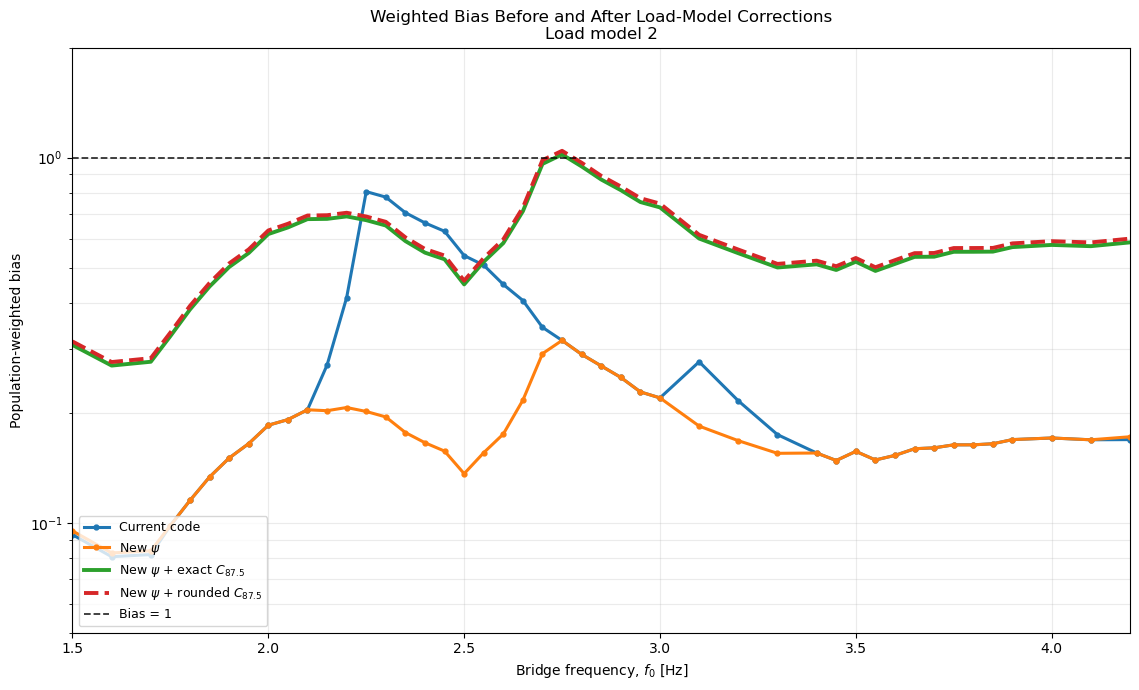

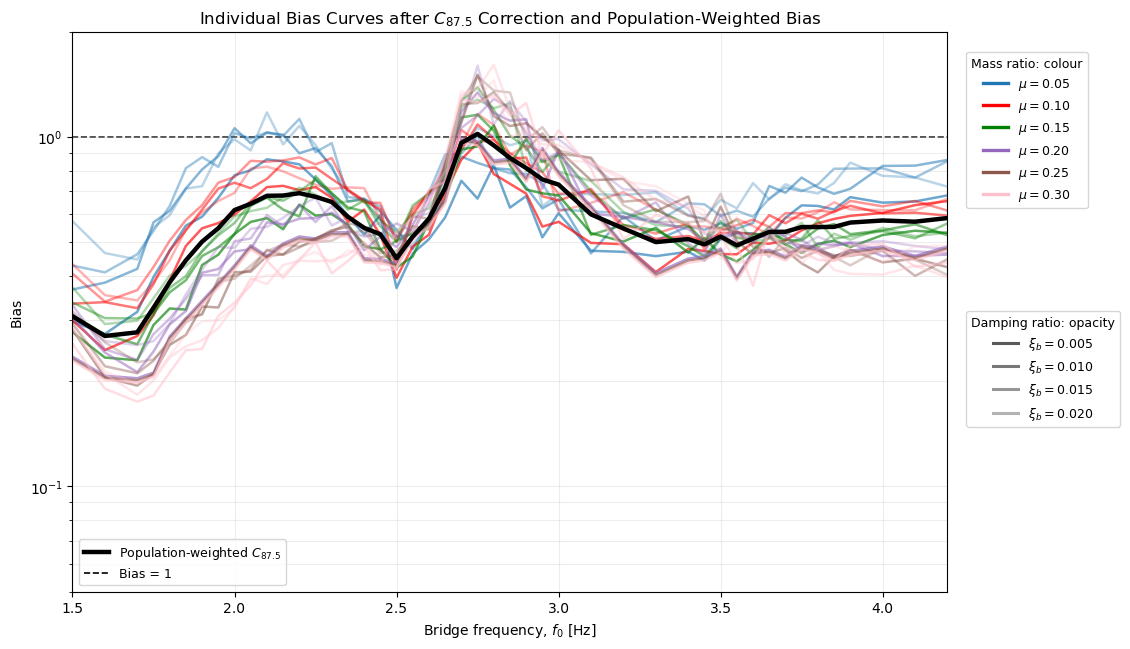


Saved:
second_C87_5_exact_vs_rounded_population_weighted_bias.csv
second_C87_5_exact_vs_rounded_individual_bias.csv


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# SECOND LOAD MODEL
#
# C87.5 EXACT AND ROUNDED EQUATIONS
# ============================================================
#
# IMPORTANT:
# These are the +0.05 shifted equations.
#
# EXACT:
#
# C87.5 =
# 0.10748598
# + 18.67424706 xi_b
# - 0.08999979 mu
# + 29.78123377 mu xi_b
#
# ROUNDED:
#
# C87.5 =
# 0.10
# + 19 xi_b
# - 0.10 mu
# + 30 mu xi_b
#
# Bias after correction:
#
# B_final = B_after_new_psi / C
#
# ============================================================


# ============================================================
# 1. SETTINGS
# ============================================================

F_MIN = 1.50
F_MAX = 4.20


# ------------------------------------------------------------
# Exact C87.5
# ------------------------------------------------------------

B0_EXACT = 0.10748598
B_XI_EXACT = 18.67424706
B_MU_EXACT = -0.08999979
B_MUXI_EXACT = 29.78123377


# ------------------------------------------------------------
# Rounded C87.5
# ------------------------------------------------------------

B0_ROUND = 0.10
B_XI_ROUND = 19.0
B_MU_ROUND = -0.10
B_MUXI_ROUND = 30.0


# ------------------------------------------------------------
# Second-load-model damping grid
# ------------------------------------------------------------

SECOND_XI_VALUES = [
    0.005,
    0.010,
    0.015,
    0.020,
]


# ------------------------------------------------------------
# Response grid shown in individual-curve figure
# ------------------------------------------------------------

SECOND_MU_VALUES = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
]


# Numerical matching
MU_KEY_DECIMALS = 4
XI_KEY_DECIMALS = 4
FREQ_KEY_DECIMALS = 6


# ============================================================
# 2. SPECIAL SECOND-LOAD-MODEL REPEAT RULE
# ============================================================
#
# Same rule used during the second-load-model optimisation:
#
# Response from:
#
#   mu = 0.20, xi_b = 0.005
#
# is repeated for:
#
#   mu = 0.25, xi_b = 0.005
#   mu = 0.30, xi_b = 0.005
#
# ============================================================

REPEAT_SOURCE_MU = 0.20
REPEAT_SOURCE_XI = 0.005

REPEAT_TARGETS = [
    (0.25, 0.005),
    (0.30, 0.005),
]


# ============================================================
# 3. C87.5 FUNCTIONS
# ============================================================

def C87_exact(mu, xi):

    mu = np.asarray(mu, dtype=float)
    xi = np.asarray(xi, dtype=float)

    return (
        B0_EXACT
        + B_XI_EXACT * xi
        + B_MU_EXACT * mu
        + B_MUXI_EXACT * mu * xi
    )


def C87_rounded(mu, xi):

    mu = np.asarray(mu, dtype=float)
    xi = np.asarray(xi, dtype=float)

    return (
        B0_ROUND
        + B_XI_ROUND * xi
        + B_MU_ROUND * mu
        + B_MUXI_ROUND * mu * xi
    )


# ============================================================
# 4. CHECK REQUIRED DATA
# ============================================================

if "compare_df" not in globals():

    raise NameError(
        "compare_df was not found.\n"
        "Run the second-load-model new-psi code first."
    )


if "weights_df" not in globals():

    raise NameError(
        "weights_df was not found.\n"
        "Run the population-weight calculation first."
    )


required_bias_columns = [
    "bridge_frequency",
    "mass_ratio",
    "old_bias",
    "env_bias",
]


missing = [
    col
    for col in required_bias_columns
    if col not in compare_df.columns
]


if missing:

    raise KeyError(
        "compare_df is missing:\n"
        f"{missing}"
    )


required_weight_columns = [
    "mu",
    "xi_b",
    "weight",
]


missing = [
    col
    for col in required_weight_columns
    if col not in weights_df.columns
]


if missing:

    raise KeyError(
        "weights_df is missing:\n"
        f"{missing}"
    )


# ============================================================
# 5. PREPARE SECOND-LOAD-MODEL RESPONSE DATA
# ============================================================

df = compare_df.copy()


# ------------------------------------------------------------
# Create target_beamdamp if needed
# ------------------------------------------------------------

if "target_beamdamp" not in df.columns:

    if "damping_key" not in df.columns:

        raise KeyError(
            "Neither target_beamdamp nor damping_key exists."
        )

    df["target_beamdamp"] = pd.to_numeric(
        df["damping_key"],
        errors="coerce"
    )


for col in [
    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",
    "old_bias",
    "env_bias",
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=[
        "bridge_frequency",
        "mass_ratio",
        "target_beamdamp",
        "old_bias",
        "env_bias",
    ]
).copy()


df = df[
    (df["bridge_frequency"] >= F_MIN)
    &
    (df["bridge_frequency"] <= F_MAX)
].copy()


# ============================================================
# 6. KEEP SECOND-LOAD-MODEL GRID
# ============================================================

mu_mask = np.zeros(
    len(df),
    dtype=bool
)

for mu_value in SECOND_MU_VALUES:

    mu_mask |= np.isclose(
        df["mass_ratio"],
        mu_value
    )


xi_mask = np.zeros(
    len(df),
    dtype=bool
)

for xi_value in SECOND_XI_VALUES:

    xi_mask |= np.isclose(
        df["target_beamdamp"],
        xi_value
    )


df = df[
    mu_mask
    &
    xi_mask
].copy()


if df.empty:

    raise ValueError(
        "No second-load-model response data remain."
    )


# ============================================================
# 7. COLLAPSE DUPLICATE LINEAR-MASS REPRESENTATIONS
# ============================================================
#
# Multiple lm values may represent the same mu.
#
# We need one response for:
#
# mu, xi_b, bridge_frequency
#
# ============================================================

df = (
    df
    .groupby(
        [
            "mass_ratio",
            "target_beamdamp",
            "bridge_frequency",
        ],
        as_index=False
    )
    .agg(
        old_bias=("old_bias", "mean"),
        env_bias=("env_bias", "mean"),
    )
)


# ============================================================
# 8. APPLY SPECIAL REPEAT RULE
# ============================================================

repeat_parts = []


for target_mu, target_xi in REPEAT_TARGETS:

    source = df[
        np.isclose(
            df["mass_ratio"],
            REPEAT_SOURCE_MU
        )
        &
        np.isclose(
            df["target_beamdamp"],
            REPEAT_SOURCE_XI
        )
    ].copy()


    if source.empty:

        raise ValueError(
            "Repeat-source response was not found."
        )


    source["mass_ratio"] = target_mu
    source["target_beamdamp"] = target_xi

    repeat_parts.append(
        source
    )


# Remove existing repeated target responses

remove_mask = np.zeros(
    len(df),
    dtype=bool
)


for target_mu, target_xi in REPEAT_TARGETS:

    remove_mask |= (
        np.isclose(
            df["mass_ratio"],
            target_mu
        )
        &
        np.isclose(
            df["target_beamdamp"],
            target_xi
        )
    )


df = df[
    ~remove_mask
].copy()


df = pd.concat(
    [
        df,
        *repeat_parts,
    ],
    ignore_index=True
)


# ============================================================
# 9. CALCULATE EXACT AND ROUNDED C87.5
# ============================================================

mu = df[
    "mass_ratio"
].to_numpy(
    dtype=float
)


xi = df[
    "target_beamdamp"
].to_numpy(
    dtype=float
)


df["C87_exact"] = C87_exact(
    mu,
    xi
)


df["C87_rounded"] = C87_rounded(
    mu,
    xi
)


# ============================================================
# 10. RECALCULATE BIAS
# ============================================================
#
# env_bias = bias after new psi
#
# B_after_C =
# env_bias / C
#
# ============================================================

df["bias_C87_exact"] = (
    df["env_bias"]
    /
    df["C87_exact"]
)


df["bias_C87_rounded"] = (
    df["env_bias"]
    /
    df["C87_rounded"]
)


# ============================================================
# 11. CREATE KEYS
# ============================================================

df["mu_key"] = (
    df["mass_ratio"]
    .round(MU_KEY_DECIMALS)
)


df["xi_key"] = (
    df["target_beamdamp"]
    .round(XI_KEY_DECIMALS)
)


df["f_key"] = (
    df["bridge_frequency"]
    .round(FREQ_KEY_DECIMALS)
)


# ============================================================
# 12. PREPARE POPULATION WEIGHTS
# ============================================================

W_full = weights_df[
    [
        "mu",
        "xi_b",
        "weight",
    ]
].copy()


for col in [
    "mu",
    "xi_b",
    "weight",
]:

    W_full[col] = pd.to_numeric(
        W_full[col],
        errors="coerce"
    )


W_full = W_full.dropna().copy()


# ============================================================
# 13. RESTRICT WEIGHTS TO SECOND-MODEL DOMAIN
# ============================================================
#
# Same procedure used in optimisation:
#
# keep the existing probabilities that overlap the
# second-load-model grid, then renormalise.
#
# ============================================================

mu_weight_mask = np.zeros(
    len(W_full),
    dtype=bool
)


for mu_value in SECOND_MU_VALUES:

    mu_weight_mask |= np.isclose(
        W_full["mu"],
        mu_value
    )


xi_weight_mask = np.zeros(
    len(W_full),
    dtype=bool
)


for xi_value in SECOND_XI_VALUES:

    xi_weight_mask |= np.isclose(
        W_full["xi_b"],
        xi_value
    )


W = W_full[
    mu_weight_mask
    &
    xi_weight_mask
].copy()


if W.empty:

    raise ValueError(
        "No population weights overlap second-model grid."
    )


weight_mass_retained = (
    W["weight"].sum()
)


W["weight_original"] = (
    W["weight"]
)


W["weight"] = (
    W["weight"]
    /
    weight_mass_retained
)


W["mu_key"] = (
    W["mu"]
    .round(MU_KEY_DECIMALS)
)


W["xi_key"] = (
    W["xi_b"]
    .round(XI_KEY_DECIMALS)
)


print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL POPULATION WEIGHTS"
)

print(
    "============================================================"
)


print(
    f"Original probability mass retained = "
    f"{weight_mass_retained:.8f}"
)


print(
    f"Renormalised weight sum = "
    f"{W['weight'].sum():.12f}"
)


print(
    "Weighted mass ratios:",
    np.sort(
        W["mu"].unique()
    )
)


print(
    "Weighted damping ratios:",
    np.sort(
        W["xi_b"].unique()
    )
)


# ============================================================
# 14. BUILD WEIGHTED DATAFRAME
# ============================================================

weighted_df_second = df.merge(

    W[
        [
            "mu_key",
            "xi_key",
            "weight",
        ]
    ],

    on=[
        "mu_key",
        "xi_key",
    ],

    how="inner",

    validate="many_to_one"

)


if weighted_df_second.empty:

    raise ValueError(
        "No overlap between response data and population weights."
    )


# ============================================================
# 15. CHECK COMPLETE POPULATION GRID BY FREQUENCY
# ============================================================

coverage = (

    weighted_df_second

    .groupby(
        "f_key"
    )

    .agg(

        weight_sum=(
            "weight",
            "sum"
        ),

        n_cells=(
            "weight",
            "size"
        ),

    )

    .reset_index()

)


good_frequencies = coverage[

    np.isclose(
        coverage["weight_sum"],
        1.0,
        atol=1e-8
    )

    &

    (
        coverage["n_cells"]
        ==
        len(W)
    )

]["f_key"]


weighted_df_second = weighted_df_second[
    weighted_df_second[
        "f_key"
    ].isin(
        good_frequencies
    )
].copy()


if weighted_df_second.empty:

    raise ValueError(
        "No complete population-weighted frequency points remain."
    )


# ============================================================
# 16. WEIGHT ALL FOUR MODEL RESULTS
# ============================================================

weighted_df_second["w_current"] = (
    weighted_df_second["weight"]
    *
    weighted_df_second["old_bias"]
)


weighted_df_second["w_newpsi"] = (
    weighted_df_second["weight"]
    *
    weighted_df_second["env_bias"]
)


weighted_df_second["w_C87_exact"] = (
    weighted_df_second["weight"]
    *
    weighted_df_second["bias_C87_exact"]
)


weighted_df_second["w_C87_rounded"] = (
    weighted_df_second["weight"]
    *
    weighted_df_second["bias_C87_rounded"]
)


# ============================================================
# 17. CREATE FOUR POPULATION-WEIGHTED LINES
# ============================================================

weighted_lines_second = (

    weighted_df_second

    .groupby(
        "f_key",
        as_index=False
    )

    .agg(

        bridge_frequency=(
            "bridge_frequency",
            "mean"
        ),

        B_current=(
            "w_current",
            "sum"
        ),

        B_newpsi=(
            "w_newpsi",
            "sum"
        ),

        B_C87_exact=(
            "w_C87_exact",
            "sum"
        ),

        B_C87_rounded=(
            "w_C87_rounded",
            "sum"
        ),

        weight_sum=(
            "weight",
            "sum"
        ),

    )

    .sort_values(
        "bridge_frequency"
    )

)


# ============================================================
# 18. PRINT WEIGHTED PEAK RESULTS
# ============================================================

print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — WEIGHTED PEAK BIAS"
)

print(
    "============================================================"
)


for column, label in [

    (
        "B_current",
        "Current code"
    ),

    (
        "B_newpsi",
        "New psi"
    ),

    (
        "B_C87_exact",
        "New psi + exact C87.5"
    ),

    (
        "B_C87_rounded",
        "New psi + rounded C87.5"
    ),

]:

    idx = (
        weighted_lines_second[
            column
        ]
        .idxmax()
    )


    peak = float(

        weighted_lines_second.loc[
            idx,
            column
        ]

    )


    f_peak = float(

        weighted_lines_second.loc[
            idx,
            "bridge_frequency"
        ]

    )


    print(

        f"{label:31s}"
        f"peak = {peak:.6f} "
        f"at {f_peak:.3f} Hz, "
        f"gap to 1 = {abs(1.0-peak):.6f}"

    )


# ============================================================
# 19. EXACT vs ROUNDED C87.5 DIFFERENCE
# ============================================================

mu_check = np.linspace(
    0.05,
    0.30,
    300
)


xi_check = np.linspace(
    0.005,
    0.020,
    300
)


MU_CHECK, XI_CHECK = np.meshgrid(
    mu_check,
    xi_check
)


C_exact_check = C87_exact(
    MU_CHECK,
    XI_CHECK
)


C_round_check = C87_rounded(
    MU_CHECK,
    XI_CHECK
)


absolute_difference = np.abs(
    C_round_check
    -
    C_exact_check
)


relative_difference = (
    100.0
    *
    absolute_difference
    /
    np.abs(
        C_exact_check
    )
)


print(
    "\n============================================================"
)

print(
    "EXACT vs ROUNDED C87.5"
)

print(
    "============================================================"
)


print(
    "Exact equation:"
)


print(
    "C87.5 = "
    "0.10748598 "
    "+ 18.67424706 xi_b "
    "- 0.08999979 mu "
    "+ 29.78123377 mu xi_b"
)


print(
    "\nRounded equation:"
)


print(
    "C87.5 = "
    "0.10 "
    "+ 19 xi_b "
    "- 0.10 mu "
    "+ 30 mu xi_b"
)


print(
    "\nMaximum absolute difference in C = "
    f"{absolute_difference.max():.6f}"
)


print(
    "Maximum relative difference in C = "
    f"{relative_difference.max():.3f}%"
)


# ============================================================
# ============================================================
#
# FIGURE 1
#
# CURRENT CODE
# vs
# NEW psi
# vs
# NEW psi + EXACT C87.5
# vs
# NEW psi + ROUNDED C87.5
#
# ============================================================
# ============================================================

fig, ax = plt.subplots(
    figsize=(11.5, 7)
)


# ------------------------------------------------------------
# Current code
# ------------------------------------------------------------

ax.plot(

    weighted_lines_second[
        "bridge_frequency"
    ],

    weighted_lines_second[
        "B_current"
    ],

    marker="o",
    markersize=3.5,
    linewidth=2.2,

    label="Current code"

)


# ------------------------------------------------------------
# New psi
# ------------------------------------------------------------

ax.plot(

    weighted_lines_second[
        "bridge_frequency"
    ],

    weighted_lines_second[
        "B_newpsi"
    ],

    marker="o",
    markersize=3.5,
    linewidth=2.2,

    label=r"New $\psi$"

)


# ------------------------------------------------------------
# Exact C87.5
# ------------------------------------------------------------

ax.plot(

    weighted_lines_second[
        "bridge_frequency"
    ],

    weighted_lines_second[
        "B_C87_exact"
    ],

    linewidth=2.8,

    label=
        r"New $\psi$ + exact $C_{87.5}$"

)


# ------------------------------------------------------------
# Rounded C87.5
# ------------------------------------------------------------

ax.plot(

    weighted_lines_second[
        "bridge_frequency"
    ],

    weighted_lines_second[
        "B_C87_rounded"
    ],

    linewidth=2.8,

    linestyle="--",

    label=
        r"New $\psi$ + rounded $C_{87.5}$"

)


# ------------------------------------------------------------
# Bias = 1
# ------------------------------------------------------------

ax.axhline(

    1.0,

    color="black",

    linestyle="--",

    linewidth=1.3,

    alpha=0.8,

    label="Bias = 1"

)


ax.set_xlim(
    F_MIN,
    F_MAX
)


ax.set_yscale(
    "log"
)


ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    "Population-weighted bias"
)


ax.set_title(

    "Weighted Bias Before and After Load-Model Corrections\n"

    r"Load model 2"

)


ax.grid(
    True,
    which="both",
    alpha=0.25
)


ax.legend(
    loc="lower left",
    fontsize=9
)


plt.tight_layout()

plt.show()


# ============================================================
# ============================================================
#
# FIGURE 2
#
# ALL INDIVIDUAL BIAS CURVES
# AFTER EXACT C87.5
#
# BLACK =
# POPULATION-WEIGHTED EXACT C87.5 LINE
#
# ============================================================
# ============================================================


# ============================================================
# MASS RATIO COLOURS
# ============================================================

preferred_colors = {

    0.05: "tab:blue",

    0.10: "red",

    0.15: "green",

    0.20: "tab:purple",

    0.25: "tab:brown",

    0.30: "pink",

}


# ============================================================
# DAMPING OPACITY
# ============================================================

alpha_values = np.linspace(
    0.65,
    0.30,
    len(SECOND_XI_VALUES)
)


xi_alpha = {

    xi_value:
        alpha_values[i]

    for i, xi_value in enumerate(
        SECOND_XI_VALUES
    )

}


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12.5, 7)
)


fig.subplots_adjust(
    left=0.08,
    right=0.78,
    bottom=0.12,
    top=0.92
)


# ============================================================
# INDIVIDUAL EXACT C87.5 CURVES
# ============================================================

for mu_value in SECOND_MU_VALUES:

    for xi_value in SECOND_XI_VALUES:


        sub = df[

            np.isclose(
                df["mass_ratio"],
                mu_value
            )

            &

            np.isclose(
                df["target_beamdamp"],
                xi_value
            )

        ].copy()


        if sub.empty:

            continue


        sub = sub.sort_values(
            "bridge_frequency"
        )


        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_C87_exact"
            ],

            color=
                preferred_colors[
                    mu_value
                ],

            alpha=
                xi_alpha[
                    xi_value
                ],

            linewidth=1.8,

            zorder=2

        )


# ============================================================
# BLACK POPULATION-WEIGHTED C87.5 LINE
# ============================================================

ax.plot(

    weighted_lines_second[
        "bridge_frequency"
    ],

    weighted_lines_second[
        "B_C87_exact"
    ],

    color="black",

    linewidth=3.2,

    zorder=10,

    label=
        r"Population-weighted $C_{87.5}$"

)


# ============================================================
# BIAS = 1
# ============================================================

ax.axhline(

    1.0,

    color="black",

    linestyle="--",

    linewidth=1.2,

    alpha=0.8,

    zorder=1

)


# ============================================================
# AXES
# ============================================================

ax.set_xlim(
    F_MIN,
    F_MAX
)


ax.set_yscale(
    "log"
)


ax.set_ylim(
    0.05,
    2.0
)


ax.set_xlabel(
    r"Bridge frequency, $f_0$ [Hz]"
)


ax.set_ylabel(
    "Bias"
)


ax.set_title(

    r"Individual Bias Curves after $C_{87.5}$ Correction "
    "and Population-Weighted Bias"

)


ax.grid(
    True,
    which="both",
    alpha=0.22
)


# ============================================================
# MASS-RATIO LEGEND
# ============================================================

mu_handles = [

    Line2D(

        [0],
        [0],

        color=
            preferred_colors[
                mu_value
            ],

        linewidth=2.4,

        label=
            rf"$\mu={mu_value:.2f}$"

    )

    for mu_value in SECOND_MU_VALUES

]


fig.legend(

    handles=mu_handles,

    title="Mass ratio: colour",

    loc="upper left",

    bbox_to_anchor=(
        0.79,
        0.90
    ),

    frameon=True,

    fontsize=9,

    title_fontsize=9

)


# ============================================================
# DAMPING LEGEND
# ============================================================

xi_handles = [

    Line2D(

        [0],
        [0],

        color="black",

        alpha=
            xi_alpha[
                xi_value
            ],

        linewidth=2.2,

        label=
            rf"$\xi_b={xi_value:.3f}$"

    )

    for xi_value in SECOND_XI_VALUES

]


fig.legend(

    handles=xi_handles,

    title="Damping ratio: opacity",

    loc="upper left",

    bbox_to_anchor=(
        0.79,
        0.53
    ),

    frameon=True,

    fontsize=9,

    title_fontsize=9

)


# ============================================================
# MAIN LEGEND
# ============================================================

main_handles = [

    Line2D(

        [0],
        [0],

        color="black",

        linewidth=3.2,

        label=
            r"Population-weighted $C_{87.5}$"

    ),

    Line2D(

        [0],
        [0],

        color="black",

        linestyle="--",

        linewidth=1.2,

        label="Bias = 1"

    ),

]


ax.legend(

    handles=main_handles,

    loc="lower left",

    fontsize=9,

    frameon=True

)


plt.show()


# ============================================================
# 20. SAVE DATA
# ============================================================

weighted_lines_second.to_csv(

    "second_C87_5_exact_vs_rounded_population_weighted_bias.csv",

    index=False,

    encoding="utf-8-sig"

)


df.to_csv(

    "second_C87_5_exact_vs_rounded_individual_bias.csv",

    index=False,

    encoding="utf-8-sig"

)


print(
    "\nSaved:"
)


print(
    "second_C87_5_exact_vs_rounded_population_weighted_bias.csv"
)


print(
    "second_C87_5_exact_vs_rounded_individual_bias.csv"
)